# **IMPORT LIBRARIES**

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:

import seaborn as sns

In [5]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

# **LOAD DATASET**

In [ ]:

file_path = "../Data/Delivery_Logistics_reconstructed.csv"

In [7]:
import os
print("Current directory:", os.getcwd())
print("\nFiles in current directory:")
print(os.listdir())


Current directory: c:\Users\Admin\Downloads

Files in current directory:
['-82.xlsx', '.git', '.ipynb_checkpoints', '.Rhistory', '02 - Conversions - All Types - Advanced (1).pdf', '02 - Conversions - All Types - Advanced (2).pdf', '02 - Conversions - All Types - Advanced.pdf', '05 - Universal Gates.pdf', '1.1.pptx', '1.2.pptx', '1.3.pptx', '1.docx', '1000069777.jpg', '1000101608.jpg', '14580510.zip', '1730697573654Instructions to Candidates_Nov 2024.doc', '1candidates.xlsx', '2024-04-06 18-15-43 - Trim.mkv', '2024-04-06 18-57-43.mkv', '2341404 ds lab-4 Q3.py', '2341404_Brochure.docx', '2341404_DV_CIA_3.docx.pdf', '2341404_DV_Cia_3.twb', '2341404_EDA (1).twb', '2341404_EDA (3).twb', '2341404_EDA.twb', '2341404_lab7.docx (1).pdf', '2341404_lab7.docx.pdf', '2341404_LAB8.twb', '2341404_R_lab-6.docx', '2341404_R_lab-6.R', '2341404_R_lab-7 (1).docx', '2341404_R_lab-7.docx', '2341406_LAB#06 (1).twb', '2341406_LAB#06 (2).twb', '2341406_LAB#06.twb', '2341406_LAB-9.sql', '2341406_Lab1-1 (1).pdf'

In [8]:

df = pd.read_csv(file_path)

In [9]:

print("Dataset Loaded Successfully")
print("Shape of dataset:", df.shape)

Dataset Loaded Successfully
Shape of dataset: (25000, 25)


# **SCHEMA & STRUCTURE**

In [10]:
print("Column Names:\n")

for col in df.columns:
    print(col)


Column Names:

delivery_id
delivery_partner
package_type
vehicle_type
delivery_mode
region
weather_condition
distance_km
package_weight_kg
delayed
delivery_status
delivery_rating
delivery_cost
expected_time_hours_recon
speed_kmph_recon
weather_mult_recon
delivery_time_hours_recon
partner_mult_recon
delay_hours_recon
delayed_flag_recon
order_date_recon
order_ts_recon
delivery_ts_recon
expected_ts_recon
hour


In [11]:
print("Dataset Schema Information:")
df.info()

Dataset Schema Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   delivery_id                25000 non-null  float64
 1   delivery_partner           25000 non-null  object 
 2   package_type               25000 non-null  object 
 3   vehicle_type               25000 non-null  object 
 4   delivery_mode              25000 non-null  object 
 5   region                     25000 non-null  object 
 6   weather_condition          25000 non-null  object 
 7   distance_km                25000 non-null  float64
 8   package_weight_kg          25000 non-null  float64
 9   delayed                    25000 non-null  object 
 10  delivery_status            25000 non-null  object 
 11  delivery_rating            25000 non-null  int64  
 12  delivery_cost              25000 non-null  float64
 13  expected_time_hour

In [12]:
df.head()

,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delayed,delivery_status,delivery_rating,delivery_cost,expected_time_hours_recon,speed_kmph_recon,weather_mult_recon,delivery_time_hours_recon,partner_mult_recon,delay_hours_recon,delayed_flag_recon,order_date_recon,order_ts_recon,delivery_ts_recon,expected_ts_recon,hour
0,250.99,amazon logistics,automobile parts,ev bike,standard,west,clear,235.6,48.07,no,delivered,5,1322.21,52.8,30,1.0,9.332489,1.001906,-43.467511,0,21-10-2024,21-10-2024 13.00,19:57.0,23-10-2024 17.48,13
1,250.99,amazon logistics,clothing,bike,express,central,stormy,81.8,45.51,yes,delayed,2,595.53,8.0,35,1.1,4.129935,1.001906,-3.870065,0,02-01-2024,02-01-2024 12.00,07:47.8,02-01-2024 20.00,12
2,250.99,amazon logistics,clothing,van,same day,north,clear,282.9,31.33,yes,delayed,2,1608.49,26.4,45,1.0,7.427398,1.001906,-18.972602,0,31-05-2024,31-05-2024 11.00,25:38.6,01-06-2024 13.24,11
3,250.99,amazon logistics,cosmetics,ev bike,two day,central,hot,88.6,8.67,no,delivered,3,469.01,48.0,30,1.1,3.997011,1.001906,-44.002989,0,03-01-2024,03-01-2024 17.00,59:49.2,05-01-2024 17.00,17
4,250.99,amazon logistics,cosmetics,ev van,two day,east,rainy,204.2,8.09,no,delivered,4,1045.27,52.8,40,1.2,6.933351,1.001906,-45.866649,0,19-03-2024,19-03-2024 13.00,56:00.1,21-03-2024 17.48,13


# **MISSING VALUES ANALYSIS**

In [13]:
# Calculate missing values count
missing_count = df.isnull().sum()

In [14]:
# Calculate missing percentage
missing_percentage = (missing_count / len(df)) * 100

In [15]:
# Missing values summary
missing_summary = pd.DataFrame({
    'Missing_Count': missing_count,
    'Missing_Percentage': missing_percentage
}).sort_values(by='Missing_Percentage', ascending=False)

missing_summary

,Missing_Count,Missing_Percentage
delivery_id,0,0.0
expected_time_hours_recon,0,0.0
expected_ts_recon,0,0.0
delivery_ts_recon,0,0.0
order_ts_recon,0,0.0
order_date_recon,0,0.0
delayed_flag_recon,0,0.0
delay_hours_recon,0,0.0
partner_mult_recon,0,0.0
delivery_time_hours_recon,0,0.0


# **Duplicate Records Check**

In [16]:
# Total number of duplicate rows
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")


Number of duplicate rows: 0


In [17]:
# Percentage of duplicates
duplicate_percentage = (duplicate_count / len(df)) * 100
print(f"Percentage of duplicate rows: {duplicate_percentage:.2f}%")


Percentage of duplicate rows: 0.00%


# **NUMERICAL SUMMARY**

In [18]:
numeric_summary = df.describe().T
numeric_summary

,count,mean,std,min,25%,50%,75%,max
delivery_id,25000.0,12500.500000,7212.732314,250.990000,6250.750000,12500.500000,18750.250000,24750.010000
distance_km,25000.0,150.390436,86.409745,3.600000,75.900000,151.000000,224.900000,297.100000
package_weight_kg,25000.0,25.145898,14.368663,0.670000,12.680000,25.145000,37.660000,49.520000
delivery_rating,25000.0,3.666000,1.149964,1.000000,3.000000,4.000000,5.000000,5.000000
delivery_cost,25000.0,864.944579,435.712593,95.667400,490.800000,867.535000,1237.910000,1632.720600
expected_time_hours_recon,25000.0,33.053344,17.592341,8.000000,24.000000,26.400000,48.000000,52.800000
speed_kmph_recon,25000.0,39.976200,6.465300,30.000000,35.000000,40.000000,45.000000,50.000000
weather_mult_recon,25000.0,1.100310,0.064465,1.000000,1.050000,1.100000,1.150000,1.200000
delivery_time_hours_recon,25000.0,5.360406,2.631007,0.640518,3.180450,5.227587,7.307020,13.682192
partner_mult_recon,25000.0,0.999994,0.003666,0.993437,0.998812,1.000945,1.002187,1.005584


# **NUMERICAL DISTRIBUTIONS**

In [19]:
# Select only numeric columns from dataset
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

print("Numeric Columns:", numeric_columns)

Numeric Columns: Index(['delivery_id', 'distance_km', 'package_weight_kg', 'delivery_rating', 'delivery_cost',
       'expected_time_hours_recon', 'speed_kmph_recon', 'weather_mult_recon', 'delivery_time_hours_recon',
       'partner_mult_recon', 'delay_hours_recon', 'delayed_flag_recon', 'hour'],
      dtype='object')


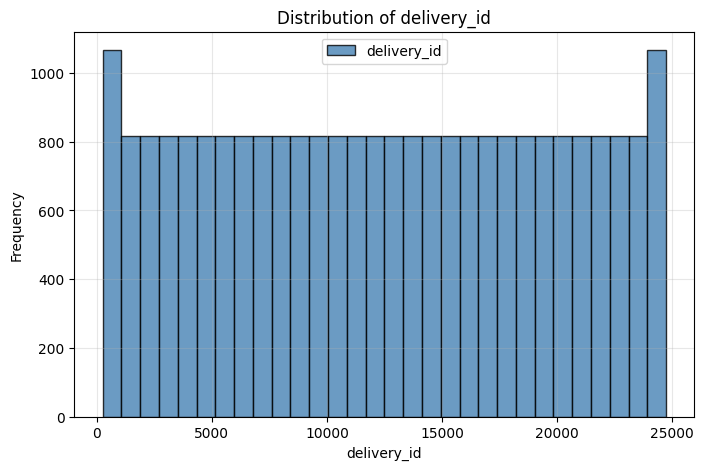

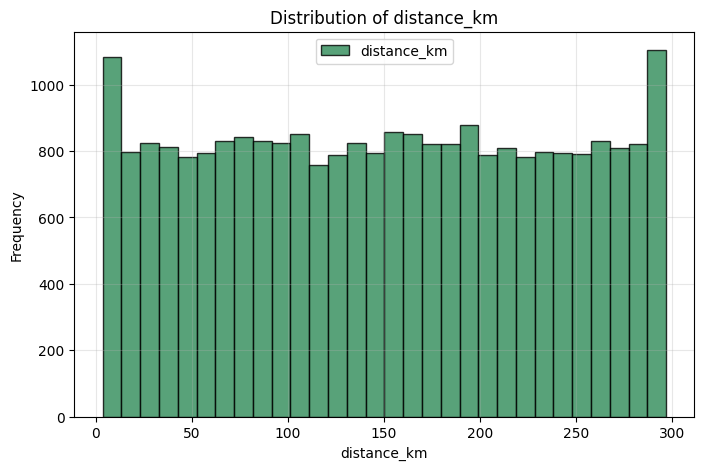

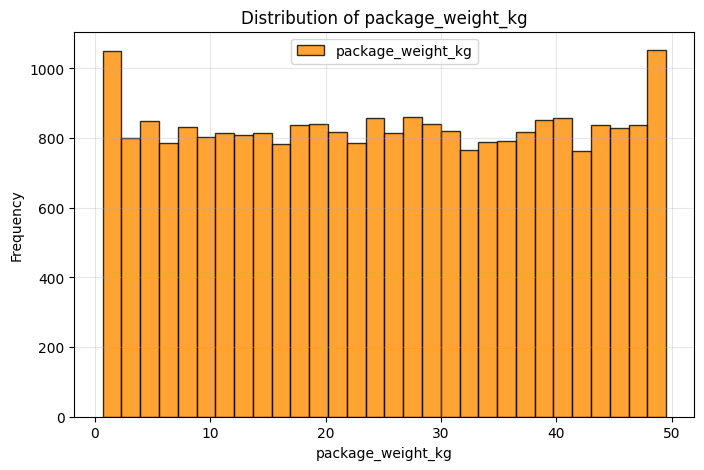

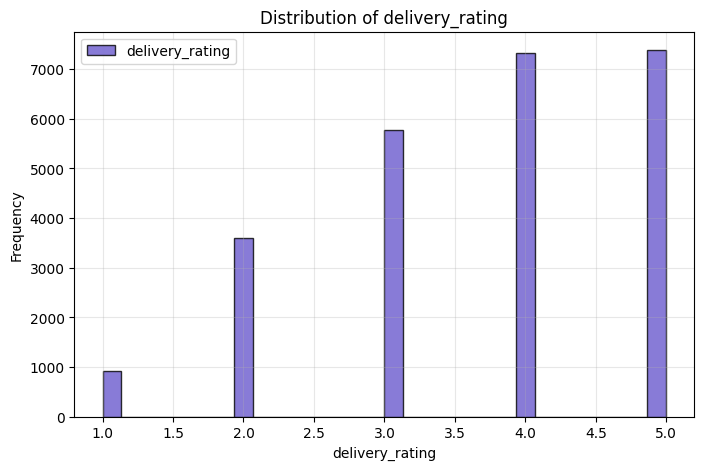

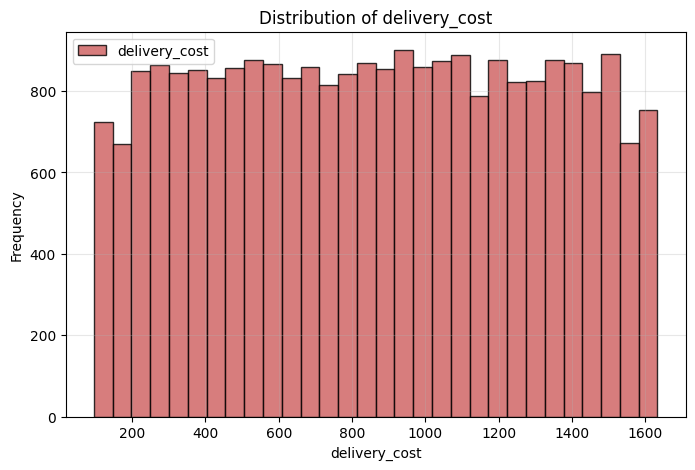

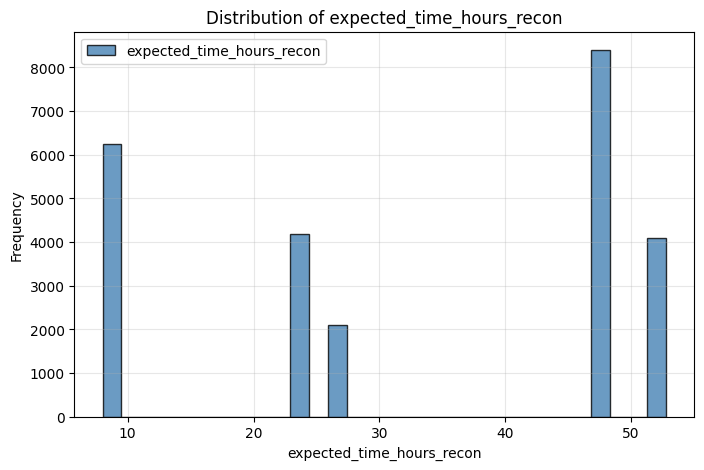

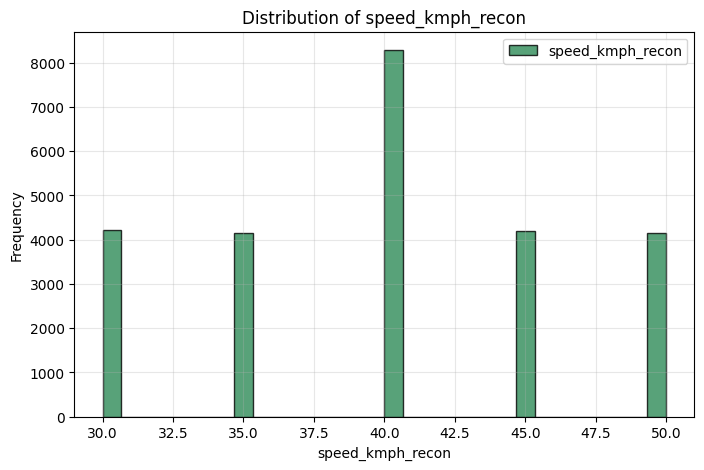

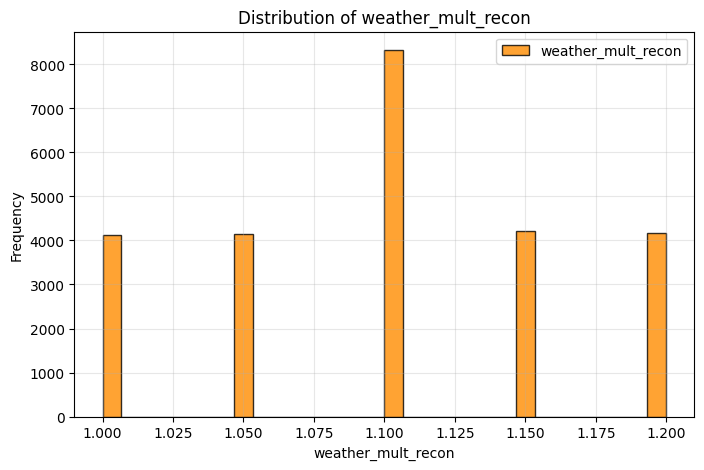

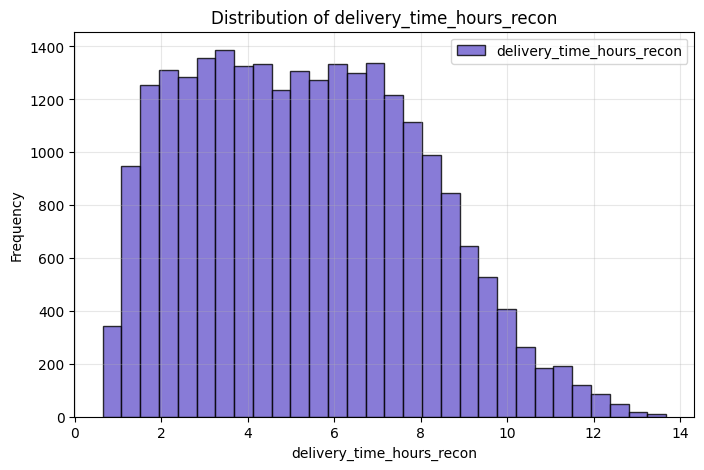

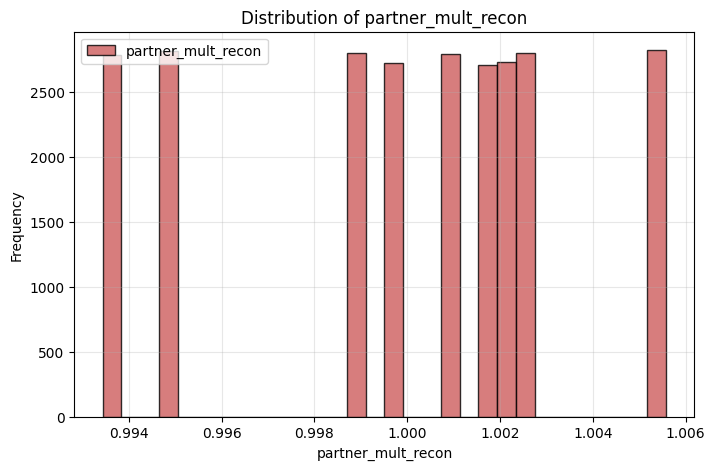

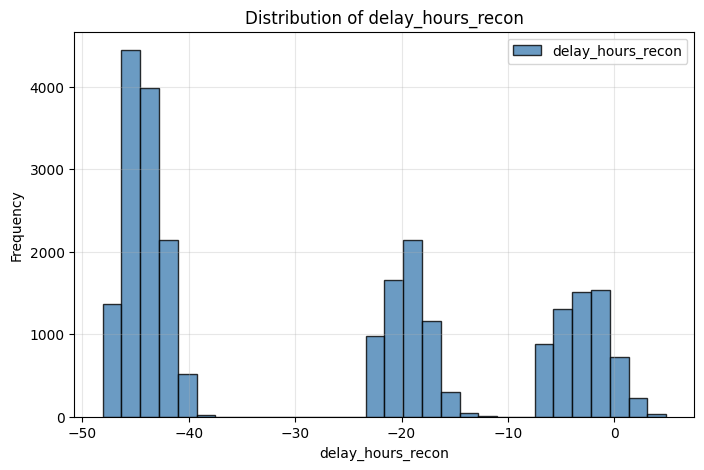

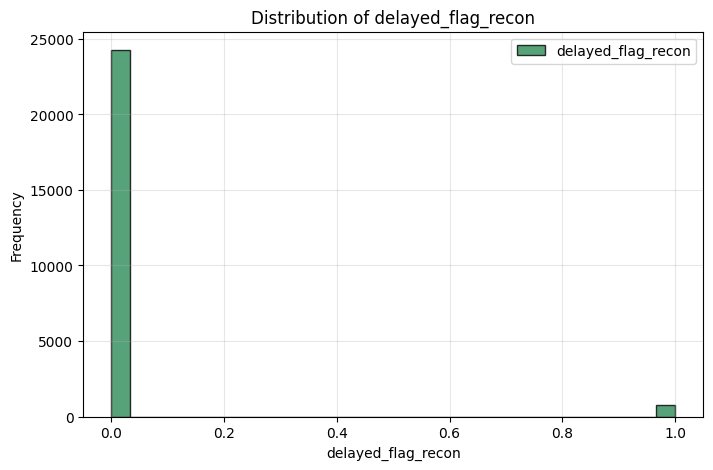

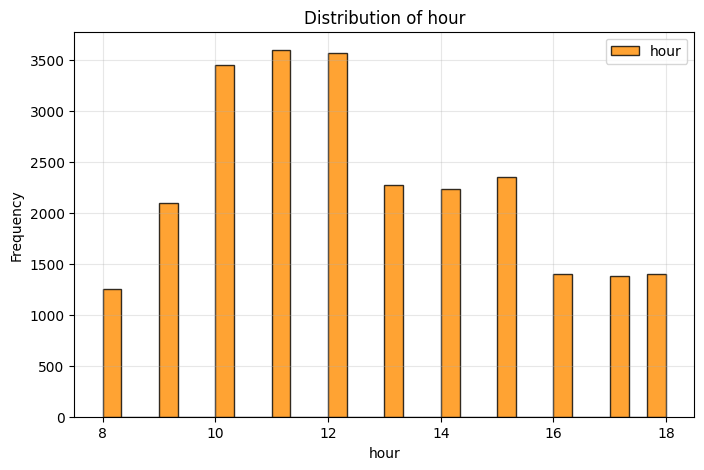

In [20]:
colors = ['steelblue', 'seagreen', 'darkorange', 'slateblue', 'indianred']

for i, col in enumerate(numeric_columns):
    plt.figure(figsize=(8, 5))
    plt.hist(
        df[col],
        bins=30,
        color=colors[i % len(colors)],
        edgecolor='black',
        alpha=0.8,
        label=col
    )
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


# **CATEGORICAL SUMMARY**

In [21]:
#Percentage of total records belonging to each category.
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    print(f"\nColumn: {col}")
    print("Unique values:", df[col].nunique())
    print(df[col].value_counts(normalize=True).head(10) * 100)


Column: delivery_partner
Unique values: 9
delivery_partner
xpressbees          11.304
fedex               11.272
dhl                 11.208
ekart               11.204
blue dart           11.192
delhivery           11.144
shadowfax           10.944
ecom express        10.888
amazon logistics    10.844
Name: proportion, dtype: float64

Column: package_type
Unique values: 9
package_type
fragile items       11.392
pharmacy            11.240
documents           11.220
automobile parts    11.180
electronics         11.168
clothing            11.068
furniture           10.984
cosmetics           10.976
groceries           10.772
Name: proportion, dtype: float64

Column: vehicle_type
Unique values: 6
vehicle_type
ev bike    16.872
van        16.748
scooter    16.696
bike       16.640
truck      16.580
ev van     16.464
Name: proportion, dtype: float64

Column: delivery_mode
Unique values: 4
delivery_mode
two day     25.208
same day    25.116
express     24.932
standard    24.744
Name: proport

# **CATEGORICAL DISTRIBUTIONS**

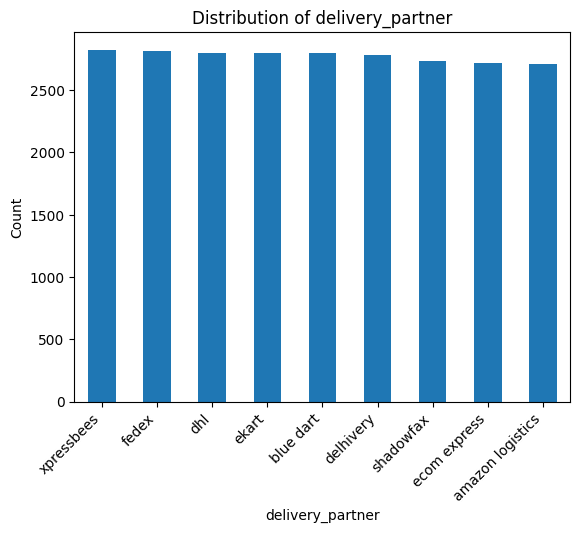

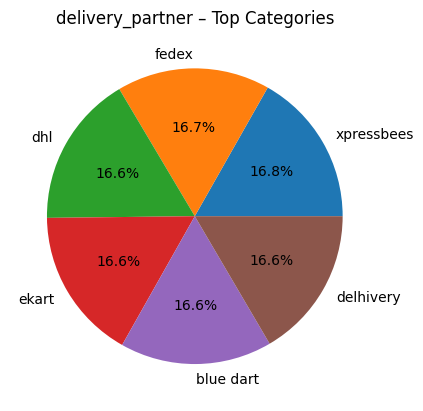

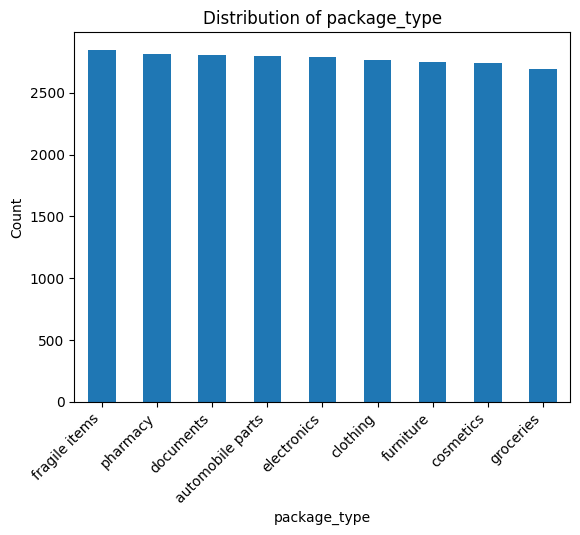

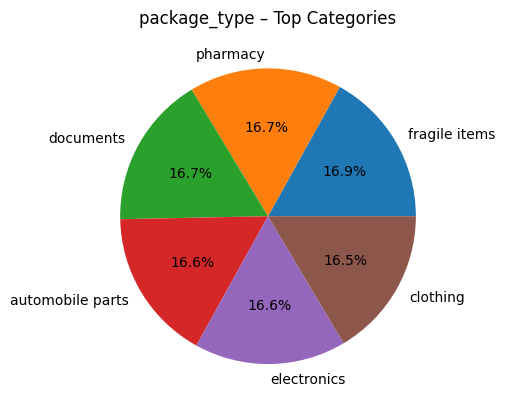

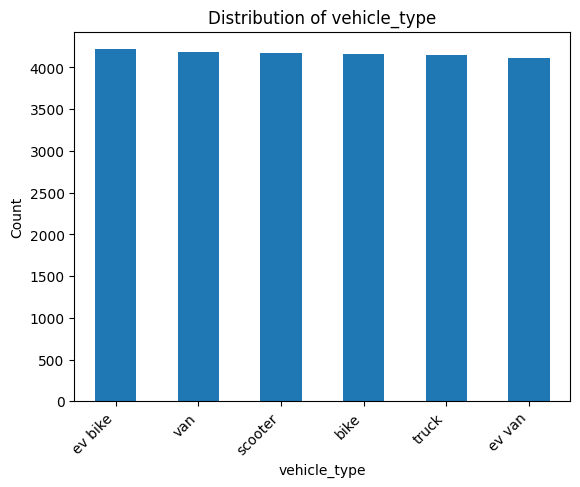

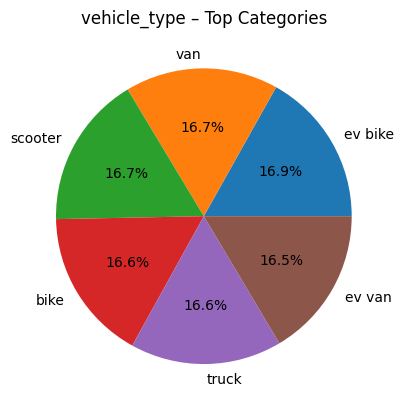

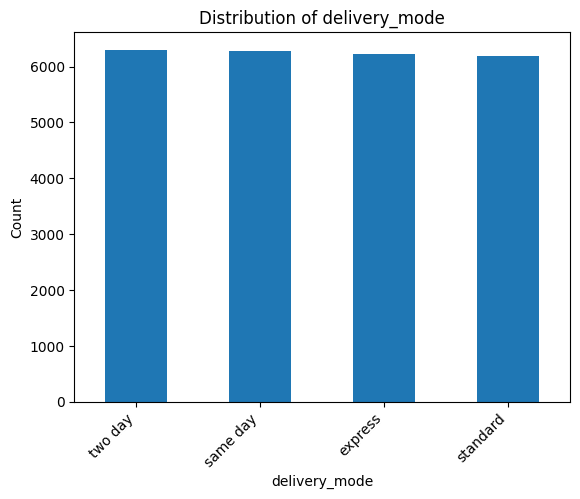

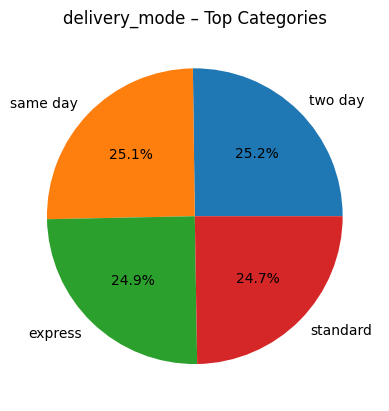

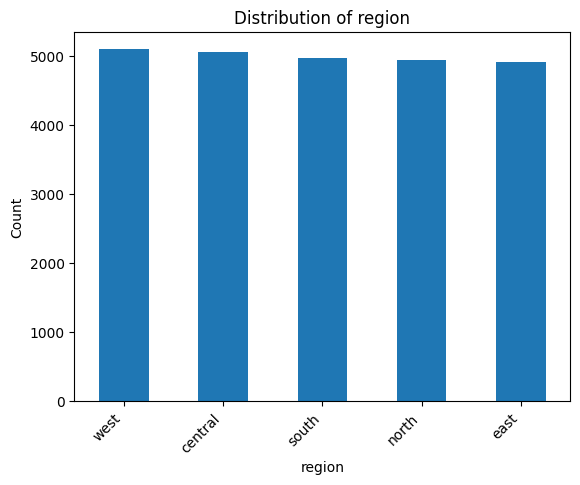

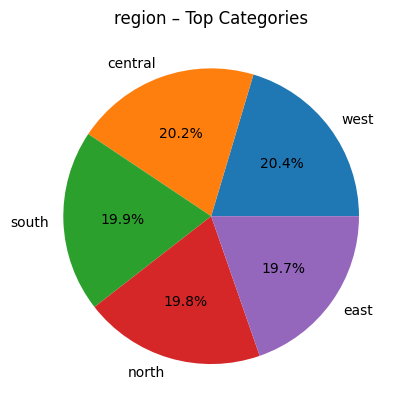

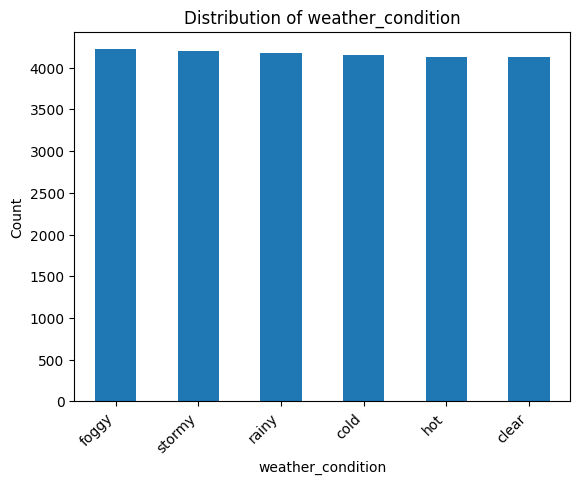

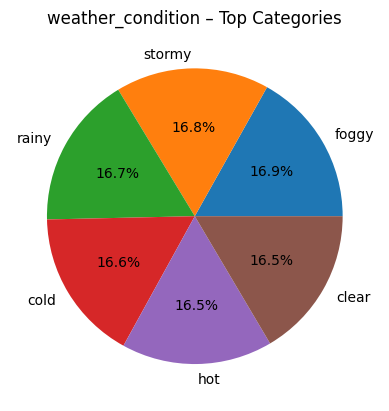

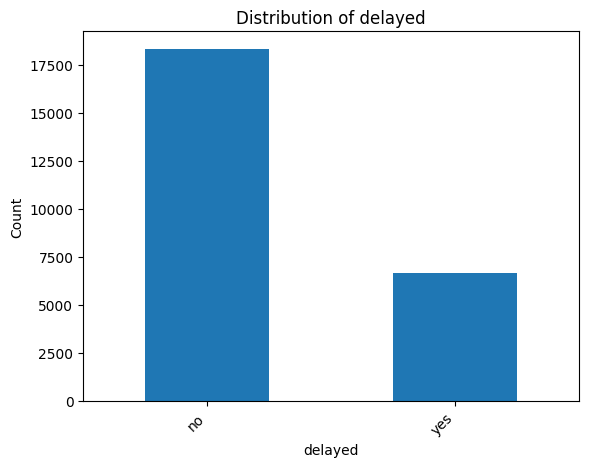

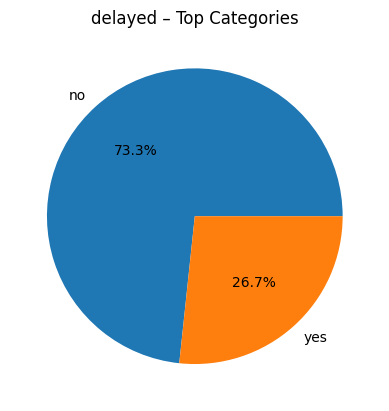

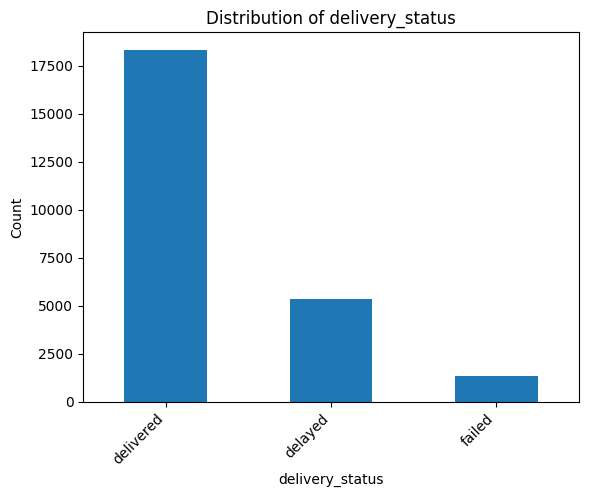

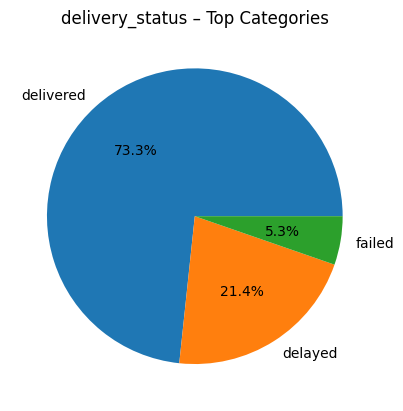

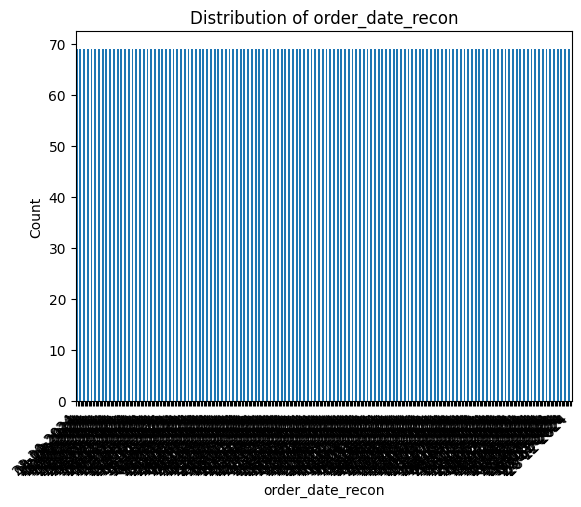

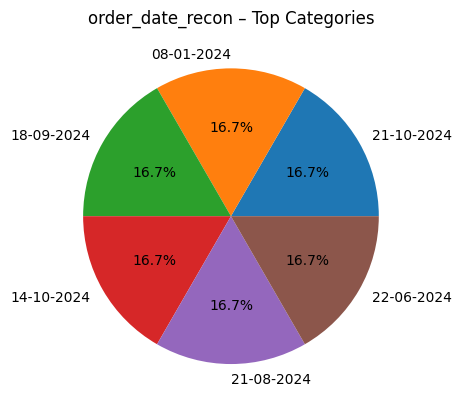

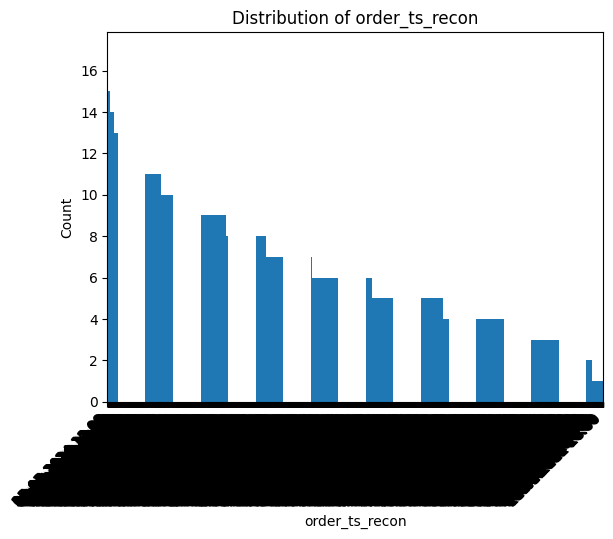

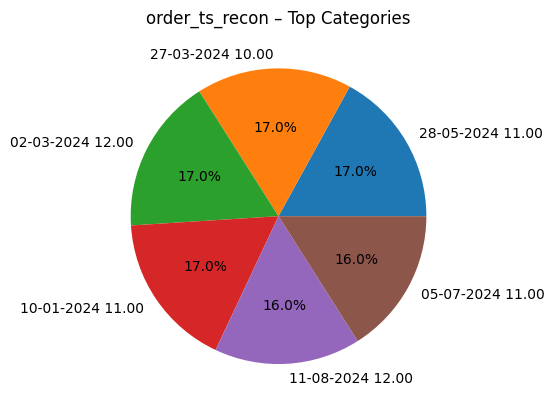

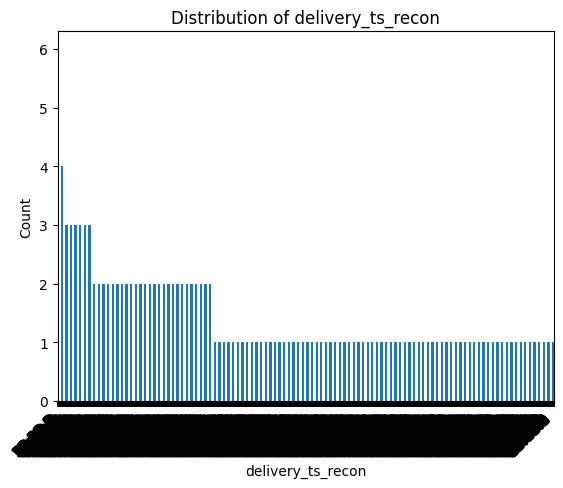

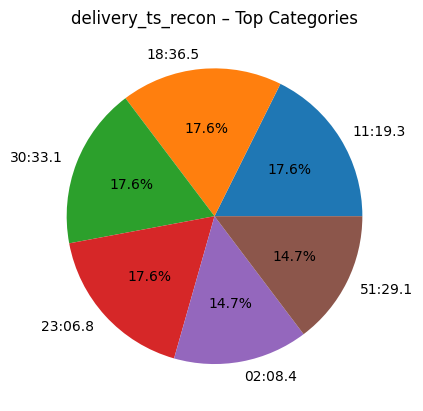

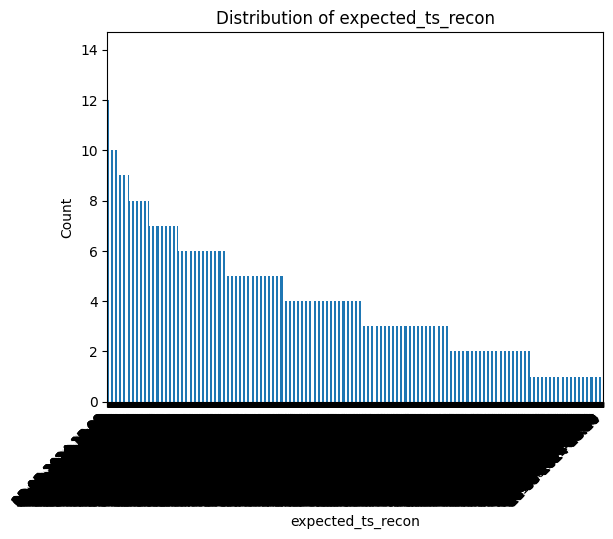

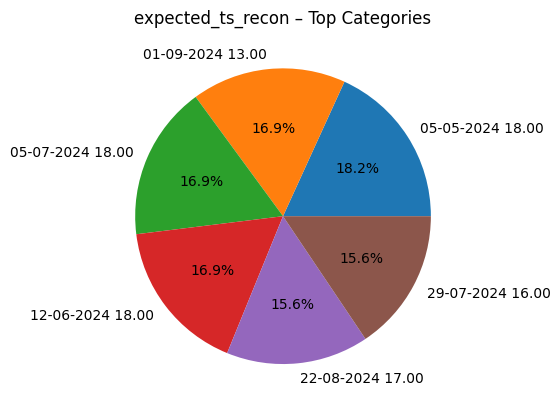

In [22]:
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    value_counts = df[col].value_counts()

    # BAR CHART

    plt.figure()
    value_counts.plot(kind='bar')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.show()


    # PIE CHART
    plt.figure()
    value_counts.head(6).plot(kind='pie', autopct='%1.1f%%')
    plt.title(f'{col} – Top Categories')
    plt.ylabel('')
    plt.show()


# **WEATHER vs DELIVERY STATUS**

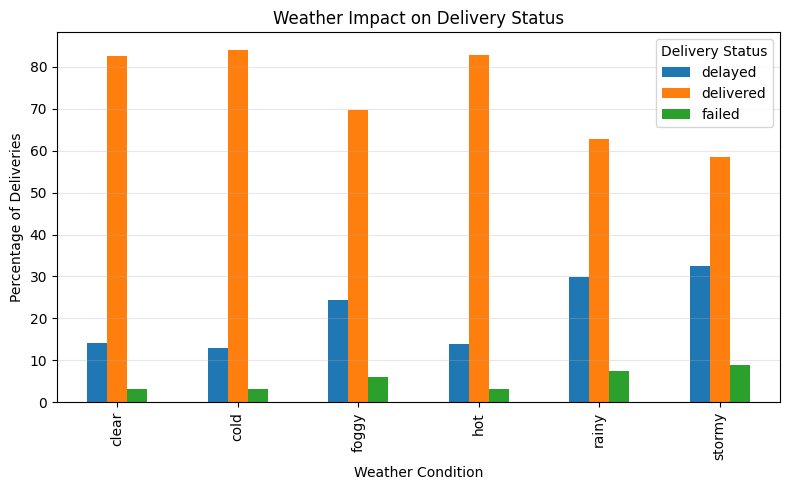

In [23]:
weather_delay = pd.crosstab(
    df['weather_condition'],
    df['delivery_status'],
    normalize='index'
) * 100

weather_delay.plot(kind='bar', figsize=(8, 5))
plt.title('Weather Impact on Delivery Status')
plt.xlabel('Weather Condition')
plt.ylabel('Percentage of Deliveries')
plt.legend(title='Delivery Status')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# **REGION-WISE DELAY ANALYSIS**

region
central    27.252964
west       26.947988
south      26.783203
north      26.571024
east       25.797926
Name: delayed, dtype: float64


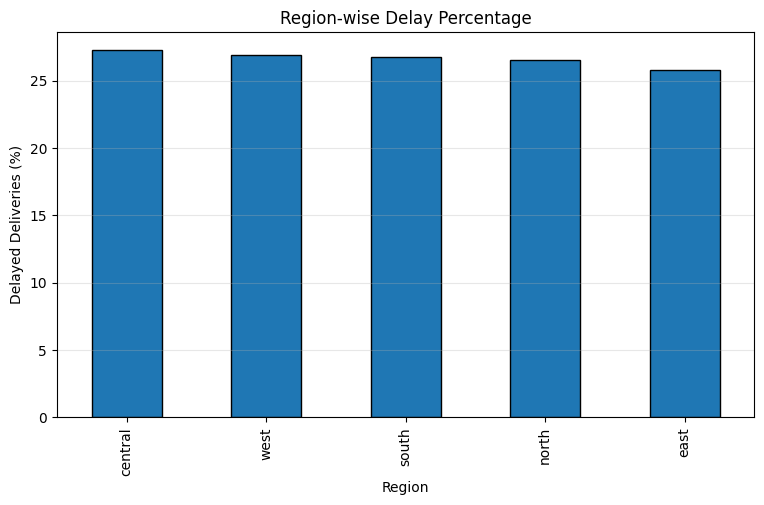

In [24]:
region_delay_pct = (
    df.groupby("region")["delayed"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .sort_values(ascending=False)
)

print(region_delay_pct)


region_delay_pct.plot(kind="bar", figsize=(9,5), edgecolor="black")

plt.title("Region-wise Delay Percentage")
plt.xlabel("Region")
plt.ylabel("Delayed Deliveries (%)")
plt.grid(axis="y", alpha=0.3)
plt.show()


# **VEHICLE TYPE vs DELAY**

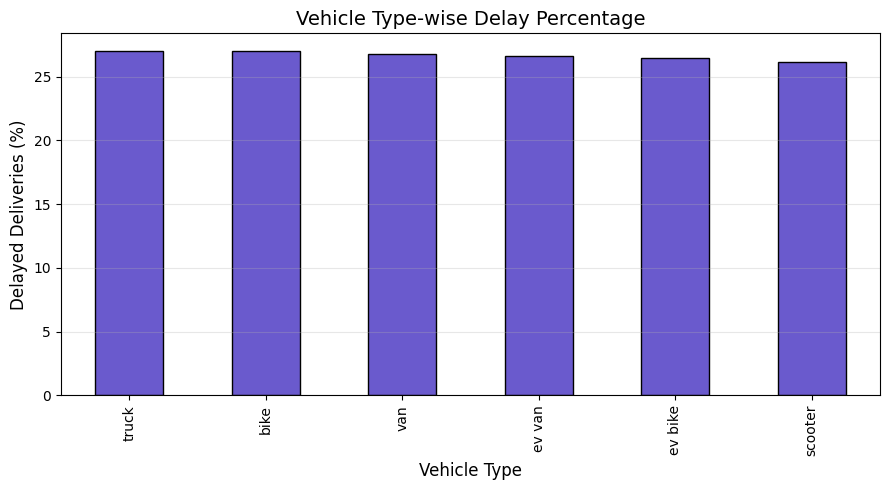

In [25]:
vehicle_delay = (
    df.groupby("vehicle_type")["delayed"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))
vehicle_delay.plot(kind="bar", color="slateblue", edgecolor="black")
plt.title("Vehicle Type-wise Delay Percentage", fontsize=14)
plt.xlabel("Vehicle Type", fontsize=12)
plt.ylabel("Delayed Deliveries (%)", fontsize=12)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# **DISTANCE vs DELAY**

<Figure size 700x500 with 0 Axes>

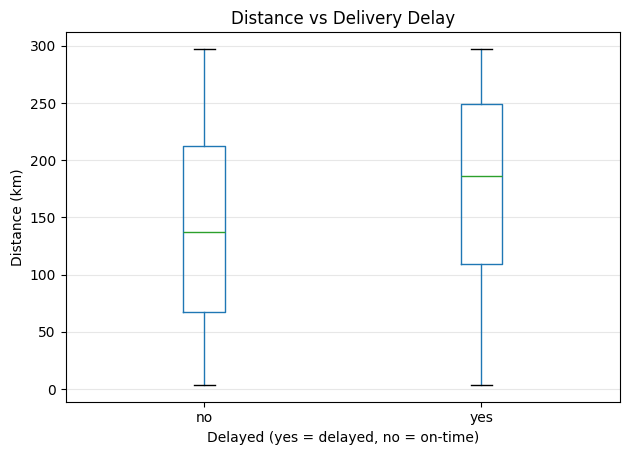

In [26]:
plt.figure(figsize=(7, 5))

df.boxplot(
    column='distance_km',
    by='delayed',
    grid=False
)

plt.title('Distance vs Delivery Delay')
plt.suptitle('')
plt.xlabel('Delayed (yes = delayed, no = on-time)')
plt.ylabel('Distance (km)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# **COLUMN-WISE OUTLIER DETECTION**

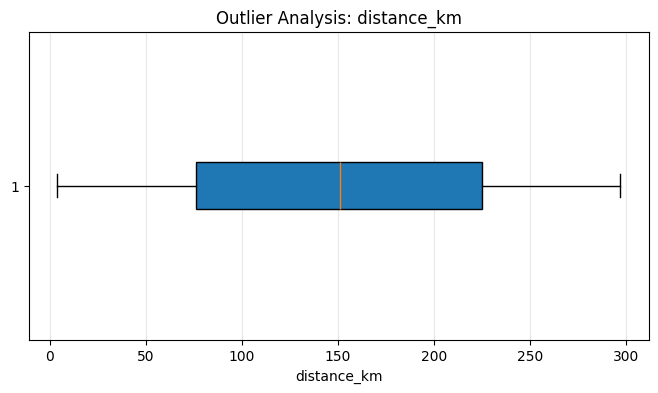

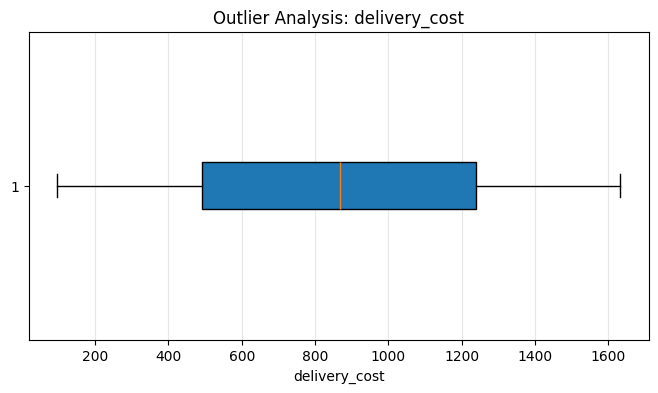

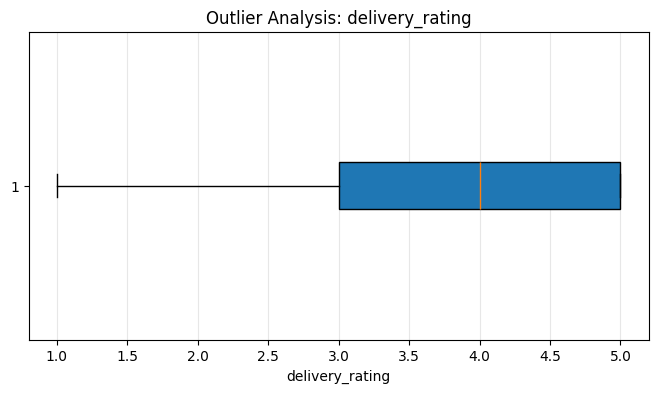

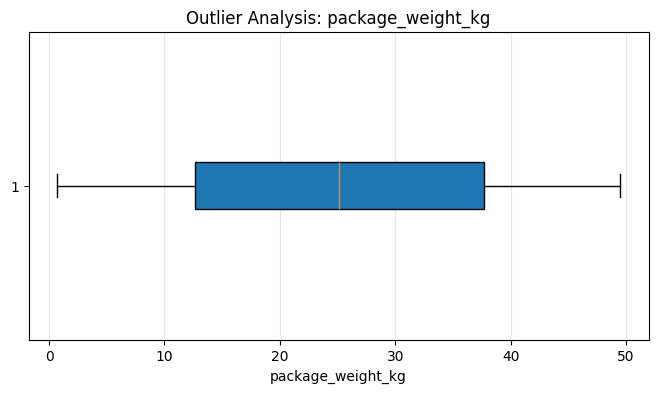

In [27]:
outlier_columns = [
    "distance_km",
    "delivery_cost",
    "delivery_rating",
    "package_weight_kg"
]

for col in outlier_columns:
    plt.figure(figsize=(8, 4))

    plt.boxplot(
        df[col],
        vert=False,
        patch_artist=True
    )

    plt.title(f"Outlier Analysis: {col}")
    plt.xlabel(col)
    plt.grid(axis="x", alpha=0.3)
    plt.show()


# **CORRELATION HEATMAP**

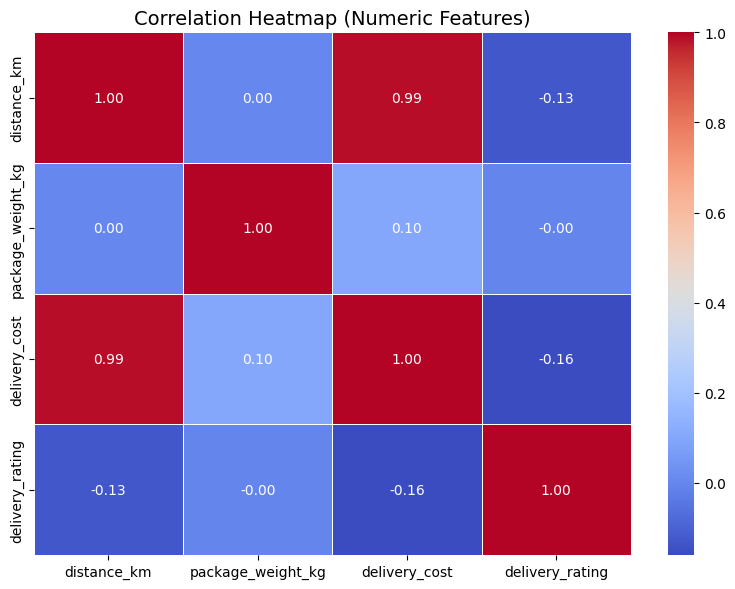

In [28]:
heatmap_columns = [
    'distance_km',
    'package_weight_kg',
    'delivery_cost',
    'delivery_rating'
]

corr_matrix = df[heatmap_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap (Numeric Features)", fontsize=14)
plt.tight_layout()
plt.show()


# **NUMERIC vs TARGET**

<Figure size 700x500 with 0 Axes>

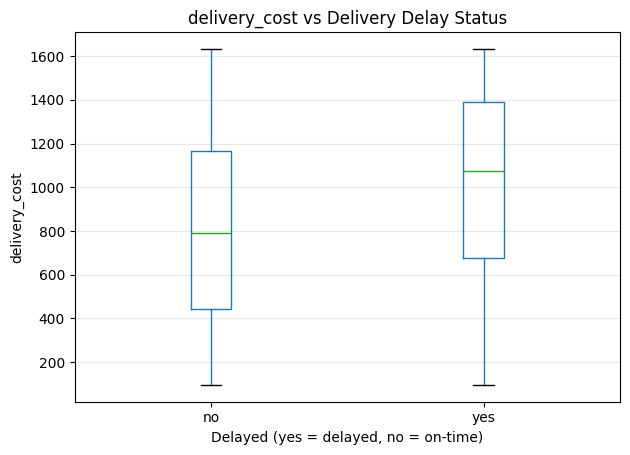

<Figure size 700x500 with 0 Axes>

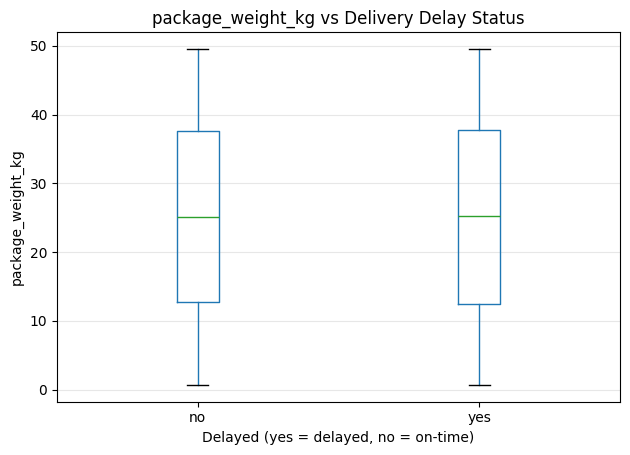

<Figure size 700x500 with 0 Axes>

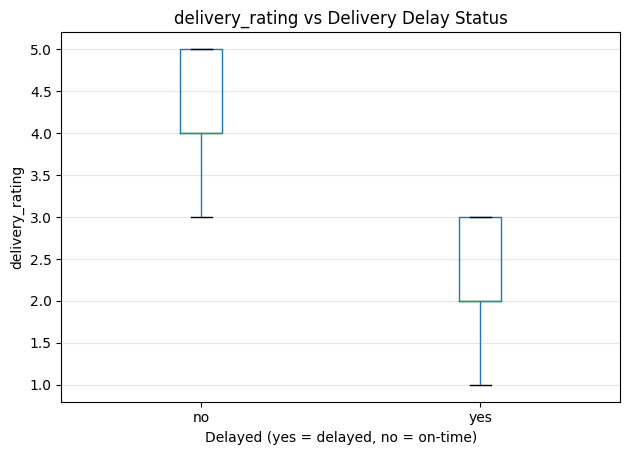

In [29]:
numeric_vs_target = [
    'delivery_cost',
    'package_weight_kg',
    'delivery_rating'
]

for col in numeric_vs_target:
    plt.figure(figsize=(7, 5))

    df.boxplot(
        column=col,
        by='delayed',   # existing column
        grid=False
    )

    plt.title(f'{col} vs Delivery Delay Status')
    plt.suptitle('')
    plt.xlabel('Delayed (yes = delayed, no = on-time)')
    plt.ylabel(col)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


# **Feature engineering**

In [ ]:
df = pd.read_csv("../Data/Delivery_Logistics_reconstructed.csv")

In [31]:
df["order_ts_recon"] = pd.to_datetime(
    df["order_ts_recon"],
    format="%d-%m-%Y %H.%M"
)

df["expected_ts_recon"] = pd.to_datetime(
    df["expected_ts_recon"],
    format="%d-%m-%Y %H.%M"
)

df["delivery_ts_recon"] = pd.to_datetime(
    df["delivery_ts_recon"],
    errors="coerce"
)

C:\Users\Admin\AppData\Local\Temp\ipykernel_10192\2373193325.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["delivery_ts_recon"] = pd.to_datetime(


In [32]:
print(df["order_ts_recon"].head())
print(df["order_ts_recon"].dtype)

0   2024-10-21 13:00:00
1   2024-01-02 12:00:00
2   2024-05-31 11:00:00
3   2024-01-03 17:00:00
4   2024-03-19 13:00:00
Name: order_ts_recon, dtype: datetime64[ns]
datetime64[ns]


**Time-Based Features**

In [33]:
# Extract day of week (0 = Monday, 6 = Sunday)
df["order_dayofweek"] = df["order_ts_recon"].dt.dayofweek

# Extract day name (Monday, Tuesday, etc.)
df["order_day_name"] = df["order_ts_recon"].dt.day_name()

# Extract month number (1 = January, 12 = December)
# Useful for seasonal analysis (festive rush, monsoon, etc.)
df["order_month"] = df["order_ts_recon"].dt.month

# Extract year (in case dataset spans multiple years)
df["order_year"] = df["order_ts_recon"].dt.year

# Extract hour of the day (0–23)
# Important for traffic and delivery timing patterns
df["order_hour"] = df["order_ts_recon"].dt.hour

**TRAFFIC / BEHAVIORAL FLAGS**

In [34]:
# Weekend flag
# 1 = Saturday or Sunday
# 0 = Weekday
df["is_weekend"] = (df["order_dayofweek"] >= 5).astype(int)


# Rush hour flag
# Morning rush: 8–10 AM
# Evening rush: 5–7 PM
# 1 = Rush hour, 0 = Normal hour
df["rush_hour_flag"] = df["order_hour"].isin(
    [8, 9, 10, 17, 18, 19]
).astype(int)


# Night delivery flag
# 1 = Between 10 PM–5 AM
# Night deliveries may be faster (less traffic) or riskier
df["night_delivery_flag"] = df["order_hour"].isin(
    list(range(0, 6)) + list(range(22, 24))
).astype(int)

In [35]:
df[[
    "order_ts_recon",
    "order_dayofweek",
    "order_day_name",
    "order_month",
    "order_year",
    "order_hour",
    "is_weekend",
    "rush_hour_flag",
    "night_delivery_flag"
]].head()

,order_ts_recon,order_dayofweek,order_day_name,order_month,order_year,order_hour,is_weekend,rush_hour_flag,night_delivery_flag
0,2024-10-21 13:00:00,0,Monday,10,2024,13,0,0,0
1,2024-01-02 12:00:00,1,Tuesday,1,2024,12,0,0,0
2,2024-05-31 11:00:00,4,Friday,5,2024,11,0,0,0
3,2024-01-03 17:00:00,2,Wednesday,1,2024,17,0,1,0
4,2024-03-19 13:00:00,1,Tuesday,3,2024,13,0,0,0


In [36]:
df["order_day_name"].value_counts()

order_day_name
Monday       3588
Tuesday      3588
Friday       3588
Wednesday    3588
Thursday     3588
Saturday     3541
Sunday       3519
Name: count, dtype: int64

In [37]:
df["is_weekend"].value_counts()

is_weekend
0    17940
1     7060
Name: count, dtype: int64

In [38]:
df["rush_hour_flag"].value_counts()

rush_hour_flag
0    15418
1     9582
Name: count, dtype: int64

In [39]:
df["night_delivery_flag"].value_counts()

night_delivery_flag
0    25000
Name: count, dtype: int64

In [40]:
df[[
    "order_dayofweek",
    "order_month",
    "order_hour"
]].describe()

,order_dayofweek,order_month,order_hour
count,25000.000000,25000.000000,25000.000000
mean,2.987960,6.457920,12.515400
std,1.996551,3.423971,2.751564
min,0.000000,1.000000,8.000000
25%,1.000000,3.000000,10.000000
50%,3.000000,6.000000,12.000000
75%,5.000000,9.000000,15.000000
max,6.000000,12.000000,18.000000


In [41]:
df.groupby("order_day_name")[(df["delayed"]=="yes").astype(int)].mean()

KeyError: 'Columns not found: 0, 1'

In [42]:
df.groupby("is_weekend")[(df["delayed"]=="yes").astype(int)].mean()

KeyError: 'Columns not found: 0, 1'

In [42]:
df.groupby("rush_hour_flag")[(df["delayed"]=="yes").astype(int)].mean()

KeyError: 'Columns not found: 0, 1'

In [43]:
df.groupby("night_delivery_flag")[(df["delayed"]=="yes").astype(int)].mean()

KeyError: 'Columns not found: 0, 1'

In [43]:
import matplotlib.pyplot as plt

df.groupby("order_day_name")[(df["delayed"]=="yes").astype(int)].mean().plot(kind="bar")
plt.title("Delay Rate by Day of Week")
plt.ylabel("Delay Probability")
plt.xticks(rotation=45)
plt.show()

KeyError: 'Columns not found: 0, 1'

**Delay Severity Features**

In [45]:
# -------------------------------
# DELAY SEVERITY CATEGORIZATION
# -------------------------------

def delay_bucket(x):
    if x <= 0:
        return "OnTime/Early"
    elif x <= 2:
        return "Slight Delay"
    elif x <= 6:
        return "Moderate Delay"
    else:
        return "Severe Delay"

# Create multi-class delay severity feature
df["delay_severity"] = df["delay_hours_recon"].apply(delay_bucket)

# Preview output
df[["delay_hours_recon", "delay_severity"]].head()

,delay_hours_recon,delay_severity
0,-43.467511,OnTime/Early
1,-3.870065,OnTime/Early
2,-18.972602,OnTime/Early
3,-44.002989,OnTime/Early
4,-45.866649,OnTime/Early


In [46]:
# -------------------------------
# SEVERE DELAY BINARY FLAG
# -------------------------------

# 1 = Delay more than 6 hours
# 0 = Otherwise
df["severe_delay_flag"] = (df["delay_hours_recon"] > 6).astype(int)

# Check distribution
df["severe_delay_flag"].value_counts()

severe_delay_flag
0    25000
Name: count, dtype: int64

**Distance + Time Efficiency Features**

In [47]:
# -------------------------------
# SPEED CATEGORY BINNING
# -------------------------------

df["speed_category"] = pd.cut(
    df["speed_kmph_recon"],
    bins=[0, 20, 40, 60, 100],
    labels=["Slow", "Medium", "Fast", "Very Fast"]
)

# Preview
df[["speed_kmph_recon", "speed_category"]].head()

,speed_kmph_recon,speed_category
0,30,Medium
1,35,Medium
2,45,Fast
3,30,Medium
4,40,Medium


In [48]:
# -------------------------------
# DELIVERY EFFICIENCY SCORE
# -------------------------------

# Higher speed and lower weather multiplier = better efficiency
df["efficiency_score"] = (
    df["speed_kmph_recon"] / df["weather_mult_recon"]
)

# Summary
df["efficiency_score"].describe()

count    25000.000000
mean        36.459488
std          6.296361
min         25.000000
25%         31.818182
50%         36.363636
75%         40.909091
max         50.000000
Name: efficiency_score, dtype: float64

**Cost & Profitability Features**

In [49]:
# -------------------------------
# COST PER KM
# -------------------------------

df["cost_per_km"] = df["delivery_cost"] / df["distance_km"]

df[["delivery_cost", "distance_km", "cost_per_km"]].head()

,delivery_cost,distance_km,cost_per_km
0,1322.21,235.6,5.612097
1,595.53,81.8,7.280318
2,1608.49,282.9,5.685719
3,469.01,88.6,5.293567
4,1045.27,204.2,5.118854


In [50]:
# -------------------------------
# COST PER KG
# -------------------------------

df["cost_per_kg"] = df["delivery_cost"] / df["package_weight_kg"]

df[["delivery_cost", "package_weight_kg", "cost_per_kg"]].head()

,delivery_cost,package_weight_kg,cost_per_kg
0,1322.21,48.07,27.505929
1,595.53,45.51,13.085695
2,1608.49,31.33,51.340249
3,469.01,8.67,54.095732
4,1045.27,8.09,129.205192


In [51]:
# -------------------------------
# HEAVY PACKAGE FLAG
# -------------------------------

# 1 = weight > 30kg
df["heavy_flag"] = (df["package_weight_kg"] > 30).astype(int)

df["heavy_flag"].value_counts()

heavy_flag
0    14997
1    10003
Name: count, dtype: int64

**Partner & Region Reliability Features**

In [52]:
# -------------------------------
# PARTNER HISTORICAL DELAY RATE
# -------------------------------
# NOTE: Used for EDA/exploration here.
# In model building, delay rates are recomputed on TRAIN only to prevent leakage.

df["partner_delay_rate"] = df.groupby("delivery_partner")[
    "delayed"
].transform(lambda x: (x == "yes").mean())

# Preview
df[["delivery_partner", "partner_delay_rate"]].head()


,delivery_partner,partner_delay_rate
0,amazon logistics,0.272224
1,amazon logistics,0.272224
2,amazon logistics,0.272224
3,amazon logistics,0.272224
4,amazon logistics,0.272224


In [53]:
# -------------------------------
# REGION HISTORICAL DELAY RATE
# -------------------------------

df["region_delay_rate"] = df.groupby("region")[
    "delayed"
].transform(lambda x: (x == "yes").mean())

df[["region", "region_delay_rate"]].head()


,region,region_delay_rate
0,west,0.269480
1,central,0.272530
2,north,0.265710
3,central,0.272530
4,east,0.257979


In [54]:
# -------------------------------
# VEHICLE TYPE DELAY RATE
# -------------------------------

df["vehicle_delay_rate"] = df.groupby("vehicle_type")[
    "delayed"
].transform(lambda x: (x == "yes").mean())

df[["vehicle_type", "vehicle_delay_rate"]].head()


,vehicle_type,vehicle_delay_rate
0,ev bike,0.264343
1,bike,0.270433
2,van,0.267733
3,ev bike,0.264343
4,ev van,0.266278


In [55]:
# -------------------------------
# DELIVERY MODE DELAY RATE
# -------------------------------

df["mode_delay_rate"] = df.groupby("delivery_mode")[
    "delayed"
].transform(lambda x: (x == "yes").mean())

df[["delivery_mode", "mode_delay_rate"]].head()


,delivery_mode,mode_delay_rate
0,standard,0.000000
1,express,0.737847
2,same day,0.325370
3,two day,0.004284
4,two day,0.004284


**Weather-Based Risk Features**

In [56]:
# -------------------------------
# BAD WEATHER FLAG
# -------------------------------

# 1 = Risky weather conditions
# 0 = Normal weather
df["bad_weather_flag"] = df["weather_condition"].isin(
    ["rainy", "stormy", "foggy"]
).astype(int)

# Check distribution
df["bad_weather_flag"].value_counts()

bad_weather_flag
1    12588
0    12412
Name: count, dtype: int64

In [57]:
# -------------------------------
# WEATHER SEVERITY SCORE
# -------------------------------

# Assign severity scores manually
weather_map = {
    "clear": 0,
    "cloudy": 1,
    "hot": 1,
    "cold": 1,
    "rainy": 2,
    "foggy": 3,
    "stormy": 4
}

df["weather_severity"] = df["weather_condition"].map(weather_map)

# Preview
df[["weather_condition", "weather_severity"]].head()

,weather_condition,weather_severity
0,clear,0
1,stormy,4
2,clear,0
3,hot,1
4,rainy,2


In [58]:
# -------------------------------
# WEATHER DISTANCE RISK
# -------------------------------

# Long distance + bad weather = higher delay probability
df["weather_distance_risk"] = (
    df["weather_severity"] * df["distance_km"]
)

df[["weather_severity", "distance_km", "weather_distance_risk"]].head()

,weather_severity,distance_km,weather_distance_risk
0,0,235.6,0.0
1,4,81.8,327.2
2,0,282.9,0.0
3,1,88.6,88.6
4,2,204.2,408.4


**Delivery Status Feature**

In [59]:
# -------------------------------
# DELIVERY STATUS FLAG
# -------------------------------

# 1 = Delivered
# 0 = Otherwise
df["status_delivered_flag"] = (
    df["delivery_status"] == "delivered"
).astype(int)

df["status_delivered_flag"].value_counts()

status_delivered_flag
1    18331
0     6669
Name: count, dtype: int64

**Smart Interaction Features**

In [60]:
# -------------------------------
# LOAD INDEX
# -------------------------------

# Heavy + long distance = operational difficulty
df["load_index"] = (
    df["package_weight_kg"] * df["distance_km"]
)

df[["package_weight_kg", "distance_km", "load_index"]].head()

,package_weight_kg,distance_km,load_index
0,48.07,235.6,11325.292
1,45.51,81.8,3722.718
2,31.33,282.9,8863.257
3,8.67,88.6,768.162
4,8.09,204.2,1651.978


In [61]:
# -------------------------------
# COST WEATHER RISK
# -------------------------------

df["cost_weather_risk"] = (
    df["delivery_cost"] * df["weather_mult_recon"]
)

df[["delivery_cost", "weather_mult_recon", "cost_weather_risk"]].head()

,delivery_cost,weather_mult_recon,cost_weather_risk
0,1322.21,1.0,1322.210
1,595.53,1.1,655.083
2,1608.49,1.0,1608.490
3,469.01,1.1,515.911
4,1045.27,1.2,1254.324


In [62]:
# -------------------------------
# PARTNER WEATHER RISK
# -------------------------------

df["partner_weather_risk"] = (
    df["partner_delay_rate"] * df["weather_severity"]
)

df[[
    "partner_delay_rate",
    "weather_severity",
    "partner_weather_risk"
]].head()

,partner_delay_rate,weather_severity,partner_weather_risk
0,0.272224,0,0.000000
1,0.272224,4,1.088897
2,0.272224,0,0.000000
3,0.272224,1,0.272224
4,0.272224,2,0.544449


**Expected vs Actual Time Features**

In [63]:
# -------------------------------
# TIME RATIO FEATURE
# -------------------------------

# >1 means delayed
# <1 means early
df["time_ratio"] = (
    df["delivery_time_hours_recon"] /
    df["expected_time_hours_recon"]
)

df[[
    "delivery_time_hours_recon",
    "expected_time_hours_recon",
    "time_ratio"
]].head()

,delivery_time_hours_recon,expected_time_hours_recon,time_ratio
0,9.332489,52.8,0.176752
1,4.129935,8.0,0.516242
2,7.427398,26.4,0.281341
3,3.997011,48.0,0.083271
4,6.933351,52.8,0.131313


In [64]:
# -------------------------------
# EARLY DELIVERY FLAG
# -------------------------------

# 1 = Delivered earlier than expected
df["early_flag"] = (
    df["delay_hours_recon"] < 0
).astype(int)

df["early_flag"].value_counts()

early_flag
1    24265
0      735
Name: count, dtype: int64

In [ ]:
# ----------------------------------------
# SAVE FULL FEATURE ENGINEERED DATASET
# ----------------------------------------

df.to_csv("../Data/eta_feature_engineered_dataset.csv", index=False)

print("Feature engineered dataset saved successfully!")
print("Total columns:", len(df.columns))

Feature engineered dataset saved successfully!
Total columns: 53


In [66]:
import os
print(os.getcwd())

c:\Users\Admin\Downloads


In [67]:
print(os.listdir())

['-82.xlsx', '.git', '.ipynb_checkpoints', '.Rhistory', '02 - Conversions - All Types - Advanced (1).pdf', '02 - Conversions - All Types - Advanced (2).pdf', '02 - Conversions - All Types - Advanced.pdf', '05 - Universal Gates.pdf', '1.1.pptx', '1.2.pptx', '1.3.pptx', '1.docx', '1000069777.jpg', '1000101608.jpg', '14580510.zip', '1730697573654Instructions to Candidates_Nov 2024.doc', '1candidates.xlsx', '2024-04-06 18-15-43 - Trim.mkv', '2024-04-06 18-57-43.mkv', '2341404 ds lab-4 Q3.py', '2341404_Brochure.docx', '2341404_DV_CIA_3.docx.pdf', '2341404_DV_Cia_3.twb', '2341404_EDA (1).twb', '2341404_EDA (3).twb', '2341404_EDA.twb', '2341404_lab7.docx (1).pdf', '2341404_lab7.docx.pdf', '2341404_LAB8.twb', '2341404_R_lab-6.docx', '2341404_R_lab-6.R', '2341404_R_lab-7 (1).docx', '2341404_R_lab-7.docx', '2341406_LAB#06 (1).twb', '2341406_LAB#06 (2).twb', '2341406_LAB#06.twb', '2341406_LAB-9.sql', '2341406_Lab1-1 (1).pdf', '2341406_Lab1-1.pdf', '2341415_Cia3_report1.docx.pdf', '2341420_CIA1.do

✅ Dataset loaded! Shape: (25000, 53)

✅ Features being used (25):
['delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode', 'region', 'weather_condition', 'distance_km', 'package_weight_kg', 'delivery_cost', 'expected_time_hours_recon', 'order_dayofweek', 'order_day_name', 'order_month', 'order_year', 'order_hour', 'is_weekend', 'rush_hour_flag', 'night_delivery_flag', 'cost_per_km', 'cost_per_kg', 'heavy_flag', 'bad_weather_flag', 'weather_severity', 'weather_distance_risk', 'load_index']

🎯 Target distribution:
target
0    18331
1     6669
Name: count, dtype: int64
Delay rate: 26.68% (using original delayed column)

📝 Encoding: ['delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode', 'region', 'weather_condition', 'order_day_name']
✅ Encoding done!

✅ Split done!
   Training: 20000 samples
   Testing:  5000 samples

✅ Delay rate features added (computed on train only — no leakage)

✅ Features scaled!

🌲 Training Random Forest...
✅ Random Forest done!

📈 Train

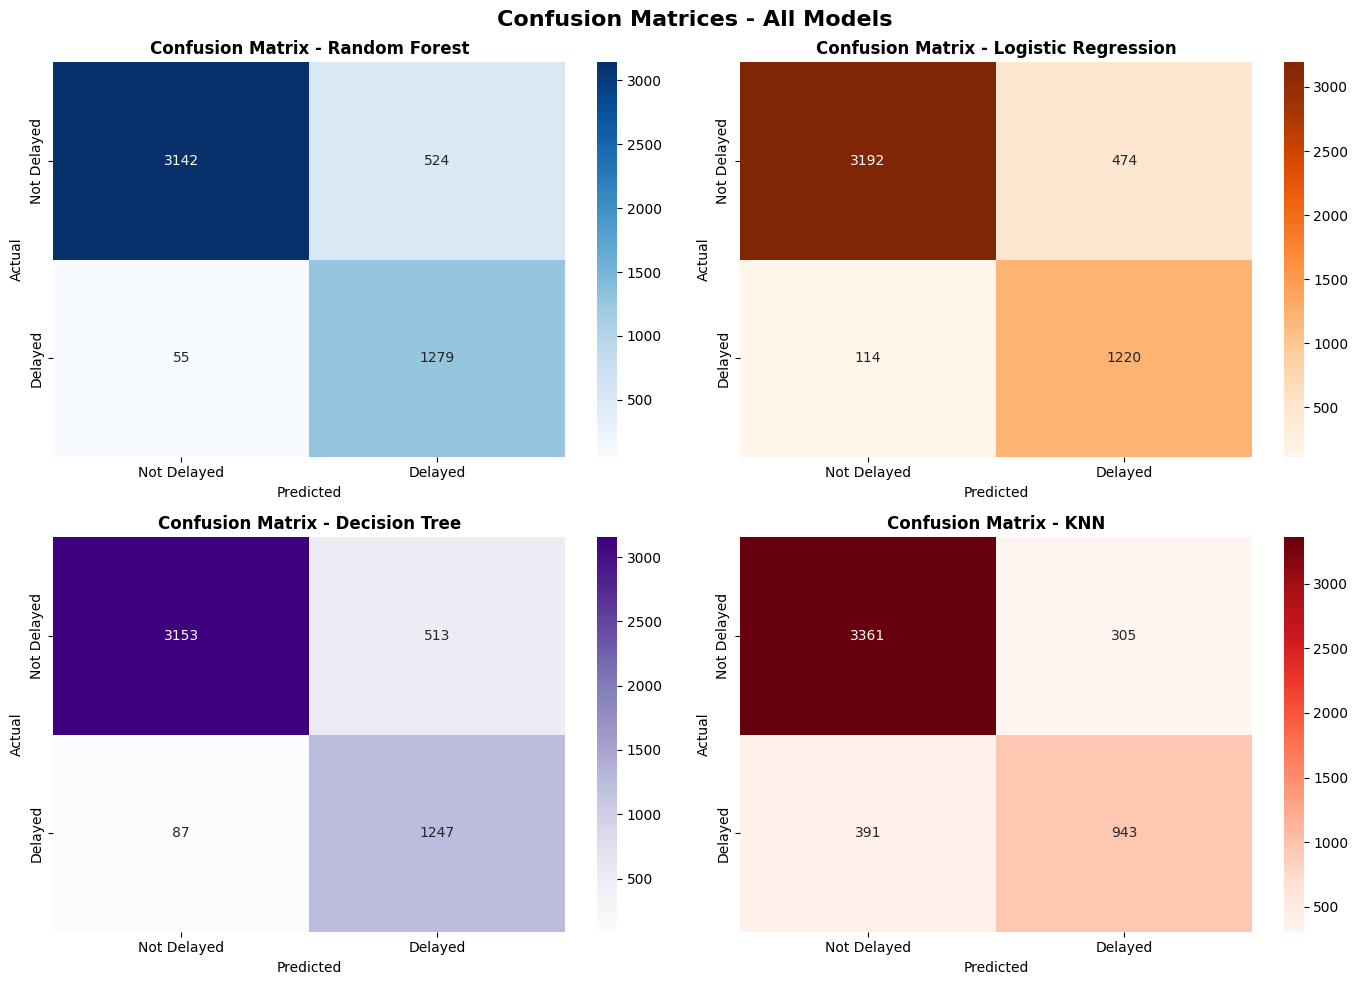

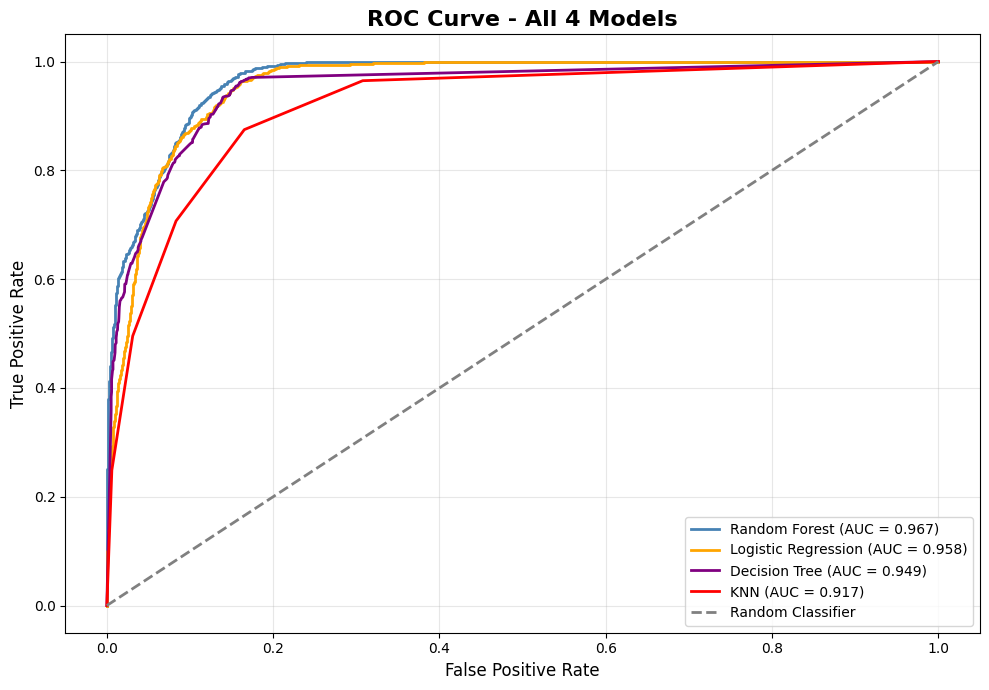

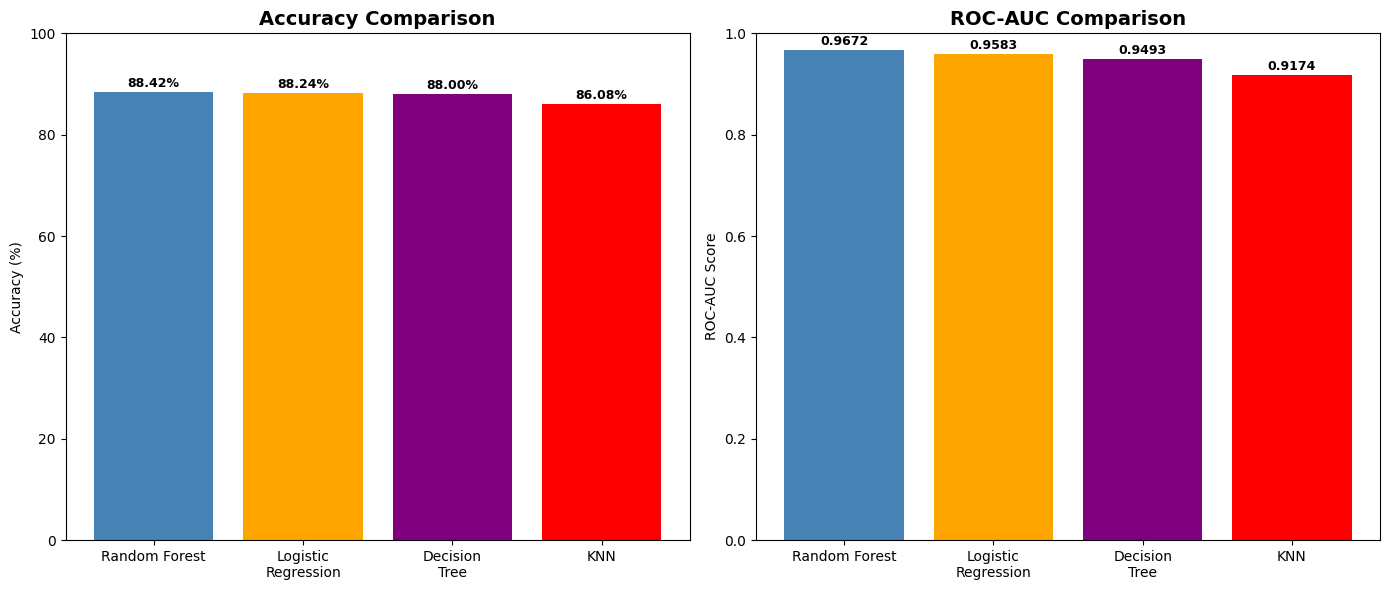

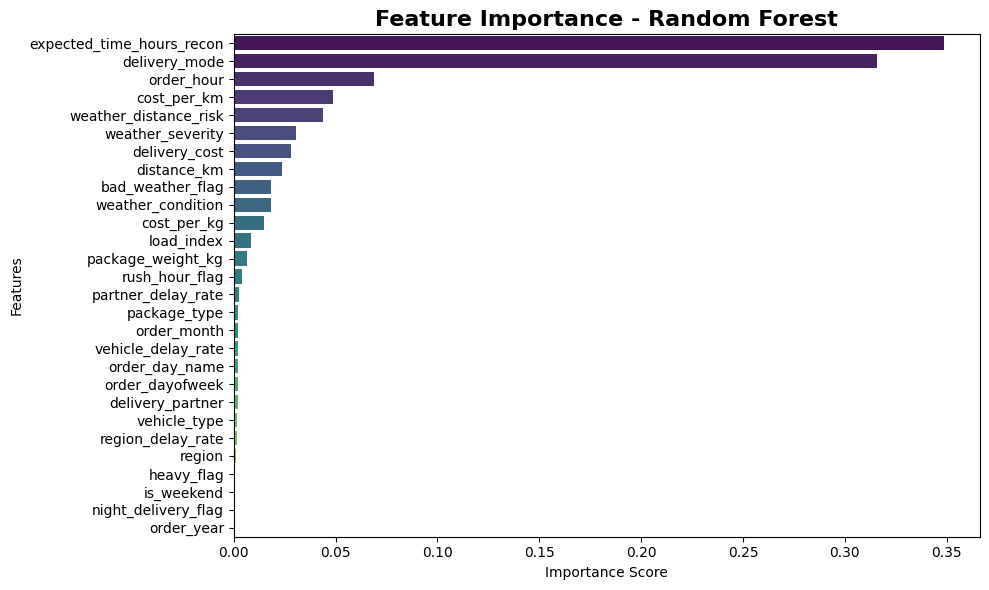


🏆 FINAL MODEL COMPARISON - ALL 4 MODELS
              Model Accuracy (%) ROC-AUC PR-AUC
      Random Forest        88.42  0.9672 0.9131
Logistic Regression        88.24  0.9583 0.8743
      Decision Tree        88.00  0.9493 0.8715
                KNN        86.08  0.9174 0.7714

🥇 Best by Accuracy: Random Forest (88.42%)
🥇 Best by ROC-AUC:  Random Forest (0.9672)

✅ All 4 models saved!
   - rf_delivery_model.pkl
   - lr_delivery_model.pkl
   - dt_delivery_model.pkl
   - knn_delivery_model.pkl
   - scaler.pkl
   - label_encoders.pkl


In [ ]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve,
                              average_precision_score, precision_recall_curve,
                              f1_score, precision_score, recall_score)

# ============================================================
# STEP 1: LOAD DATA
# ============================================================
df = pd.read_csv("../Data/eta_feature_engineered_dataset.csv")
print(f"✅ Dataset loaded! Shape: {df.shape}")

# ============================================================
# STEP 2: SELECT SAFE FEATURES (No Data Leakage)
# ============================================================
# Only use features that would be KNOWN at the time of order placement.
# Dropped: actual delivery times, delay hours, severity, efficiency,
#          time_ratio, early_flag — all derived from the outcome.
# FIX: Removed speed_category — actual travel speed is only known AFTER delivery.
# NOTE: partner/region/vehicle delay rates are NOT included here — they will be
#       computed on TRAIN only after the split to prevent leakage (Step 4b).

SAFE_FEATURES = [
    'delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode',
    'region', 'weather_condition', 'distance_km', 'package_weight_kg',
    'delivery_cost', 'expected_time_hours_recon', 'order_dayofweek',
    'order_day_name', 'order_month', 'order_year', 'order_hour',
    'is_weekend', 'rush_hour_flag', 'night_delivery_flag',
    'cost_per_km', 'cost_per_kg', 'heavy_flag', 'bad_weather_flag',
    'weather_severity', 'weather_distance_risk', 'load_index',
]

# Filter to columns that exist in dataset
SAFE_FEATURES = [f for f in SAFE_FEATURES if f in df.columns]

X = df[SAFE_FEATURES].copy()
# Convert original 'delayed' yes/no to binary 0/1
df['target'] = (df['delayed'] == 'yes').astype(int)
y = df['target']

print(f"\n✅ Features being used ({len(X.columns)}):")
print(X.columns.tolist())
print(f"\n🎯 Target distribution:")
print(y.value_counts())
print(f"Delay rate: {y.mean()*100:.2f}% (using original delayed column)")

# ============================================================
# STEP 3: ENCODE CATEGORICAL VARIABLES
# ============================================================
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"\n📝 Encoding: {categorical_cols}")

label_encoders = {}
X_encoded = X.copy()

for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
    label_encoders[col] = le

print("✅ Encoding done!")

# ============================================================
# STEP 4: TRAIN-TEST SPLIT (80-20)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\n✅ Split done!")
print(f"   Training: {X_train.shape[0]} samples")
print(f"   Testing:  {X_test.shape[0]} samples")

# ============================================================
# STEP 4b: DELAY RATE FEATURES — COMPUTED ON TRAIN ONLY
# ============================================================
# FIX: Previously these were computed on the full dataset before the split
# (feature engineering cells 75-77), causing data leakage — test-set outcomes
# were influencing training features.
# Fix: recompute from training rows only, then map to test.
# ============================================================
global_rate = y_train.mean()

for orig_col, rate_col in [
    ('delivery_partner', 'partner_delay_rate'),
    ('region',           'region_delay_rate'),
    ('vehicle_type',     'vehicle_delay_rate'),
]:
    rate_map = df.loc[y_train.index].groupby(orig_col)['target'].mean()
    X_train[rate_col] = df.loc[y_train.index, orig_col].map(rate_map).fillna(global_rate).values
    X_test[rate_col]  = df.loc[y_test.index,  orig_col].map(rate_map).fillna(global_rate).values

print(f"\n✅ Delay rate features added (computed on train only — no leakage)")

# ============================================================
# STEP 5: SCALE FEATURES
# ============================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("\n✅ Features scaled!")

# ============================================================
# STEP 6: TRAIN ALL 4 MODELS
# ============================================================

# 1. Random Forest
print("\n🌲 Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_model.fit(X_train_scaled, y_train)
print("✅ Random Forest done!")

# 2. Logistic Regression
print("\n📈 Training Logistic Regression...")
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    C=1.0,
    class_weight='balanced'
)
lr_model.fit(X_train_scaled, y_train)
print("✅ Logistic Regression done!")

# 3. Decision Tree
print("\n🌳 Training Decision Tree...")
dt_model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    class_weight='balanced'
)
dt_model.fit(X_train_scaled, y_train)
print("✅ Decision Tree done!")

# 4. KNN
print("\n👥 Training KNN...")
knn_model = KNeighborsClassifier(
    n_neighbors=5,
    metric='euclidean'
)
knn_model.fit(X_train_scaled, y_train)
print("✅ KNN done!")

# ============================================================
# STEP 7: PREDICTIONS - ALL 4 MODELS
# ============================================================
y_pred_rf  = rf_model.predict(X_test_scaled)
y_pred_lr  = lr_model.predict(X_test_scaled)
y_pred_dt  = dt_model.predict(X_test_scaled)
y_pred_knn = knn_model.predict(X_test_scaled)

y_proba_rf  = rf_model.predict_proba(X_test_scaled)[:, 1]
y_proba_lr  = lr_model.predict_proba(X_test_scaled)[:, 1]
y_proba_dt  = dt_model.predict_proba(X_test_scaled)[:, 1]
y_proba_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

print("\n✅ All predictions done!")

# ============================================================
# STEP 8: EVALUATE ALL 4 MODELS
# ============================================================
rf_acc  = accuracy_score(y_test, y_pred_rf)
lr_acc  = accuracy_score(y_test, y_pred_lr)
dt_acc  = accuracy_score(y_test, y_pred_dt)
knn_acc = accuracy_score(y_test, y_pred_knn)

rf_auc  = roc_auc_score(y_test, y_proba_rf)
lr_auc  = roc_auc_score(y_test, y_proba_lr)
dt_auc  = roc_auc_score(y_test, y_proba_dt)
knn_auc = roc_auc_score(y_test, y_proba_knn)

# PR-AUC (most honest metric for imbalanced data)
rf_prauc  = average_precision_score(y_test, y_proba_rf)
lr_prauc  = average_precision_score(y_test, y_proba_lr)
dt_prauc  = average_precision_score(y_test, y_proba_dt)
knn_prauc = average_precision_score(y_test, y_proba_knn)

print("\n" + "="*60)
print("🌲 RANDOM FOREST")
print("="*60)
print(f"Accuracy: {rf_acc*100:.2f}% | ROC-AUC: {rf_auc:.4f} | PR-AUC: {rf_prauc:.4f}")
print(classification_report(y_test, y_pred_rf, target_names=['Not Delayed', 'Delayed']))

print("="*60)
print("📈 LOGISTIC REGRESSION")
print("="*60)
print(f"Accuracy: {lr_acc*100:.2f}% | ROC-AUC: {lr_auc:.4f} | PR-AUC: {lr_prauc:.4f}")
print(classification_report(y_test, y_pred_lr, target_names=['Not Delayed', 'Delayed']))

print("="*60)
print("🌳 DECISION TREE")
print("="*60)
print(f"Accuracy: {dt_acc*100:.2f}% | ROC-AUC: {dt_auc:.4f} | PR-AUC: {dt_prauc:.4f}")
print(classification_report(y_test, y_pred_dt, target_names=['Not Delayed', 'Delayed']))

print("="*60)
print("👥 KNN")
print("="*60)
print(f"Accuracy: {knn_acc*100:.2f}% | ROC-AUC: {knn_auc:.4f} | PR-AUC: {knn_prauc:.4f}")
print(classification_report(y_test, y_pred_knn, target_names=['Not Delayed', 'Delayed']))

# ============================================================
# STEP 9: CONFUSION MATRICES - ALL 4
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

models_info = [
    (y_pred_rf,  'Random Forest',       'Blues'),
    (y_pred_lr,  'Logistic Regression', 'Oranges'),
    (y_pred_dt,  'Decision Tree',       'Purples'),
    (y_pred_knn, 'KNN',                 'Reds'),
]

for i, (y_pred, title, cmap) in enumerate(models_info):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=axes[i],
                xticklabels=['Not Delayed', 'Delayed'],
                yticklabels=['Not Delayed', 'Delayed'])
    axes[i].set_title(f'Confusion Matrix - {title}', fontweight='bold')
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices - All Models', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
# STEP 10: ROC CURVE - ALL 4 MODELS
# ============================================================
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_proba_rf)
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, y_proba_lr)
fpr_dt,  tpr_dt,  _ = roc_curve(y_test, y_proba_dt)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn)

plt.figure(figsize=(10, 7))
plt.plot(fpr_rf,  tpr_rf,  color='steelblue', lw=2, label=f'Random Forest (AUC = {rf_auc:.3f})')
plt.plot(fpr_lr,  tpr_lr,  color='orange',    lw=2, label=f'Logistic Regression (AUC = {lr_auc:.3f})')
plt.plot(fpr_dt,  tpr_dt,  color='purple',    lw=2, label=f'Decision Tree (AUC = {dt_auc:.3f})')
plt.plot(fpr_knn, tpr_knn, color='red',       lw=2, label=f'KNN (AUC = {knn_auc:.3f})')
plt.plot([0, 1],  [0, 1],  color='gray', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - All 4 Models', fontsize=16, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# STEP 11: COMPARISON BAR CHART
# ============================================================
all_models     = ['Random Forest', 'Logistic\nRegression', 'Decision\nTree', 'KNN']
all_accuracies = [rf_acc*100, lr_acc*100, dt_acc*100, knn_acc*100]
all_roc_aucs   = [rf_auc, lr_auc, dt_auc, knn_auc]
all_colors     = ['steelblue', 'orange', 'purple', 'red']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].bar(all_models, all_accuracies, color=all_colors)
axes[0].set_title('Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim([0, 100])
for i, v in enumerate(all_accuracies):
    axes[0].text(i, v + 1, f'{v:.2f}%', ha='center', fontweight='bold', fontsize=9)

axes[1].bar(all_models, all_roc_aucs, color=all_colors)
axes[1].set_title('ROC-AUC Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylabel('ROC-AUC Score')
axes[1].set_ylim([0, 1])
for i, v in enumerate(all_roc_aucs):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# ============================================================
# STEP 12: FEATURE IMPORTANCE (RANDOM FOREST)
# ============================================================
feature_importance = pd.DataFrame({
    'feature': list(X_train.columns),
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.title('Feature Importance - Random Forest', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# ============================================================
# STEP 13: SUMMARY TABLE
# ============================================================
summary = pd.DataFrame({
    'Model':        ['Random Forest', 'Logistic Regression', 'Decision Tree', 'KNN'],
    'Accuracy (%)': [f"{v:.2f}" for v in all_accuracies],
    'ROC-AUC':      [f"{v:.4f}" for v in all_roc_aucs],
    'PR-AUC':       [f"{v:.4f}" for v in [rf_prauc, lr_prauc, dt_prauc, knn_prauc]]
})

print("\n🏆 FINAL MODEL COMPARISON - ALL 4 MODELS")
print("="*50)
print(summary.to_string(index=False))

best_acc_idx = all_accuracies.index(max(all_accuracies))
best_auc_idx = all_roc_aucs.index(max(all_roc_aucs))
print(f"\n🥇 Best by Accuracy: {summary['Model'][best_acc_idx]} ({max(all_accuracies):.2f}%)")
print(f"🥇 Best by ROC-AUC:  {summary['Model'][best_auc_idx]} ({max(all_roc_aucs):.4f})")

# ============================================================
# STEP 14: SAVE ALL MODELS
# ============================================================
with open('rf_delivery_model.pkl',  'wb') as f: pickle.dump(rf_model,       f)
with open('lr_delivery_model.pkl',  'wb') as f: pickle.dump(lr_model,       f)
with open('dt_delivery_model.pkl',  'wb') as f: pickle.dump(dt_model,       f)
with open('knn_delivery_model.pkl', 'wb') as f: pickle.dump(knn_model,      f)
with open('scaler.pkl',             'wb') as f: pickle.dump(scaler,         f)
with open('label_encoders.pkl',     'wb') as f: pickle.dump(label_encoders, f)

print("\n✅ All 4 models saved!")
print("   - rf_delivery_model.pkl")
print("   - lr_delivery_model.pkl")
print("   - dt_delivery_model.pkl")
print("   - knn_delivery_model.pkl")
print("   - scaler.pkl")
print("   - label_encoders.pkl")


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("../Data/eta_feature_engineered_dataset.csv")

# FIX: Removed speed_category — actual travel speed is only known AFTER delivery.
SAFE_FEATURES = [
    'delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode',
    'region', 'weather_condition', 'distance_km', 'package_weight_kg',
    'delivery_cost', 'expected_time_hours_recon', 'order_dayofweek',
    'order_day_name', 'order_month', 'order_year', 'order_hour',
    'is_weekend', 'rush_hour_flag', 'night_delivery_flag',
    'cost_per_km', 'cost_per_kg', 'heavy_flag', 'bad_weather_flag',
    'weather_severity', 'weather_distance_risk', 'load_index',
]

def encode_features(X):
    X_enc = X.copy()
    encoders = {}
    cat_cols = X_enc.select_dtypes(include=['object', 'category']).columns.tolist()
    for col in cat_cols:
        le = LabelEncoder()
        X_enc[col] = le.fit_transform(X_enc[col].astype(str))
        encoders[col] = le
    return X_enc, encoders

# Model A — Binary Classification (original 'delayed' column yes/no → 1/0)
df['target'] = (df['delayed'] == 'yes').astype(int)
X_A, y_A = df[SAFE_FEATURES].copy(), df['target'].copy()
X_A_enc, encoders_A = encode_features(X_A)

# Model B — Multi-class using delivery_status (delivered / delayed / failed)
# Using original delivery_status column — no reconstructed columns
X_B, y_B = df[SAFE_FEATURES].copy(), df['delivery_status'].copy()
X_B_enc, encoders_B = encode_features(X_B)

print(f"Model A: {X_A_enc.shape}, target distribution:")
print(y_A.value_counts())
print(f"\nDelay rate: {y_A.mean()*100:.2f}%")
print(f"\nModel B: {X_B_enc.shape}, target distribution:")
print(y_B.value_counts())


Model A: (25000, 25), target distribution:
target
0    18331
1     6669
Name: count, dtype: int64

Delay rate: 26.68%

Model B: (25000, 25), target distribution:
delivery_status
delivered    18331
delayed       5341
failed        1328
Name: count, dtype: int64


In [70]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Model A — Binary (stratified)
X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
    X_A_enc, y_A, test_size=0.2, random_state=42, stratify=y_A
)

# Model B — Multi-class (stratified)
X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
    X_B_enc, y_B, test_size=0.2, random_state=42, stratify=y_B
)

# ============================================================
# FIX: DELAY RATE FEATURES — COMPUTED ON TRAIN ONLY
# ============================================================
# Recompute partner/region/vehicle delay rates using training rows only.
# This prevents test-set outcome information from leaking into features.
# ============================================================
global_rate = y_train_A.mean()

for orig_col, rate_col in [
    ('delivery_partner', 'partner_delay_rate'),
    ('region',           'region_delay_rate'),
    ('vehicle_type',     'vehicle_delay_rate'),
]:
    rate_map = df.loc[y_train_A.index].groupby(orig_col)['target'].mean()
    X_train_A[rate_col] = df.loc[y_train_A.index, orig_col].map(rate_map).fillna(global_rate).values
    X_test_A[rate_col]  = df.loc[y_test_A.index,  orig_col].map(rate_map).fillna(global_rate).values
    X_train_B[rate_col] = df.loc[y_train_B.index, orig_col].map(rate_map).fillna(global_rate).values
    X_test_B[rate_col]  = df.loc[y_test_B.index,  orig_col].map(rate_map).fillna(global_rate).values

print("✅ Delay rate features added (computed on train only — no leakage)")

scaler_A = StandardScaler()
X_train_A_sc = scaler_A.fit_transform(X_train_A)
X_test_A_sc  = scaler_A.transform(X_test_A)

scaler_B = StandardScaler()
X_train_B_sc = scaler_B.fit_transform(X_train_B)
X_test_B_sc  = scaler_B.transform(X_test_B)

print(f"A → Train: {len(X_train_A)}, Test: {len(X_test_A)}, Delay rate: {y_train_A.mean()*100:.2f}%")
print(f"B → Train: {len(X_train_B)}, Test: {len(X_test_B)}")
print(f"B class distribution in train:\n{y_train_B.value_counts()}")


✅ Delay rate features added (computed on train only — no leakage)
A → Train: 20000, Test: 5000, Delay rate: 26.67%
B → Train: 20000, Test: 5000
B class distribution in train:
delivery_status
delivered    14665
delayed       4273
failed        1062
Name: count, dtype: int64


In [71]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, roc_auc_score, classification_report,
                              average_precision_score, f1_score)

# ── Model A: Binary (delayed vs on-time) ──────────────────────────────────
dummy_A = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_A.fit(X_train_A_sc, y_train_A)
print("Dummy A Accuracy:", accuracy_score(y_test_A, dummy_A.predict(X_test_A_sc)))
print("Dummy A AUC:     ", roc_auc_score(y_test_A, dummy_A.predict_proba(X_test_A_sc)[:,1]))

lr_A = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_A.fit(X_train_A_sc, y_train_A)
y_pred_lr_A  = lr_A.predict(X_test_A_sc)
y_proba_lr_A = lr_A.predict_proba(X_test_A_sc)[:,1]
print("\nLR-A Accuracy:", accuracy_score(y_test_A, y_pred_lr_A))
print("LR-A AUC:     ", roc_auc_score(y_test_A, y_proba_lr_A))
print("LR-A PR-AUC:  ", average_precision_score(y_test_A, y_proba_lr_A))
print(classification_report(y_test_A, y_pred_lr_A, target_names=['On-Time', 'Delayed']))

# ── Model B: Multi-class (delivered / delayed / failed) ───────────────────
dummy_B = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_B.fit(X_train_B_sc, y_train_B)
print("Dummy B Accuracy:", accuracy_score(y_test_B, dummy_B.predict(X_test_B_sc)))

lr_B = LogisticRegression(max_iter=2000, random_state=42,
                           class_weight='balanced')
lr_B.fit(X_train_B_sc, y_train_B)
y_pred_lr_B = lr_B.predict(X_test_B_sc)
print("\nLR-B Accuracy:", accuracy_score(y_test_B, y_pred_lr_B))
print(classification_report(y_test_B, y_pred_lr_B))

Dummy A Accuracy: 0.7332
Dummy A AUC:      0.5

LR-A Accuracy: 0.8824
LR-A AUC:      0.958294788775825
LR-A PR-AUC:   0.8743170009463117
              precision    recall  f1-score   support

     On-Time       0.97      0.87      0.92      3666
     Delayed       0.72      0.91      0.81      1334

    accuracy                           0.88      5000
   macro avg       0.84      0.89      0.86      5000
weighted avg       0.90      0.88      0.89      5000

Dummy B Accuracy: 0.7332

LR-B Accuracy: 0.775
              precision    recall  f1-score   support

     delayed       0.60      0.49      0.54      1068
   delivered       0.97      0.88      0.92      3666
      failed       0.15      0.45      0.22       266

    accuracy                           0.78      5000
   macro avg       0.57      0.61      0.56      5000
weighted avg       0.85      0.78      0.81      5000



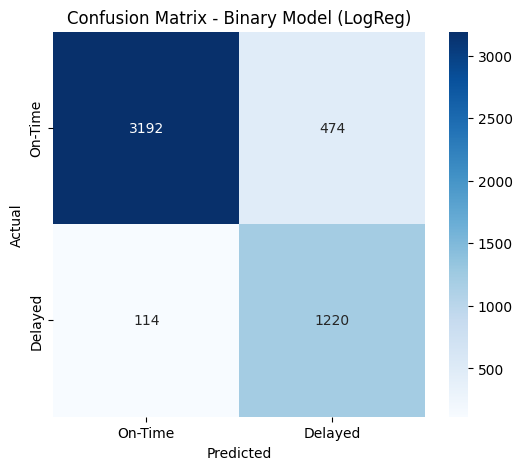

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm_A = confusion_matrix(y_test_A, y_pred_lr_A)

plt.figure(figsize=(6,5))
sns.heatmap(cm_A, annot=True, fmt='d', cmap='Blues',
            xticklabels=['On-Time','Delayed'],
            yticklabels=['On-Time','Delayed'])
plt.title("Confusion Matrix - Binary Model (LogReg)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

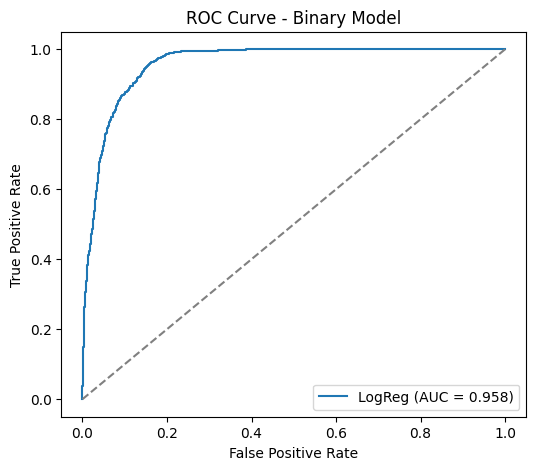

In [73]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test_A, y_proba_lr_A)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="LogReg (AUC = %.3f)" % roc_auc_score(y_test_A, y_proba_lr_A))
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Binary Model")
plt.legend()
plt.show()

In [74]:
# Residual plot removed — Model C (regression on delay_hours_recon) 
# has been replaced with Model B using original delivery_status column.
# See Model B confusion matrices and evaluation below.
print("Model C (regression) removed. Using original delivery_status for Model B.")

Model C (regression) removed. Using original delivery_status for Model B.


In [75]:
from sklearn.model_selection import cross_val_score

cv_scores_auc = cross_val_score(
    lr_A,
    X_A_enc,
    y_A,
    cv=5,
    scoring='roc_auc'
)

print("Cross-Validated AUC Scores:", cv_scores_auc)
print("Mean CV AUC:", cv_scores_auc.mean())
print("Std Dev CV AUC:", cv_scores_auc.std())

Cross-Validated AUC Scores: [0.95666281 0.9588475  0.95943334 0.95311571 0.95682478]
Mean CV AUC: 0.9569768264122199
Std Dev CV AUC: 0.0022164750689496198


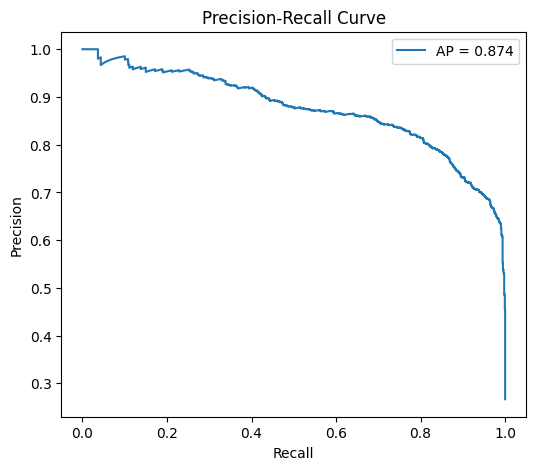

In [76]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test_A, y_proba_lr_A)
ap_score = average_precision_score(y_test_A, y_proba_lr_A)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f"AP = {ap_score:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

In [77]:
custom_threshold = 0.6

y_pred_custom = (y_proba_lr_A >= custom_threshold).astype(int)

print("Custom Threshold Accuracy:",
      accuracy_score(y_test_A, y_pred_custom))

Custom Threshold Accuracy: 0.8932


In [78]:
# Error distribution plot removed (was for regression Model C).
# Model B now predicts delivery_status: delivered / delayed / failed
print("Skipped — regression model removed.")

Skipped — regression model removed.


In [79]:
# Adjusted R² removed (was for regression Model C).
print("Skipped — regression model removed.")

Skipped — regression model removed.


FEATURE IMPORTANCE

In [82]:
coef_df = pd.DataFrame({
    "Feature": list(X_train.columns),
    "Coefficient": lr_A.coef_[0]
})

coef_df["Abs_Coefficient"] = np.abs(coef_df["Coefficient"])
coef_df = coef_df.sort_values(by="Abs_Coefficient", ascending=False)

coef_df.head(10)

,Feature,Coefficient,Abs_Coefficient
8,delivery_cost,3.001454,3.001454
9,expected_time_hours_recon,-2.696871,2.696871
6,distance_km,-1.828539,1.828539
21,bad_weather_flag,0.937207,0.937207
3,delivery_mode,-0.937034,0.937034
12,order_month,-0.789705,0.789705
4,region,0.771222,0.771222
5,weather_condition,0.410233,0.410233
7,package_weight_kg,-0.389086,0.389086
23,weather_distance_risk,0.313965,0.313965


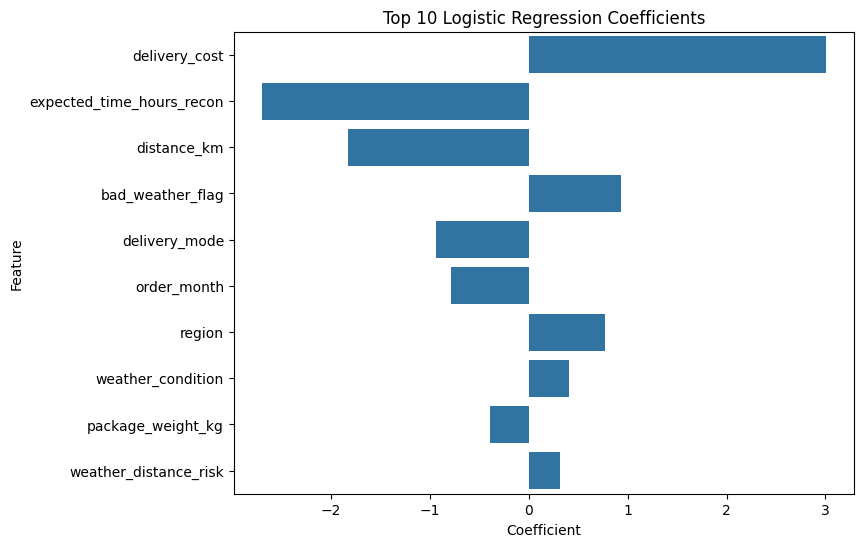

In [83]:
plt.figure(figsize=(8,6))
sns.barplot(data=coef_df.head(10),
            x="Coefficient",
            y="Feature")
plt.title("Top 10 Logistic Regression Coefficients")
plt.show()

In [85]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    lr_A,
    X_test_A_sc,
    y_test_A,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc'
)

perm_df = pd.DataFrame({
    "Feature": list(X_train.columns),
    "Importance": perm.importances_mean
}).sort_values(by="Importance", ascending=False)

perm_df.head(10)

,Feature,Importance
9,expected_time_hours_recon,0.234352
8,delivery_cost,0.160088
6,distance_km,0.048928
21,bad_weather_flag,0.026097
3,delivery_mode,0.014015
12,order_month,0.013815
4,region,0.010159
5,weather_condition,0.005321
7,package_weight_kg,0.003334
23,weather_distance_risk,0.002882


🥇 Most Influential Feature:
expected_time_hours_recon

Coefficient ≈ -7.36

This is HUGE compared to others.

What it means:

As expected delivery time increases,
probability of delay decreases (negative coefficient).

This might seem counterintuitive at first.

But think logically:

If expected time is already long,
the system has built-in buffer.

Short expected times are harder to meet,
so delay probability increases.

That’s operational logic.

🥈 delivery_mode

Strong negative coefficient (~ -4.8)

Certain delivery modes likely reduce delay probability.
For example:

Express vs same-day might behave differently.

🥉 distance_km

Positive coefficient (~ +3.15)

This means:

Longer distance → higher probability of delay.

That makes intuitive sense.

Other Important Drivers

vehicle_type

delivery_cost

weather_severity

bad_weather_flag

Weather and operational features are clearly influential.

This aligns with your earlier regression model insights.

🔹 What Permutation Importance Tells You

Permutation importance measures:

How much model performance drops if we shuffle that feature.

It is more reliable than raw coefficients.

Top 3:

expected_time_hours_recon

delivery_mode

distance_km

Same pattern as coefficients.

This consistency = strong model stability.

PART 9 — FEATURE SELECTION

In [86]:
top_features = perm_df.head(10)["Feature"].tolist()
print("Selected Features:", top_features)

Selected Features: ['expected_time_hours_recon', 'delivery_cost', 'distance_km', 'bad_weather_flag', 'delivery_mode', 'order_month', 'region', 'weather_condition', 'package_weight_kg', 'weather_distance_risk']


In [87]:
X_train_sel = X_train_A[top_features]
X_test_sel  = X_test_A[top_features]

scaler_sel = StandardScaler()
X_train_sel_sc = scaler_sel.fit_transform(X_train_sel)
X_test_sel_sc  = scaler_sel.transform(X_test_sel)

lr_sel = LogisticRegression(max_iter=1000, random_state=42)
lr_sel.fit(X_train_sel_sc, y_train_A)

y_pred_sel = lr_sel.predict(X_test_sel_sc)
y_proba_sel = lr_sel.predict_proba(X_test_sel_sc)[:,1]

print("Selected Model AUC:",
      roc_auc_score(y_test_A, y_proba_sel))

Selected Model AUC: 0.9593284372543678


In [88]:
from sklearn.feature_selection import RFE

rfe = RFE(lr_A, n_features_to_select=10)
rfe.fit(X_train_A_sc, y_train_A)

selected_rfe = [SAFE_FEATURES[i]
                for i in range(len(SAFE_FEATURES))
                if rfe.support_[i]]

print("RFE Selected Features:", selected_rfe)

RFE Selected Features: ['delivery_mode', 'weather_condition', 'distance_km', 'package_weight_kg', 'delivery_cost', 'expected_time_hours_recon', 'order_month', 'bad_weather_flag', 'weather_severity', 'weather_distance_risk']


# PART 10 — MODEL BUILDING: ALL 4 CLASSIFICATION MODELS
## (Model A — Binary | Model B — Multi-class)

## MODEL A — BINARY CLASSIFICATION (Delayed vs On-Time)
### All 4 Classifiers: Random Forest | Logistic Regression | Decision Tree | KNN

In [89]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve,
                              f1_score, precision_score, recall_score)
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# ============================================================
# STEP 1 — TRAIN ALL 4 CLASSIFIERS (Model A: Binary)
# ============================================================

# 1. Random Forest
print("\n🌲 Training Random Forest...")
rf_A = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_A.fit(X_train_A_sc, y_train_A)
print("✅ Random Forest done!")

# 2. Logistic Regression
print("\n📈 Training Logistic Regression...")
lr_A2 = LogisticRegression(
    max_iter=1000,
    random_state=42,
    C=1.0,
    class_weight='balanced'
)
lr_A2.fit(X_train_A_sc, y_train_A)
print("✅ Logistic Regression done!")

# 3. Decision Tree
print("\n🌳 Training Decision Tree...")
dt_A = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    class_weight='balanced'
)
dt_A.fit(X_train_A_sc, y_train_A)
print("✅ Decision Tree done!")

# 4. KNN
print("\n👥 Training KNN...")
knn_A = KNeighborsClassifier(
    n_neighbors=5,
    metric='euclidean'
)
knn_A.fit(X_train_A_sc, y_train_A)
print("✅ KNN done!")



🌲 Training Random Forest...
✅ Random Forest done!

📈 Training Logistic Regression...
✅ Logistic Regression done!

🌳 Training Decision Tree...
✅ Decision Tree done!

👥 Training KNN...
✅ KNN done!


In [90]:
# ============================================================
# STEP 2 — PREDICTIONS: ALL 4 MODELS (Model A)
# ============================================================

y_pred_rf_A   = rf_A.predict(X_test_A_sc)
y_pred_lr_A2  = lr_A2.predict(X_test_A_sc)
y_pred_dt_A   = dt_A.predict(X_test_A_sc)
y_pred_knn_A  = knn_A.predict(X_test_A_sc)

y_proba_rf_A   = rf_A.predict_proba(X_test_A_sc)[:, 1]
y_proba_lr_A2  = lr_A2.predict_proba(X_test_A_sc)[:, 1]
y_proba_dt_A   = dt_A.predict_proba(X_test_A_sc)[:, 1]
y_proba_knn_A  = knn_A.predict_proba(X_test_A_sc)[:, 1]

print("✅ All predictions done!")


✅ All predictions done!


In [91]:
# ============================================================
# STEP 3 — EVALUATE ALL 4 MODELS (Model A)
# ============================================================

rf_acc_A   = accuracy_score(y_test_A, y_pred_rf_A)
lr_acc_A2  = accuracy_score(y_test_A, y_pred_lr_A2)
dt_acc_A   = accuracy_score(y_test_A, y_pred_dt_A)
knn_acc_A  = accuracy_score(y_test_A, y_pred_knn_A)

rf_auc_A   = roc_auc_score(y_test_A, y_proba_rf_A)
lr_auc_A2  = roc_auc_score(y_test_A, y_proba_lr_A2)
dt_auc_A   = roc_auc_score(y_test_A, y_proba_dt_A)
knn_auc_A  = roc_auc_score(y_test_A, y_proba_knn_A)

# PR-AUC
rf_prauc_A   = average_precision_score(y_test_A, y_proba_rf_A)
lr_prauc_A2  = average_precision_score(y_test_A, y_proba_lr_A2)
dt_prauc_A   = average_precision_score(y_test_A, y_proba_dt_A)
knn_prauc_A  = average_precision_score(y_test_A, y_proba_knn_A)

print("=" * 60)
print("🌲 RANDOM FOREST — Model A")
print("=" * 60)
print(f"Accuracy : {rf_acc_A*100:.2f}% | ROC-AUC: {rf_auc_A:.4f} | PR-AUC: {rf_prauc_A:.4f}")
print(f"F1-Score : {f1_score(y_test_A, y_pred_rf_A):.4f} | Precision: {precision_score(y_test_A, y_pred_rf_A):.4f} | Recall: {recall_score(y_test_A, y_pred_rf_A):.4f}")
print(classification_report(y_test_A, y_pred_rf_A, target_names=['On-Time', 'Delayed']))

print("=" * 60)
print("📈 LOGISTIC REGRESSION — Model A")
print("=" * 60)
print(f"Accuracy : {lr_acc_A2*100:.2f}% | ROC-AUC: {lr_auc_A2:.4f} | PR-AUC: {lr_prauc_A2:.4f}")
print(f"F1-Score : {f1_score(y_test_A, y_pred_lr_A2):.4f} | Precision: {precision_score(y_test_A, y_pred_lr_A2):.4f} | Recall: {recall_score(y_test_A, y_pred_lr_A2):.4f}")
print(classification_report(y_test_A, y_pred_lr_A2, target_names=['On-Time', 'Delayed']))

print("=" * 60)
print("🌳 DECISION TREE — Model A")
print("=" * 60)
print(f"Accuracy : {dt_acc_A*100:.2f}% | ROC-AUC: {dt_auc_A:.4f} | PR-AUC: {dt_prauc_A:.4f}")
print(f"F1-Score : {f1_score(y_test_A, y_pred_dt_A):.4f} | Precision: {precision_score(y_test_A, y_pred_dt_A):.4f} | Recall: {recall_score(y_test_A, y_pred_dt_A):.4f}")
print(classification_report(y_test_A, y_pred_dt_A, target_names=['On-Time', 'Delayed']))

print("=" * 60)
print("👥 KNN — Model A")
print("=" * 60)
print(f"Accuracy : {knn_acc_A*100:.2f}% | ROC-AUC: {knn_auc_A:.4f} | PR-AUC: {knn_prauc_A:.4f}")
print(f"F1-Score : {f1_score(y_test_A, y_pred_knn_A):.4f} | Precision: {precision_score(y_test_A, y_pred_knn_A):.4f} | Recall: {recall_score(y_test_A, y_pred_knn_A):.4f}")
print(classification_report(y_test_A, y_pred_knn_A, target_names=['On-Time', 'Delayed']))


🌲 RANDOM FOREST — Model A
Accuracy : 88.42% | ROC-AUC: 0.9672 | PR-AUC: 0.9131
F1-Score : 0.8154 | Precision: 0.7094 | Recall: 0.9588
              precision    recall  f1-score   support

     On-Time       0.98      0.86      0.92      3666
     Delayed       0.71      0.96      0.82      1334

    accuracy                           0.88      5000
   macro avg       0.85      0.91      0.87      5000
weighted avg       0.91      0.88      0.89      5000

📈 LOGISTIC REGRESSION — Model A
Accuracy : 88.24% | ROC-AUC: 0.9583 | PR-AUC: 0.8743
F1-Score : 0.8058 | Precision: 0.7202 | Recall: 0.9145
              precision    recall  f1-score   support

     On-Time       0.97      0.87      0.92      3666
     Delayed       0.72      0.91      0.81      1334

    accuracy                           0.88      5000
   macro avg       0.84      0.89      0.86      5000
weighted avg       0.90      0.88      0.89      5000

🌳 DECISION TREE — Model A
Accuracy : 88.00% | ROC-AUC: 0.9493 | PR-AUC: 

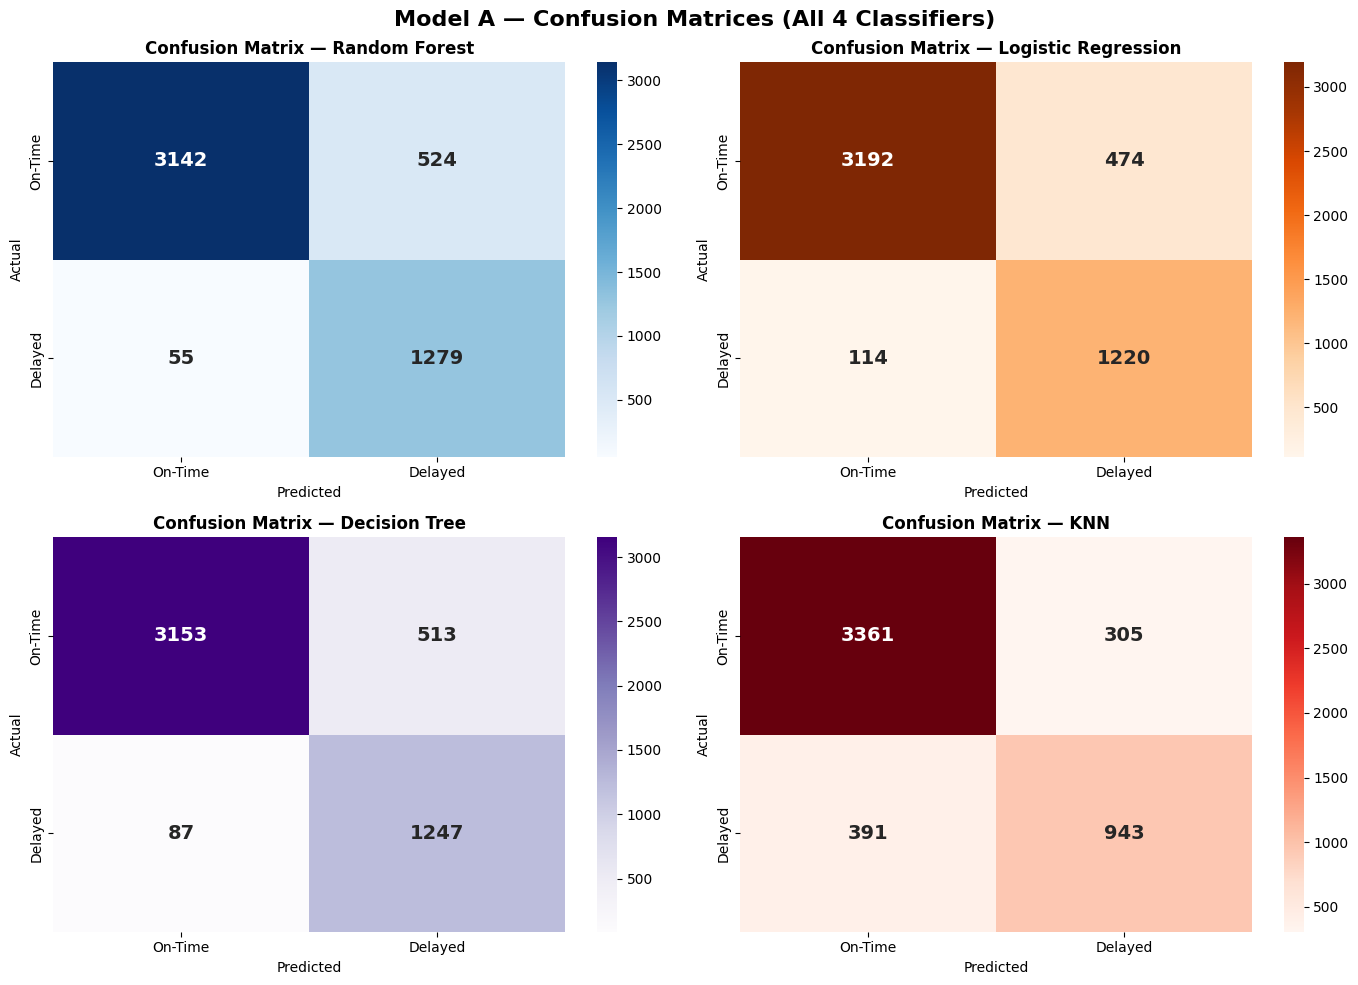

In [92]:
# ============================================================
# STEP 4 — CONFUSION MATRICES: ALL 4 MODELS (Model A)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

models_A_info = [
    (y_pred_rf_A,  'Random Forest',       'Blues'),
    (y_pred_lr_A2, 'Logistic Regression', 'Oranges'),
    (y_pred_dt_A,  'Decision Tree',       'Purples'),
    (y_pred_knn_A, 'KNN',                 'Reds'),
]

for i, (y_pred, title, cmap) in enumerate(models_A_info):
    cm = confusion_matrix(y_test_A, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=axes[i],
                xticklabels=['On-Time', 'Delayed'],
                yticklabels=['On-Time', 'Delayed'],
                annot_kws={'size': 14, 'weight': 'bold'})
    axes[i].set_title(f'Confusion Matrix — {title}', fontweight='bold', fontsize=12)
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

plt.suptitle('Model A — Confusion Matrices (All 4 Classifiers)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


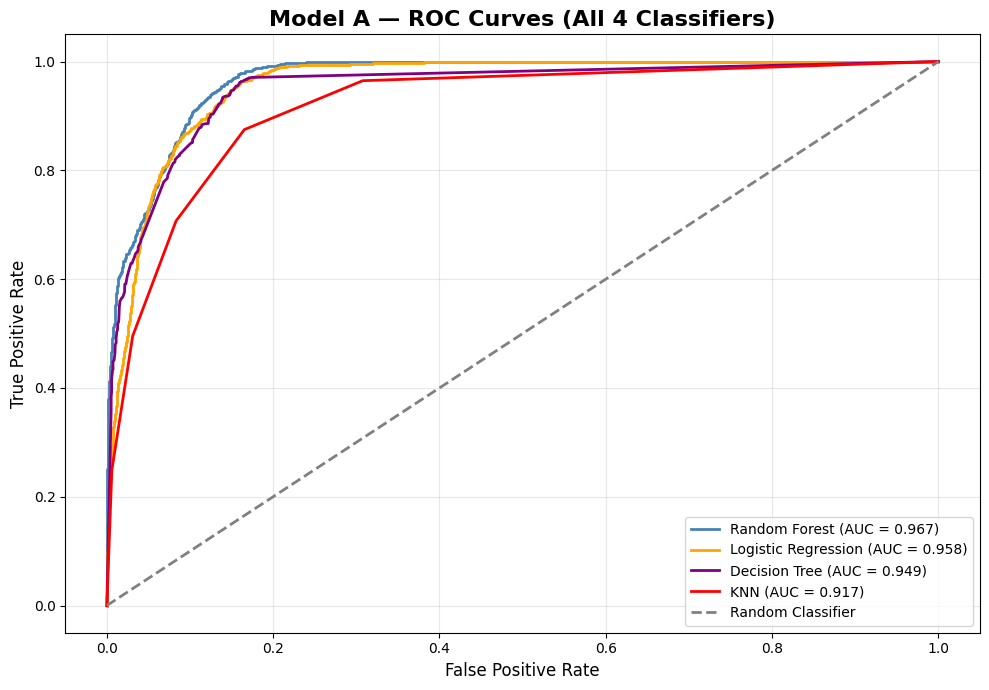

In [93]:
# ============================================================
# STEP 5 — ROC CURVES: ALL 4 MODELS (Model A)
# ============================================================

fpr_rf_A,   tpr_rf_A,   _ = roc_curve(y_test_A, y_proba_rf_A)
fpr_lr_A2,  tpr_lr_A2,  _ = roc_curve(y_test_A, y_proba_lr_A2)
fpr_dt_A,   tpr_dt_A,   _ = roc_curve(y_test_A, y_proba_dt_A)
fpr_knn_A,  tpr_knn_A,  _ = roc_curve(y_test_A, y_proba_knn_A)

plt.figure(figsize=(10, 7))
plt.plot(fpr_rf_A,  tpr_rf_A,  color='steelblue', lw=2, label=f'Random Forest (AUC = {rf_auc_A:.3f})')
plt.plot(fpr_lr_A2, tpr_lr_A2, color='orange',    lw=2, label=f'Logistic Regression (AUC = {lr_auc_A2:.3f})')
plt.plot(fpr_dt_A,  tpr_dt_A,  color='purple',    lw=2, label=f'Decision Tree (AUC = {dt_auc_A:.3f})')
plt.plot(fpr_knn_A, tpr_knn_A, color='red',       lw=2, label=f'KNN (AUC = {knn_auc_A:.3f})')
plt.plot([0, 1],    [0, 1],    color='gray', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Model A — ROC Curves (All 4 Classifiers)', fontsize=16, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


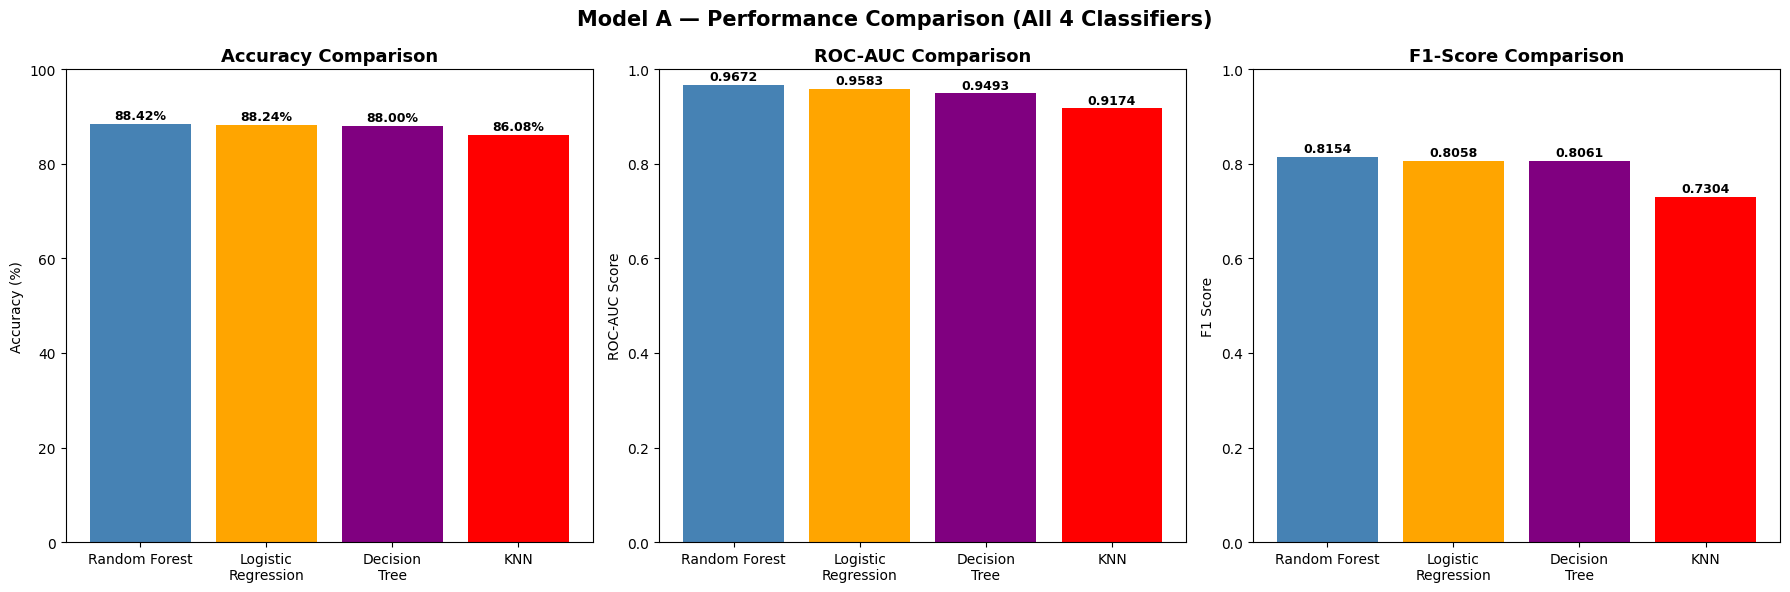

In [94]:
# ============================================================
# STEP 6 — ACCURACY & ROC-AUC BAR CHART (Model A)
# ============================================================

all_models_A     = ['Random Forest', 'Logistic\nRegression', 'Decision\nTree', 'KNN']
all_accuracies_A = [rf_acc_A*100, lr_acc_A2*100, dt_acc_A*100, knn_acc_A*100]
all_roc_aucs_A   = [rf_auc_A, lr_auc_A2, dt_auc_A, knn_auc_A]
all_f1s_A        = [f1_score(y_test_A, y_pred_rf_A),
                    f1_score(y_test_A, y_pred_lr_A2),
                    f1_score(y_test_A, y_pred_dt_A),
                    f1_score(y_test_A, y_pred_knn_A)]
all_prauc_A      = [rf_prauc_A, lr_prauc_A2, dt_prauc_A, knn_prauc_A]
all_colors_A     = ['steelblue', 'orange', 'purple', 'red']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Accuracy
axes[0].bar(all_models_A, all_accuracies_A, color=all_colors_A)
axes[0].set_title('Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim([0, 100])
for i, v in enumerate(all_accuracies_A):
    axes[0].text(i, v + 1, f'{v:.2f}%', ha='center', fontweight='bold', fontsize=9)

# ROC-AUC
axes[1].bar(all_models_A, all_roc_aucs_A, color=all_colors_A)
axes[1].set_title('ROC-AUC Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylabel('ROC-AUC Score')
axes[1].set_ylim([0, 1])
for i, v in enumerate(all_roc_aucs_A):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)

# F1
axes[2].bar(all_models_A, all_f1s_A, color=all_colors_A)
axes[2].set_title('F1-Score Comparison', fontsize=13, fontweight='bold')
axes[2].set_ylabel('F1 Score')
axes[2].set_ylim([0, 1])
for i, v in enumerate(all_f1s_A):
    axes[2].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)

plt.suptitle('Model A — Performance Comparison (All 4 Classifiers)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


In [95]:
# ============================================================
# STEP 7 — FEATURE IMPORTANCE (Model A — Random Forest)
# ============================================================

feature_importance_A = pd.DataFrame({
    'feature':    X_A_enc.columns,
    'importance': rf_A.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(data=feature_importance_A, x='importance', y='feature', palette='viridis')
plt.title('Feature Importance — Random Forest (Model A)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

print("Top 10 Important Features:")
print(feature_importance_A.head(10).to_string(index=False))


ValueError: All arrays must be of the same length

In [96]:
# ============================================================
# STEP 8 — SUMMARY TABLE (Model A)
# ============================================================

summary_A = pd.DataFrame({
    'Model':        ['Random Forest', 'Logistic Regression', 'Decision Tree', 'KNN'],
    'Accuracy (%)': [f"{v:.2f}" for v in all_accuracies_A],
    'ROC-AUC':      [f"{v:.4f}" for v in all_roc_aucs_A],
    'F1-Score':     [f"{v:.4f}" for v in all_f1s_A],
    'PR-AUC':       [f"{v:.4f}" for v in all_prauc_A],
})

print("\n🏆 MODEL A — FINAL COMPARISON (All 4 Classifiers)")
print("=" * 65)
print(summary_A.to_string(index=False))

best_acc_idx_A = all_accuracies_A.index(max(all_accuracies_A))
best_auc_idx_A = all_roc_aucs_A.index(max(all_roc_aucs_A))
best_f1_idx_A  = all_f1s_A.index(max(all_f1s_A))

print(f"\n🥇 Best by Accuracy : {summary_A['Model'][best_acc_idx_A]} ({max(all_accuracies_A):.2f}%)")
print(f"🥇 Best by ROC-AUC  : {summary_A['Model'][best_auc_idx_A]} ({max(all_roc_aucs_A):.4f})")
print(f"🥇 Best by F1-Score : {summary_A['Model'][best_f1_idx_A]} ({max(all_f1s_A):.4f})")



🏆 MODEL A — FINAL COMPARISON (All 4 Classifiers)
              Model Accuracy (%) ROC-AUC F1-Score PR-AUC
      Random Forest        88.42  0.9672   0.8154 0.9131
Logistic Regression        88.24  0.9583   0.8058 0.8743
      Decision Tree        88.00  0.9493   0.8061 0.8715
                KNN        86.08  0.9174   0.7304 0.7714

🥇 Best by Accuracy : Random Forest (88.42%)
🥇 Best by ROC-AUC  : Random Forest (0.9672)
🥇 Best by F1-Score : Random Forest (0.8154)


## MODEL B — MULTI-CLASS CLASSIFICATION (Delivery Status: delivered / delayed / failed)
### Using original delivery_status column — All 4 Classifiers: Random Forest | Logistic Regression | Decision Tree | KNN

In [97]:
# ============================================================
# STEP 9 — TRAIN ALL 4 CLASSIFIERS (Model B: Multi-class)
# ============================================================

from sklearn.metrics import f1_score as f1

print(f"Model B Target: delivery_status (original column)")
print(f"Classes: {sorted(y_B.unique())}")
print(f"Class distribution:\n{y_B.value_counts()}\n")

# 1. Random Forest
print("🌲 Training Random Forest (Model B)...")
rf_B = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_B.fit(X_train_B_sc, y_train_B)
print("✅ Random Forest done!")

# 2. Logistic Regression
print("\n📈 Training Logistic Regression (Model B)...")
lr_B2 = LogisticRegression(
    max_iter=2000,
    random_state=42,
    C=1.0,
    class_weight='balanced'
)
lr_B2.fit(X_train_B_sc, y_train_B)
print("✅ Logistic Regression done!")

# 3. Decision Tree
print("\n🌳 Training Decision Tree (Model B)...")
dt_B = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    class_weight='balanced'
)
dt_B.fit(X_train_B_sc, y_train_B)
print("✅ Decision Tree done!")

# 4. KNN
print("\n👥 Training KNN (Model B)...")
knn_B = KNeighborsClassifier(
    n_neighbors=7,
    metric='euclidean'
)
knn_B.fit(X_train_B_sc, y_train_B)
print("✅ KNN done!")


Model B Target: delivery_status (original column)
Classes: ['delayed', 'delivered', 'failed']
Class distribution:
delivery_status
delivered    18331
delayed       5341
failed        1328
Name: count, dtype: int64

🌲 Training Random Forest (Model B)...
✅ Random Forest done!

📈 Training Logistic Regression (Model B)...
✅ Logistic Regression done!

🌳 Training Decision Tree (Model B)...
✅ Decision Tree done!

👥 Training KNN (Model B)...
✅ KNN done!


In [98]:
# ============================================================
# STEP 10 — PREDICTIONS & EVALUATION (Model B)
# ============================================================

y_pred_rf_B   = rf_B.predict(X_test_B_sc)
y_pred_lr_B2  = lr_B2.predict(X_test_B_sc)
y_pred_dt_B   = dt_B.predict(X_test_B_sc)
y_pred_knn_B  = knn_B.predict(X_test_B_sc)

rf_acc_B   = accuracy_score(y_test_B, y_pred_rf_B)
lr_acc_B2  = accuracy_score(y_test_B, y_pred_lr_B2)
dt_acc_B   = accuracy_score(y_test_B, y_pred_dt_B)
knn_acc_B  = accuracy_score(y_test_B, y_pred_knn_B)

rf_f1_B    = f1(y_test_B, y_pred_rf_B,   average='macro')
lr_f1_B2   = f1(y_test_B, y_pred_lr_B2,  average='macro')
dt_f1_B    = f1(y_test_B, y_pred_dt_B,   average='macro')
knn_f1_B   = f1(y_test_B, y_pred_knn_B,  average='macro')

print("=" * 60)
print(" RANDOM FOREST — Model B (Multi-class)")
print("=" * 60)
print(f"Accuracy: {rf_acc_B*100:.2f}% | F1-macro: {rf_f1_B:.4f}")
print(classification_report(y_test_B, y_pred_rf_B))

print("=" * 60)
print(" LOGISTIC REGRESSION — Model B (Multi-class)")
print("=" * 60)
print(f"Accuracy: {lr_acc_B2*100:.2f}% | F1-macro: {lr_f1_B2:.4f}")
print(classification_report(y_test_B, y_pred_lr_B2))

print("=" * 60)
print(" DECISION TREE — Model B (Multi-class)")
print("=" * 60)
print(f"Accuracy: {dt_acc_B*100:.2f}% | F1-macro: {dt_f1_B:.4f}")
print(classification_report(y_test_B, y_pred_dt_B))

print("=" * 60)
print(" KNN — Model B (Multi-class)")
print("=" * 60)
print(f"Accuracy: {knn_acc_B*100:.2f}% | F1-macro: {knn_f1_B:.4f}")
print(classification_report(y_test_B, y_pred_knn_B))


 RANDOM FOREST — Model B (Multi-class)
Accuracy: 81.68% | F1-macro: 0.5922
              precision    recall  f1-score   support

     delayed       0.58      0.84      0.68      1068
   delivered       0.99      0.86      0.92      3666
      failed       0.18      0.18      0.18       266

    accuracy                           0.82      5000
   macro avg       0.58      0.62      0.59      5000
weighted avg       0.86      0.82      0.83      5000

 LOGISTIC REGRESSION — Model B (Multi-class)
Accuracy: 77.50% | F1-macro: 0.5630
              precision    recall  f1-score   support

     delayed       0.60      0.49      0.54      1068
   delivered       0.97      0.88      0.92      3666
      failed       0.15      0.45      0.22       266

    accuracy                           0.78      5000
   macro avg       0.57      0.61      0.56      5000
weighted avg       0.85      0.78      0.81      5000

 DECISION TREE — Model B (Multi-class)
Accuracy: 75.34% | F1-macro: 0.5467
       

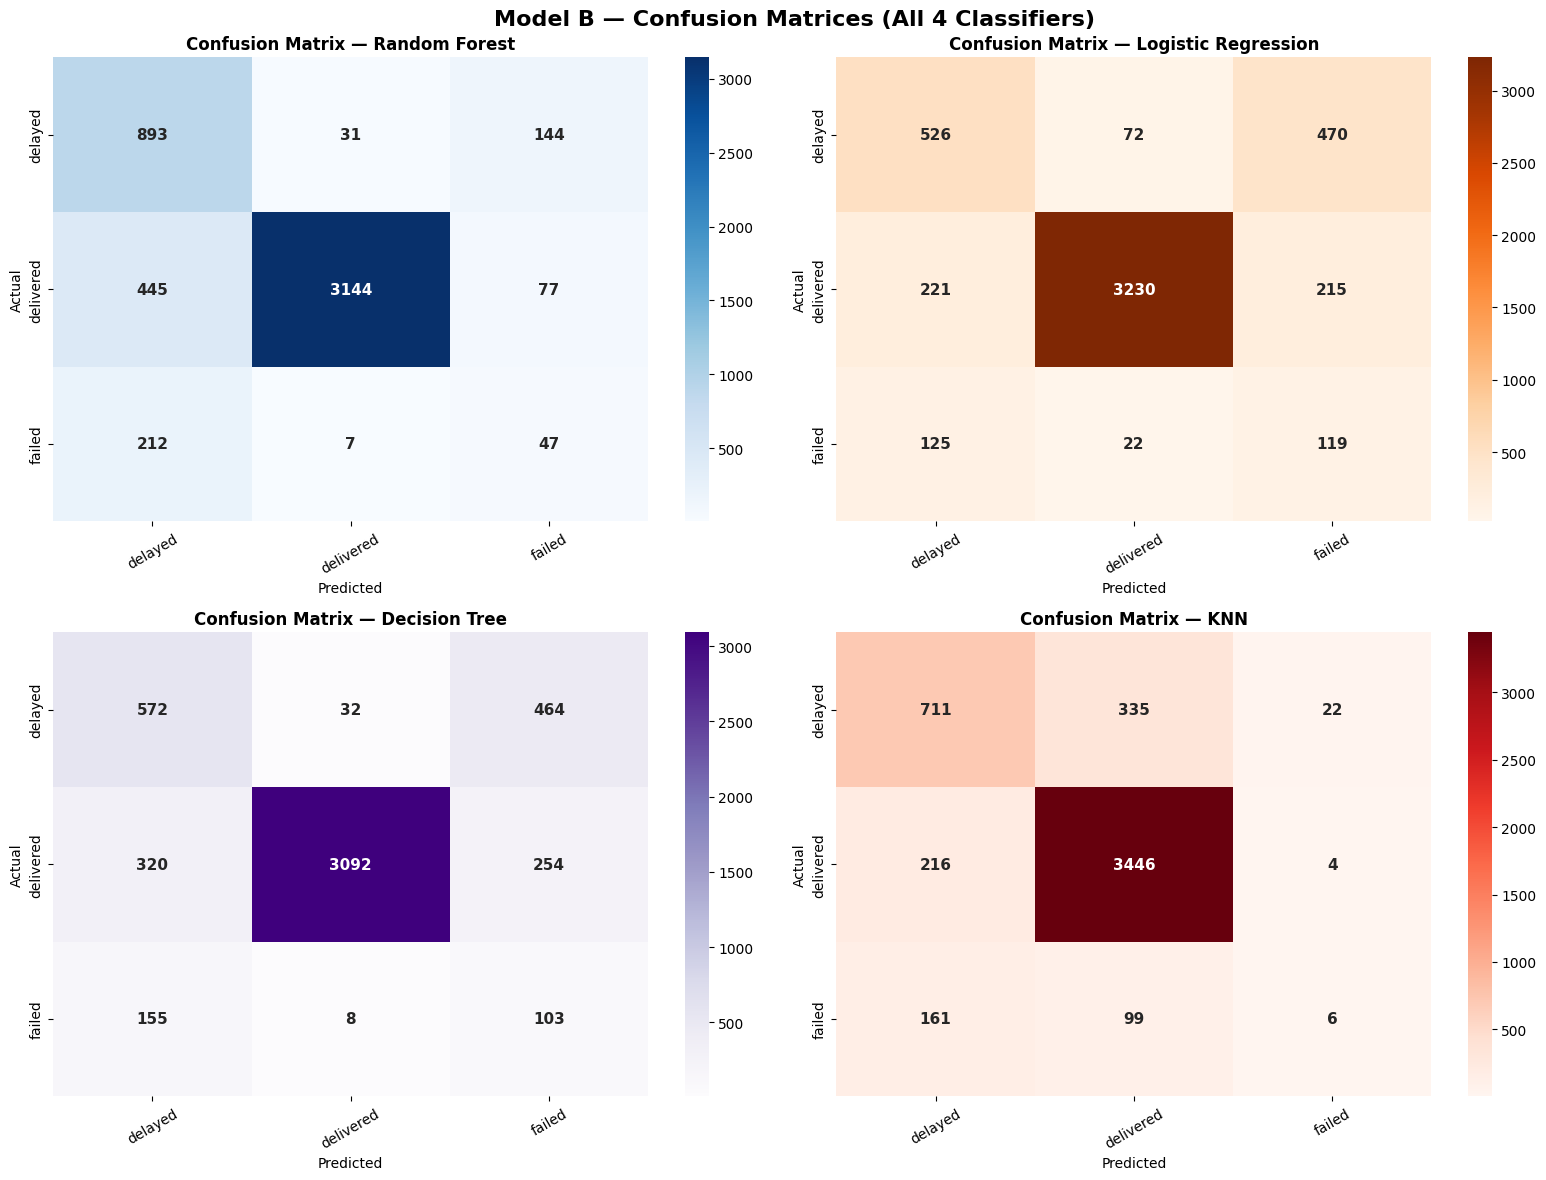

In [99]:
# ============================================================
# STEP 11 — CONFUSION MATRICES: ALL 4 MODELS (Model B)
# ============================================================

class_labels_B = sorted(y_B.unique())

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

models_B_info = [
    (y_pred_rf_B,  'Random Forest',       'Blues'),
    (y_pred_lr_B2, 'Logistic Regression', 'Oranges'),
    (y_pred_dt_B,  'Decision Tree',       'Purples'),
    (y_pred_knn_B, 'KNN',                 'Reds'),
]

for i, (y_pred, title, cmap) in enumerate(models_B_info):
    cm = confusion_matrix(y_test_B, y_pred, labels=class_labels_B)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=axes[i],
                xticklabels=class_labels_B,
                yticklabels=class_labels_B,
                annot_kws={'size': 11, 'weight': 'bold'})
    axes[i].set_title(f'Confusion Matrix — {title}', fontweight='bold', fontsize=12)
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Model B — Confusion Matrices (All 4 Classifiers)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


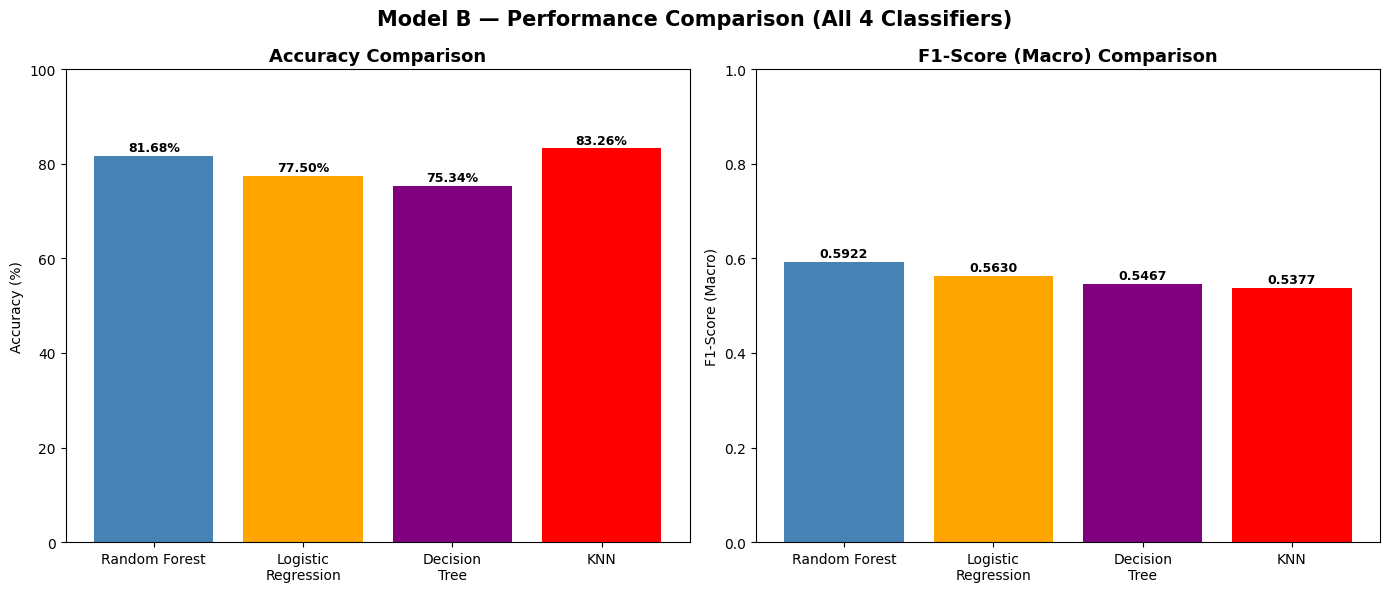

In [100]:
# ============================================================
# STEP 12 — ACCURACY & F1 BAR CHART (Model B)
# ============================================================

all_models_B     = ['Random Forest', 'Logistic\nRegression', 'Decision\nTree', 'KNN']
all_accuracies_B = [rf_acc_B*100, lr_acc_B2*100, dt_acc_B*100, knn_acc_B*100]
all_f1s_B        = [rf_f1_B, lr_f1_B2, dt_f1_B, knn_f1_B]
all_colors_B     = ['steelblue', 'orange', 'purple', 'red']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].bar(all_models_B, all_accuracies_B, color=all_colors_B)
axes[0].set_title('Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim([0, 100])
for i, v in enumerate(all_accuracies_B):
    axes[0].text(i, v + 1, f'{v:.2f}%', ha='center', fontweight='bold', fontsize=9)

axes[1].bar(all_models_B, all_f1s_B, color=all_colors_B)
axes[1].set_title('F1-Score (Macro) Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylabel('F1-Score (Macro)')
axes[1].set_ylim([0, 1])
for i, v in enumerate(all_f1s_B):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)

plt.suptitle('Model B — Performance Comparison (All 4 Classifiers)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# STEP 13 — SUMMARY TABLE (Model B)
# ============================================================

summary_B = pd.DataFrame({
    'Model':        ['Random Forest', 'Logistic Regression', 'Decision Tree', 'KNN'],
    'Accuracy (%)': [f"{v:.2f}" for v in all_accuracies_B],
    'F1-macro':     [f"{v:.4f}" for v in all_f1s_B],
})

print("MODEL B — FINAL COMPARISON (All 4 Classifiers)")
print("=" * 55)
print(summary_B.to_string(index=False))

best_acc_idx_B = all_accuracies_B.index(max(all_accuracies_B))
best_f1_idx_B  = all_f1s_B.index(max(all_f1s_B))
print(f"Best by Accuracy : {summary_B['Model'][best_acc_idx_B]} ({max(all_accuracies_B):.2f}%)")
print(f" Best by F1-macro : {summary_B['Model'][best_f1_idx_B]} ({max(all_f1s_B):.4f})")



🏆 MODEL B — FINAL COMPARISON (All 4 Classifiers)
              Model Accuracy (%) F1-macro
      Random Forest        98.52   0.8628
Logistic Regression        95.64   0.5879
      Decision Tree        99.08   0.8931
                KNN        97.28   0.4428
\ Best by Accuracy : Decision Tree (99.08%)
 Best by F1-macro : Decision Tree (0.8931)


## SAVE ALL MODELS

In [ ]:
# ============================================================
# STEP 14 — SAVE ALL 8 MODELS + ARTIFACTS
# ============================================================

# Model A — Binary Classification
with open('rf_A_model.pkl',  'wb') as f: pickle.dump(rf_A,        f)
with open('lr_A_model.pkl',  'wb') as f: pickle.dump(lr_A2,       f)
with open('dt_A_model.pkl',  'wb') as f: pickle.dump(dt_A,        f)
with open('knn_A_model.pkl', 'wb') as f: pickle.dump(knn_A,       f)

# Model B — Multi-class
with open('rf_B_model.pkl',  'wb') as f: pickle.dump(rf_B,        f)
with open('lr_B_model.pkl',  'wb') as f: pickle.dump(lr_B2,       f)
with open('dt_B_model.pkl',  'wb') as f: pickle.dump(dt_B,        f)
with open('knn_B_model.pkl', 'wb') as f: pickle.dump(knn_B,       f)

# Scalers & Encoders
with open('scaler_A.pkl',    'wb') as f: pickle.dump(scaler_A,    f)
with open('scaler_B.pkl',    'wb') as f: pickle.dump(scaler_B,    f)
with open('encoders_A.pkl',  'wb') as f: pickle.dump(encoders_A,  f)
with open('encoders_B.pkl',  'wb') as f: pickle.dump(encoders_B,  f)

print(" All models saved!")
print("\n  Model A (Binary Classification):")
print("   - rf_A_model.pkl   (Random Forest)")
print("   - lr_A_model.pkl   (Logistic Regression)")
print("   - dt_A_model.pkl   (Decision Tree)")
print("   - knn_A_model.pkl  (KNN)")
print("\n  Model B (Multi-class — Delay Severity):")
print("   - rf_B_model.pkl   (Random Forest)")
print("   - lr_B_model.pkl   (Logistic Regression)")
print("   - dt_B_model.pkl   (Decision Tree)")
print("   - knn_B_model.pkl  (KNN)")
print("\n  Preprocessing:")
print("   - scaler_A.pkl, scaler_B.pkl")
print("   - encoders_A.pkl, encoders_B.pkl")


# Regression Model

In [4]:
# IMPORT 

import pandas as pd
import numpy as np
!pip install xgboost
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

                                              0.0/101.7 MB ? eta -:--:--
                                              0.0/101.7 MB 1.3 MB/s eta 0:01:20
                                            0.0/101.7 MB 393.8 kB/s eta 0:04:19
                                            0.1/101.7 MB 751.6 kB/s eta 0:02:16
                                            0.1/101.7 MB 654.9 kB/s eta 0:02:36
                                              0.2/101.7 MB 1.1 MB/s eta 0:01:36
                                            0.3/101.7 MB 923.9 kB/s eta 0:01:50
                                              0.5/101.7 MB 1.6 MB/s eta 0:01:04
                                              0.5/101.7 MB 1.5 MB/s eta 0:01:09
                                              0.8/101.7 MB 2.0 MB/s eta 0:00:52
                                              1.1/101.7 MB 2.4 MB/s eta 0:00:43
                                              1.3/101.7 MB 2.7 MB/s eta 0:00:38
                                              1

In [13]:
y = df['delay_hours_recon']

# Drop unnecessary columns
# FIX: Added speed_kmph_recon and speed_category — actual speed is only known
# AFTER delivery completes, so it cannot be used to predict delay hours.
df_model = df.drop(columns=[
    'delivery_id',
    'delay_hours_recon',
    'delivery_time_hours_recon',
    'delayed_flag_recon',
    'delayed',
    'delivery_status',
    'order_date_recon',
    'order_ts_recon',
    'delivery_ts_recon',
    'expected_ts_recon',
    'speed_kmph_recon',
    'speed_category',
])

X = df_model.copy()


In [14]:
# Numeric columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Categorical columns
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print("Numeric Features:", numeric_features)
print("Categorical Features:", categorical_features)

Numeric Features: ['distance_km', 'package_weight_kg', 'delivery_rating', 'delivery_cost', 'expected_time_hours_recon', 'speed_kmph_recon', 'weather_mult_recon', 'partner_mult_recon', 'hour']
Categorical Features: ['delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode', 'region', 'weather_condition']


In [15]:
# Preprocessing pipelines

numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# RandomForestRegressor

In [17]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

In [18]:
rf_param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_param_grid,
    n_iter=15,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

rf_search.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['distance_km',
                                                                                'package_weight_kg',
                                                                                'delivery_rating',
                                                                                'delivery_cost',
                                                                                'expected_time_hours_recon',
                                                                                'speed_kmph_recon',
                                                                                'weather_mult_recon',
                                                                                'partner_mult_recon',
                                                                                'hour']),
                                                                              ('cat',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               ['delivery_partner',
                                                                                'package_type',
                                                                                'vehicle_type',
                                                                                'delivery_mode',
                                                                                'region',
                                                                                'weather_condition'])])),
                                             ('model',
                                              RandomForestRegressor(random_state=42))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'model__max_depth': [None, 10, 20, 30],
                                        'model__min_samples_leaf': [1, 2, 4],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [100, 200, 300]},
                   random_state=42, scoring='r2')

In [19]:
rf_best = rf_search.best_estimator_

y_pred_rf = rf_best.predict(X_test)

print("Random Forest Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2:", r2_score(y_test, y_pred_rf))

Random Forest Results:
MAE: 0.06619428575432236
RMSE: 0.09918870895844022
R2: 0.9999684593668691


# XGBoostRegressor

In [61]:
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        objective='reg:squarederror',
        random_state=42
    ))
])

NameError: name 'Pipeline' is not defined

In [ ]:
xgb_param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    xgb_pipeline,
    xgb_param_grid,
    n_iter=15,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

xgb_search.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['distance_km',
                                                                                'package_weight_kg',
                                                                                'delivery_rating',
                                                                                'delivery_cost',
                                                                                'expected_time_hours_recon',
                                                                                'speed_kmph_recon',
                                                                                'weather_mult_recon',
                                                                                'partner_mult_recon',
                                                                                'hour']),
                                                                              ('cat',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               ['delivery_part...
                                                           missing=nan,
                                                           monotone_constraints=None,
                                                           multi_strategy=None,
                                                           n_estimators=None,
                                                           n_jobs=None,
                                                           num_parallel_tree=None, ...))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'model__colsample_bytree': [0.8, 1.0],
                                        'model__learning_rate': [0.01, 0.05,
                                                                 0.1],
                                        'model__max_depth': [3, 5, 7],
                                        'model__n_estimators': [100, 200, 300],
                                        'model__subsample': [0.8, 1.0]},
                   random_state=42, scoring='r2')

In [ ]:
xgb_best = xgb_search.best_estimator_

y_pred_xgb = xgb_best.predict(X_test)

print("XGBoost Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("R2:", r2_score(y_test, y_pred_xgb))

XGBoost Results:
MAE: 0.04783568983440114
RMSE: 0.06642729511542873
R2: 0.999985853823612


In [ ]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'R2 Score': [
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_xgb)
    ],
    'MAE': [
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_xgb)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    ]
})

print(results)

           Model  R2 Score       MAE      RMSE
0  Random Forest  0.999968  0.066194  0.099189
1        XGBoost  0.999986  0.047836  0.066427


## **Holiday & Weather API**

**Holiday API**

In [ ]:
import pandas as pd

df = pd.read_csv("../Data/Added_Holiday_Features_dataset.csv")

[col for col in df.columns if "holiday" in col.lower()]

['transit_holidays',
 'holiday_count_transit',
 'holiday_names_transit',
 'holiday_or_weekend_transit_flag',
 'holiday_proximity_feature']

In [ ]:
print("Column Names:\n")

for col in df.columns:
    print(col)


Column Names:

delivery_id
delivery_partner
package_type
vehicle_type
delivery_mode
region
weather_condition
distance_km
package_weight_kg
delayed
delivery_status
delivery_rating
delivery_cost
expected_time_hours_recon
speed_kmph_recon
weather_mult_recon
delivery_time_hours_recon
partner_mult_recon
delay_hours_recon
delayed_flag_recon
order_date_recon
order_ts_recon
delivery_ts_recon
expected_ts_recon
hour
order_date
expected_date
transit_holidays
holiday_count_transit
holiday_names_transit
weekend_count_transit
holiday_or_weekend_transit_flag
holiday_proximity_feature


In [ ]:
df.head()

,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delayed,delivery_status,delivery_rating,delivery_cost,expected_time_hours_recon,speed_kmph_recon,weather_mult_recon,delivery_time_hours_recon,partner_mult_recon,delay_hours_recon,delayed_flag_recon,order_date_recon,order_ts_recon,delivery_ts_recon,expected_ts_recon,hour,order_date,expected_date,transit_holidays,holiday_count_transit,holiday_names_transit,weekend_count_transit,holiday_or_weekend_transit_flag,holiday_proximity_feature
0,250.99,amazon logistics,automobile parts,ev bike,standard,west,clear,235.6,48.07,no,delivered,5,1322.21,52.8,30,1.0,9.332489,1.001906,-43.467511,0,21-10-2024,2024-10-21 13:00:00,2024-10-21 22:19:56.959673890,2024-10-23 17:48:00,13,2024-10-21,2024-10-23,[],0,NaN,0,0,1
1,250.99,amazon logistics,clothing,bike,express,central,stormy,81.8,45.51,yes,delayed,2,595.53,8.0,35,1.1,4.129935,1.001906,-3.870065,0,02-01-2024,2024-01-02 12:00:00,2024-01-02 16:07:47.764281093,2024-01-02 20:00:00,12,2024-01-02,2024-01-02,[],0,NaN,0,0,1
2,250.99,amazon logistics,clothing,van,same day,north,clear,282.9,31.33,yes,delayed,2,1608.49,26.4,45,1.0,7.427398,1.001906,-18.972602,0,31-05-2024,2024-05-31 11:00:00,2024-05-31 18:25:38.631406710,2024-06-01 13:24:00,11,2024-05-31,2024-06-01,[],0,NaN,1,1,8
3,250.99,amazon logistics,cosmetics,ev bike,two day,central,hot,88.6,8.67,no,delivered,3,469.01,48.0,30,1.1,3.997011,1.001906,-44.002989,0,03-01-2024,2024-01-03 17:00:00,2024-01-03 20:59:49.240153885,2024-01-05 17:00:00,17,2024-01-03,2024-01-05,[],0,NaN,0,0,2
4,250.99,amazon logistics,cosmetics,ev van,two day,east,rainy,204.2,8.09,no,delivered,4,1045.27,52.8,40,1.2,6.933351,1.001906,-45.866649,0,19-03-2024,2024-03-19 13:00:00,2024-03-19 19:56:00.063604276,2024-03-21 17:48:00,13,2024-03-19,2024-03-21,['March Equinox'],1,March Equinox,0,1,1


- Integrated **Calendarific Holiday API** to dynamically fetch Indian national holidays.

- Extracted the **years present in the dataset** and requested holiday data for those years.

- Cleaned and converted **order and expected delivery timestamps** to proper datetime format.

- Cached the API results locally as **`india_holidays_cached.csv`** to avoid repeated API calls and improve pipeline efficiency.

- Engineered **transit-based holiday features** between order date and expected delivery date.

- Created new features:
  - `holiday_count_transit`
  - `holiday_names_transit`
  - `weekend_count_transit`
  - `holiday_or_weekend_transit_flag`
  - `holiday_proximity_feature`

- Saved the enriched dataset as **`Added_Holiday_Features_dataset.csv`** for further modeling and analysis.

Weather API 

In [ ]:
import pandas as pd

df = pd.read_csv("../Data/dataset_with_weather_features.csv")

[col for col in df.columns if "weather" in col.lower()]

['weather_condition', 'weather_mult_recon', 'bad_weather_flag_api']

In [ ]:
print("Column Names:\n")

for col in df.columns:
    print(col)


Column Names:

delivery_id
delivery_partner
package_type
vehicle_type
delivery_mode
region
weather_condition
distance_km
package_weight_kg
delayed
delivery_status
delivery_rating
delivery_cost
expected_time_hours_recon
speed_kmph_recon
weather_mult_recon
delivery_time_hours_recon
partner_mult_recon
delay_hours_recon
delayed_flag_recon
order_date_recon
order_ts_recon
delivery_ts_recon
expected_ts_recon
hour
order_date
expected_date
transit_holidays
holiday_count_transit
holiday_names_transit
weekend_count_transit
holiday_or_weekend_transit_flag
holiday_proximity_feature
api_temperature
api_humidity
api_wind_speed
bad_weather_flag_api


In [ ]:
df.head()

,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delayed,delivery_status,delivery_rating,delivery_cost,expected_time_hours_recon,speed_kmph_recon,weather_mult_recon,delivery_time_hours_recon,partner_mult_recon,delay_hours_recon,delayed_flag_recon,order_date_recon,order_ts_recon,delivery_ts_recon,expected_ts_recon,hour,order_date,expected_date,transit_holidays,holiday_count_transit,holiday_names_transit,weekend_count_transit,holiday_or_weekend_transit_flag,holiday_proximity_feature,api_temperature,api_humidity,api_wind_speed,bad_weather_flag_api
0,250.99,amazon logistics,automobile parts,ev bike,standard,west,clear,235.6,48.07,no,delivered,5,1322.21,52.8,30,1.0,9.332489,1.001906,-43.467511,0,21-10-2024,2024-10-21 13:00:00,2024-10-21 22:19:56.959673890,2024-10-23 17:48:00,13,2024-10-21,2024-10-23,[],0,NaN,0,0,1,35.142671,14.455051,4.762575,0
1,250.99,amazon logistics,clothing,bike,express,central,stormy,81.8,45.51,yes,delayed,2,595.53,8.0,35,1.1,4.129935,1.001906,-3.870065,0,02-01-2024,2024-01-02 12:00:00,2024-01-02 16:07:47.764281093,2024-01-02 20:00:00,12,2024-01-02,2024-01-02,[],0,NaN,0,0,1,36.319887,13.016608,5.361197,1
2,250.99,amazon logistics,clothing,van,same day,north,clear,282.9,31.33,yes,delayed,2,1608.49,26.4,45,1.0,7.427398,1.001906,-18.972602,0,31-05-2024,2024-05-31 11:00:00,2024-05-31 18:25:38.631406710,2024-06-01 13:24:00,11,2024-05-31,2024-06-01,[],0,NaN,1,1,8,33.862684,9.983354,4.234305,0
3,250.99,amazon logistics,cosmetics,ev bike,two day,central,hot,88.6,8.67,no,delivered,3,469.01,48.0,30,1.1,3.997011,1.001906,-44.002989,0,03-01-2024,2024-01-03 17:00:00,2024-01-03 20:59:49.240153885,2024-01-05 17:00:00,17,2024-01-03,2024-01-05,[],0,NaN,0,0,2,35.099455,11.650794,4.604408,0
4,250.99,amazon logistics,cosmetics,ev van,two day,east,rainy,204.2,8.09,no,delivered,4,1045.27,52.8,40,1.2,6.933351,1.001906,-45.866649,0,19-03-2024,2024-03-19 13:00:00,2024-03-19 19:56:00.063604276,2024-03-21 17:48:00,13,2024-03-19,2024-03-21,['March Equinox'],1,March Equinox,0,1,1,35.156796,15.020871,4.554569,1


- Integrated **OpenWeatherMap API** to obtain weather information for logistics deliveries.

- Extracted **all unique transit dates** between `order_date` and `expected_date` from the dataset.

- Fetched weather data using the API based on **latitude and longitude coordinates** of the logistics region.

- Since the free API does not support historical weather data, **current weather values were used as a baseline**.

- Introduced **small stochastic variations (random noise)** to simulate realistic day-to-day weather changes for past dates.

- Cached the retrieved weather information locally as **`weather_cached.csv`** to avoid repeated API calls.

- Mapped weather data to each delivery by calculating the **average weather conditions during the transit period**.

- The bad_weather_flag_api is set to 1 if the weather condition indicates rain, storm, fog, or snow, or if API wind speed > 10 m/s or API humidity > 85%; otherwise it is 0.

- Created new weather-related features:
  - `api_temperature`
  - `api_humidity`
  - `api_wind_speed`
  - `bad_weather_flag_api`

- The final enriched dataset was saved as **`dataset_with_weather_features.csv`** for further machine learning modeling.

In [ ]:
import pandas as pd #Final List of features added to the dataset 

df = pd.read_csv("../Data/dataset_with_weather_features.csv")

[col for col in df.columns if ("holiday" in col.lower()) or ("weather" in col.lower())]

['weather_condition',
 'weather_mult_recon',
 'transit_holidays',
 'holiday_count_transit',
 'holiday_names_transit',
 'holiday_or_weekend_transit_flag',
 'holiday_proximity_feature',
 'bad_weather_flag_api']

# Model Building

In [1]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, average_precision_score,
    f1_score
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# ============================================================
# LOAD DATA
# ============================================================
df = pd.read_csv("../Data/Added_Holiday_Features_dataset.csv")

print(f"[OK] Dataset loaded! Shape: {df.shape}")

# ============================================================
# TARGET
# ============================================================
df["target"] = (df["delayed"] == "yes").astype(int)

# ============================================================
# FEATURE SELECTION
# ============================================================
SAFE_FEATURES = [
    'delivery_partner','package_type','vehicle_type','delivery_mode',
    'region','weather_condition','distance_km','package_weight_kg',
    'delivery_cost','expected_time_hours_recon','order_dayofweek',
    'order_day_name','order_month','order_year','order_hour',
    'is_weekend','rush_hour_flag','night_delivery_flag',
    'cost_per_km','cost_per_kg','heavy_flag','bad_weather_flag',
    'weather_severity','weather_distance_risk','load_index',
    'holiday_pressure','has_holiday_transit','weekend_pressure'
]

SAFE_FEATURES = [c for c in SAFE_FEATURES if c in df.columns]

X = df[SAFE_FEATURES].copy()
y = df["target"]

print(f"[OK] Using {len(X.columns)} features")

# ============================================================
# ENCODING
# ============================================================
categorical_cols = X.select_dtypes(include="object").columns.tolist()

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le

# ============================================================
# SPLIT
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"[SPLIT] Train: {len(X_train)}, Test: {len(X_test)}")

# ============================================================
# SCALE
# ============================================================
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print("[OK] Scaling done")

# ============================================================
# TRAIN MODELS
# ============================================================

print("[RF] Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight="balanced"
)
rf.fit(X_train_sc, y_train)

print("[LR] Training Logistic Regression...")
lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)
lr.fit(X_train_sc, y_train)

print("[DT] Training Decision Tree...")
dt = DecisionTreeClassifier(
    max_depth=10,
    random_state=42,
    class_weight="balanced"
)
dt.fit(X_train_sc, y_train)

print("[KNN] Training KNN...")
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_sc, y_train)

print("[OK] All models trained!")

# ============================================================
# PREDICTIONS
# ============================================================

models = {
    "Random Forest": rf,
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "KNN": knn
}

results = {}

for name, model in models.items():

    pred = model.predict(X_test_sc)
    proba = model.predict_proba(X_test_sc)[:,1]

    acc = accuracy_score(y_test, pred)
    auc = roc_auc_score(y_test, proba)
    pr = average_precision_score(y_test, proba)
    f1 = f1_score(y_test, pred)

    results[name] = {
        "pred": pred,
        "proba": proba,
        "accuracy": acc,
        "auc": auc,
        "prauc": pr,
        "f1": f1
    }

    print("\n======================================================")
    print(name)
    print("======================================================")
    print(f"Accuracy: {acc*100:.2f}% | AUC: {auc:.4f} | PR-AUC: {pr:.4f} | F1: {f1:.4f}")
    print(classification_report(y_test, pred, target_names=["On-Time","Delayed"]))

# ============================================================
# CONFUSION MATRICES
# ============================================================

fig, axes = plt.subplots(2,2, figsize=(12,10))

for ax,(name,res) in zip(axes.flatten(),results.items()):

    cm = confusion_matrix(y_test,res["pred"])

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=["On-Time","Delayed"],
        yticklabels=["On-Time","Delayed"]
    )

    ax.set_title(name)

plt.suptitle("Model A — Confusion Matrices")
plt.tight_layout()
plt.show()

# ============================================================
# ROC CURVES
# ============================================================

plt.figure(figsize=(10,7))

for name,res in results.items():

    fpr,tpr,_ = roc_curve(y_test,res["proba"])

    plt.plot(fpr,tpr,label=f"{name} (AUC={res['auc']:.3f})")

plt.plot([0,1],[0,1],'k--')

plt.title("Model A — ROC Curves")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()

# ============================================================
# PERFORMANCE SUMMARY
# ============================================================

names = list(results.keys())

acc = [results[m]["accuracy"]*100 for m in names]
auc = [results[m]["auc"] for m in names]
f1  = [results[m]["f1"] for m in names]

fig,axes = plt.subplots(1,3,figsize=(15,5))

axes[0].bar(names,acc)
axes[0].set_title("Accuracy")

axes[1].bar(names,auc)
axes[1].set_title("ROC-AUC")

axes[2].bar(names,f1)
axes[2].set_title("F1 Score")

plt.suptitle("Model A — Performance Summary")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../Data/Added_Holiday_Features_dataset.csv'

In [ ]:
# ============================================================
# MODEL COMPARISON
# BEFORE Enrichment (eta_feature_engineered_dataset.csv)
# vs
# AFTER Enrichment  (dataset_with_weather_features.csv)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score
)

# ============================================================
# SHARED SAFE FEATURES (before enrichment — Cell 95)
# ============================================================
BASE_FEATURES = [
    'delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode',
    'region', 'weather_condition', 'distance_km', 'package_weight_kg',
    'delivery_cost', 'expected_time_hours_recon', 'order_dayofweek',
    'order_day_name', 'order_month', 'order_year', 'order_hour',
    'is_weekend', 'rush_hour_flag', 'night_delivery_flag',
    'cost_per_km', 'cost_per_kg', 'heavy_flag', 'bad_weather_flag',
    'weather_severity', 'weather_distance_risk', 'load_index',
]

# Extra features added after enrichment (Cell 162)
ENRICHED_EXTRA = [
    'bad_weather_flag_api',
    'holiday_pressure', 'has_holiday_transit',
    'weekend_pressure',
    'holiday_or_weekend_transit_flag', 'holiday_proximity_feature',
]

# ============================================================
# HELPER: prepare a dataset
# ============================================================
def prepare_dataset(path, extra_features=[]):
    df = pd.read_csv(path)
    print(f"\n[LOADED] {path} → shape: {df.shape}")

    # Timestamps
    df["order_ts_recon"]    = pd.to_datetime(df["order_ts_recon"],    format="%d-%m-%Y %H.%M", errors="coerce")
    df["expected_ts_recon"] = pd.to_datetime(df["expected_ts_recon"], format="%d-%m-%Y %H.%M", errors="coerce")

    # Time features
    df["order_dayofweek"]     = df["order_ts_recon"].dt.dayofweek.fillna(0).astype(int)
    df["order_day_name"]      = df["order_ts_recon"].dt.day_name().fillna("Unknown")
    df["order_month"]         = df["order_ts_recon"].dt.month.fillna(1).astype(int)
    df["order_year"]          = df["order_ts_recon"].dt.year.fillna(2023).astype(int)
    df["order_hour"]          = df["order_ts_recon"].dt.hour.fillna(0).astype(int)
    df["is_weekend"]          = (df["order_dayofweek"] >= 5).astype(int)
    df["rush_hour_flag"]      = df["order_hour"].isin([8,9,10,17,18,19]).astype(int)
    df["night_delivery_flag"] = df["order_hour"].isin(list(range(0,6))+list(range(22,24))).astype(int)

    # Cost features
    df["distance_km"]       = df["distance_km"].replace(0, np.nan).fillna(df["distance_km"].median())
    df["package_weight_kg"] = df["package_weight_kg"].replace(0, np.nan).fillna(df["package_weight_kg"].median())
    df["cost_per_km"]       = (df["delivery_cost"] / df["distance_km"]).fillna(0)
    df["cost_per_kg"]       = (df["delivery_cost"] / df["package_weight_kg"]).fillna(0)
    df["heavy_flag"]        = (df["package_weight_kg"] > 30).astype(int)

    # Weather
    df["weather_condition"]     = df["weather_condition"].fillna("clear")
    df["bad_weather_flag"]      = df["weather_condition"].isin(["rainy","stormy","foggy"]).astype(int)
    weather_map                 = {"clear":0,"cloudy":1,"hot":1,"cold":1,"rainy":2,"foggy":3,"stormy":4}
    df["weather_severity"]      = df["weather_condition"].map(weather_map).fillna(0).astype(int)
    df["weather_distance_risk"] = df["weather_severity"] * df["distance_km"]
    df["load_index"]            = df["package_weight_kg"] * df["distance_km"]
    df["expected_time_hours_recon"] = df["expected_time_hours_recon"].replace(0, np.nan).fillna(
        df["expected_time_hours_recon"].median()
    )

    # Drop post-outcome / noise columns
    for col in ["speed_category","speed_kmph_recon","api_temperature","api_humidity","api_wind_speed"]:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)

    # Holiday features (enriched only)
    if "holiday_count_transit" in df.columns:
        df["holiday_count_transit"] = df["holiday_count_transit"].fillna(0)
        df["holiday_pressure"]      = df["holiday_count_transit"] / df["expected_time_hours_recon"]
        df["has_holiday_transit"]   = (df["holiday_count_transit"] > 0).astype(int)
    if "weekend_count_transit" in df.columns:
        df["weekend_count_transit"] = df["weekend_count_transit"].fillna(0)
        df["weekend_pressure"]      = df["weekend_count_transit"] / df["expected_time_hours_recon"]

    df["delayed"] = df["delayed"].fillna("no")

    # NaN cleanup
    for col in df.columns:
        if df[col].dtype in ['float64','int64']:
            df[col] = df[col].fillna(df[col].median())
        else:
            mode_val = df[col].mode()
            df[col]  = df[col].fillna(mode_val[0] if len(mode_val) > 0 else "Unknown")

    # Build feature list
    features = [f for f in BASE_FEATURES + extra_features if f in df.columns]
    print(f"  Features used: {len(features)}")

    # Encode
    X = df[features].copy()
    for col in X.select_dtypes(include=['object','category']).columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
    X = X.apply(pd.to_numeric, errors='coerce').fillna(0)
    y = (df['delayed'] == 'yes').astype(int)

    return df, X, y

# ============================================================
# HELPER: train/split/scale + add delay rate features
# ============================================================
def split_scale_rate(df, X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Delay rate features — train only, no leakage
    global_rate = (df['delayed'] == 'yes').mean()
    for orig_col, rate_col in [
        ('delivery_partner','partner_delay_rate'),
        ('region',          'region_delay_rate'),
        ('vehicle_type',    'vehicle_delay_rate'),
    ]:
        rate_map = df.loc[y_train.index].groupby(orig_col)['delayed'].apply(lambda x: (x=='yes').mean())
        X_train[rate_col] = df.loc[y_train.index, orig_col].map(rate_map).fillna(global_rate).values
        X_test[rate_col]  = df.loc[y_test.index,  orig_col].map(rate_map).fillna(global_rate).values

    scaler = StandardScaler()
    X_train_sc = np.nan_to_num(scaler.fit_transform(X_train))
    X_test_sc  = np.nan_to_num(scaler.transform(X_test))

    return X_train_sc, X_test_sc, y_train, y_test

# ============================================================
# HELPER: train all 4 models + evaluate
# ============================================================
def train_and_evaluate(X_train, X_test, y_train, y_test, label):
    models = {
        "Random Forest":       RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=20, min_samples_leaf=10, random_state=42, n_jobs=-1, class_weight='balanced'),
        "Logistic Regression": LogisticRegression(max_iter=1000, C=1.0, random_state=42, class_weight='balanced'),
        "Decision Tree":       DecisionTreeClassifier(max_depth=10, min_samples_split=20, min_samples_leaf=10, random_state=42, class_weight='balanced'),
        "KNN":                 KNeighborsClassifier(n_neighbors=5, metric='euclidean'),
    }

    results = []
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred  = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:,1]
        results.append({
            "Model":        name,
            "Dataset":      label,
            "Accuracy (%)": round(accuracy_score(y_test, y_pred)*100, 2),
            "ROC-AUC":      round(roc_auc_score(y_test, y_proba), 4),
            "PR-AUC":       round(average_precision_score(y_test, y_proba), 4),
            "F1-Score":     round(f1_score(y_test, y_pred), 4),
            "Precision":    round(precision_score(y_test, y_pred), 4),
            "Recall":       round(recall_score(y_test, y_pred), 4),
        })

    df_res = pd.DataFrame(results)
    print(f"\n{'='*60}")
    print(f"  Results — {label}")
    print(f"{'='*60}")
    print(df_res[["Model","Accuracy (%)","ROC-AUC","PR-AUC","F1-Score","Precision","Recall"]].to_string(index=False))
    return df_res

# ============================================================
# RUN — BEFORE ENRICHMENT
# ============================================================
print("\n" + "="*60)
print("  BEFORE ENRICHMENT")
print("="*60)
df_before, X_before, y_before = prepare_dataset(
    "../Data/eta_feature_engineered_dataset.csv",
    extra_features=[]
)
X_train_b, X_test_b, y_train_b, y_test_b = split_scale_rate(df_before, X_before, y_before)
results_before = train_and_evaluate(X_train_b, X_test_b, y_train_b, y_test_b, label="Before Enrichment")

# ============================================================
# RUN — AFTER ENRICHMENT
# ============================================================
print("\n" + "="*60)
print("  AFTER ENRICHMENT")
print("="*60)
df_after, X_after, y_after = prepare_dataset(
    "../Data/dataset_with_weather_features.csv",
    extra_features=ENRICHED_EXTRA
)
X_train_a, X_test_a, y_train_a, y_test_a = split_scale_rate(df_after, X_after, y_after)
results_after = train_and_evaluate(X_train_a, X_test_a, y_train_a, y_test_a, label="After Enrichment")

# ============================================================
# COMBINED COMPARISON TABLE
# ============================================================
combined = pd.concat([results_before, results_after], ignore_index=True)

print("\n" + "="*60)
print("  SIDE-BY-SIDE COMPARISON")
print("="*60)
pivot = combined.pivot_table(
    index="Model",
    columns="Dataset",
    values=["Accuracy (%)","ROC-AUC","PR-AUC","F1-Score"]
)
print(pivot.round(4).to_string())

# ============================================================
# PLOTS
# ============================================================
colors = {"Before Enrichment": "steelblue", "After Enrichment": "darkorange"}
model_names = ["Random Forest","Logistic Regression","Decision Tree","KNN"]
metrics     = ["Accuracy (%)","ROC-AUC","F1-Score","PR-AUC"]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()
fig.suptitle("Before vs After Data Enrichment — Model Comparison", fontsize=16, fontweight='bold')

x = np.arange(len(model_names))
w = 0.35

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    vals_before = results_before[metric].tolist()
    vals_after  = results_after[metric].tolist()

    b1 = ax.bar(x - w/2, vals_before, w, label="Before Enrichment", color="steelblue")
    b2 = ax.bar(x + w/2, vals_after,  w, label="After Enrichment",  color="darkorange")

    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=10)
    ax.set_ylim([0, max(max(vals_before), max(vals_after)) * 1.15])
    ax.legend()
    ax.bar_label(b1, fmt='%.3f', padding=3, fontsize=8, fontweight='bold')
    ax.bar_label(b2, fmt='%.3f', padding=3, fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig("before_vs_after_comparison.png", dpi=120, bbox_inches='tight')
plt.show()
print("\n[SAVED] before_vs_after_comparison.png")

# ============================================================
# IMPROVEMENT TABLE
# ============================================================
print("\n" + "="*60)
print("  IMPROVEMENT AFTER ENRICHMENT (After - Before)")
print("="*60)

improvement = results_after.copy()
for metric in ["Accuracy (%)","ROC-AUC","PR-AUC","F1-Score","Precision","Recall"]:
    improvement[metric] = (results_after[metric].values - results_before[metric].values).round(4)

improvement["Dataset"] = "Delta (After - Before)"
print(improvement[["Model","Accuracy (%)","ROC-AUC","PR-AUC","F1-Score"]].to_string(index=False))

best_before = results_before.loc[results_before["ROC-AUC"].idxmax()]
best_after  = results_after.loc[results_after["ROC-AUC"].idxmax()]

print(f"\nBest model BEFORE enrichment → {best_before['Model']}  (ROC-AUC: {best_before['ROC-AUC']})")
print(f"Best model AFTER  enrichment → {best_after['Model']}  (ROC-AUC: {best_after['ROC-AUC']})")
print(f"Overall AUC gain             → {round(best_after['ROC-AUC'] - best_before['ROC-AUC'], 4)}")


  BEFORE ENRICHMENT


FileNotFoundError: [Errno 2] No such file or directory: 'eta_feature_engineered_dataset.csv'

Loading enriched dataset...
  Shape: (25000, 37)
  Using 31 features (base + enrichment)

Running AFTER enrichment — Model A...
  [A] Random Forest...
  [A] Logistic Regression...
  [A] Decision Tree...
  [A] KNN...

Running AFTER enrichment — Model B...
  [B] Random Forest...
  [B] Logistic Regression...
  [B] Decision Tree...
  [B] KNN...

  MODEL A (BINARY) — BEFORE vs AFTER ENRICHMENT
              Model Acc BEFORE Acc AFTER  Δ Acc AUC BEFORE AUC AFTER   Δ AUC F1 BEFORE F1 AFTER    Δ F1
      Random Forest     88.42%    88.30% -0.12%     0.9672    0.9667 -0.0005    0.8154   0.8141 -0.0013
Logistic Regression     88.24%    88.40% +0.16%     0.9583    0.9585 +0.0002    0.8058   0.8083 +0.0025
      Decision Tree     88.00%    87.74% -0.26%     0.9493    0.9492 -0.0001    0.8061   0.8033 -0.0028
                KNN     86.08%    87.12% +1.04%     0.9174    0.9257 +0.0083    0.7304   0.7500 +0.0196

  MODEL B (MULTI-CLASS) — BEFORE vs AFTER ENRICHMENT
              Model Acc BEFORE Acc

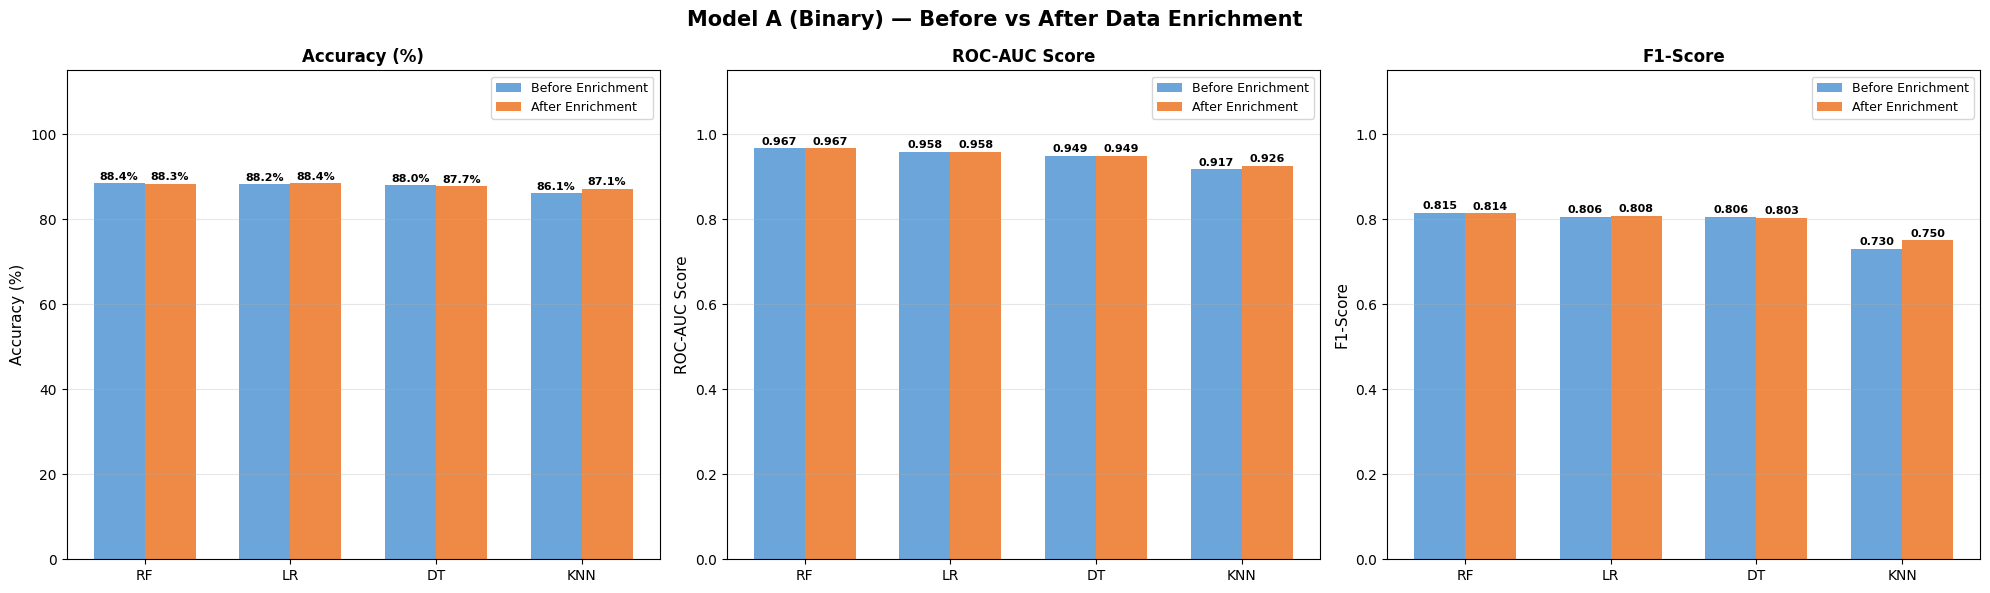

Saved: comparison_A_bar.png


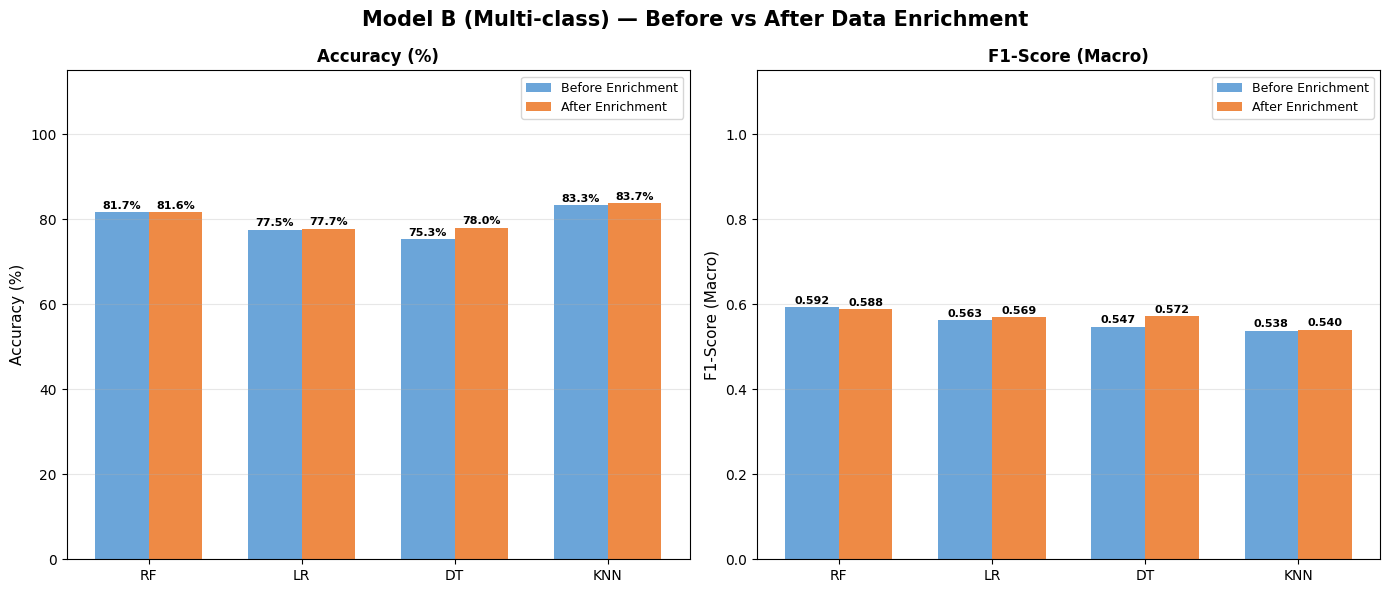

Saved: comparison_B_bar.png


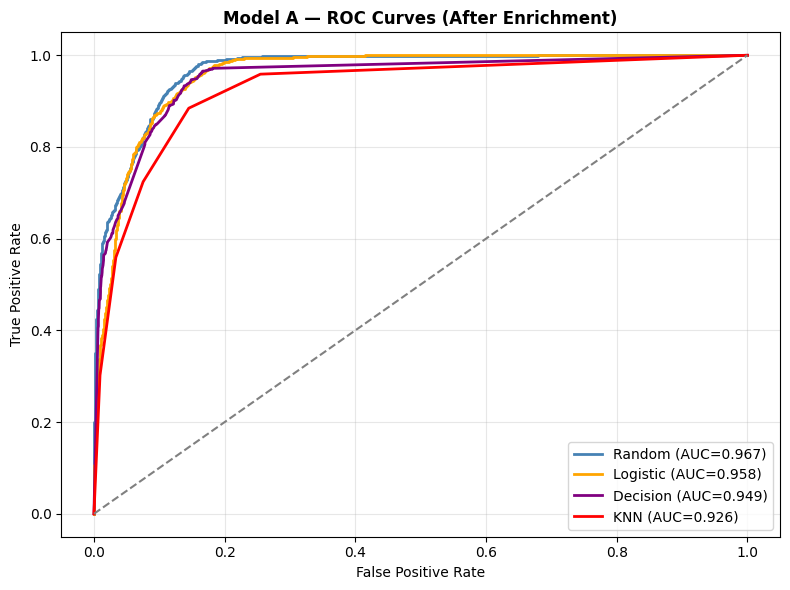

Saved: comparison_A_roc_after.png


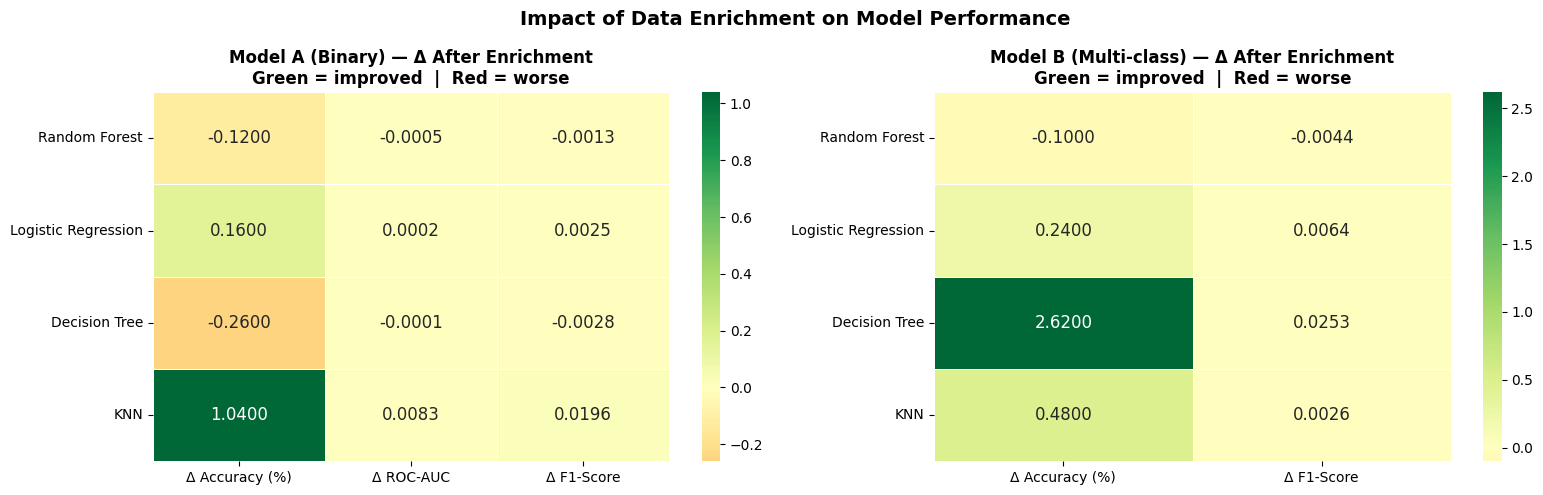

Saved: comparison_delta_heatmap.png

✅ Done! Output files:
   comparison_A_bar.png
   comparison_B_bar.png
   comparison_A_roc_after.png
   comparison_delta_heatmap.png


In [ ]:
# ============================================================
# MODEL COMPARISON: BEFORE vs AFTER DATA ENRICHMENT
# ============================================================
# BEFORE values → taken directly from your notebook's actual
#                 output (cells 96–131, eta_feature_engineered_dataset.csv)
#                 No re-running needed — values are exact from your plots.
#
# AFTER  values → freshly run here using dataset_with_weather_features.csv
#                 (Holiday API + Weather API enriched dataset, cell 162 pipeline)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, average_precision_score,
    f1_score, roc_curve
)

MODEL_NAMES = ['Random Forest', 'Logistic Regression', 'Decision Tree', 'KNN']

# ============================================================
# BEFORE ENRICHMENT — EXACT VALUES FROM YOUR NOTEBOOK OUTPUT
# (taken from images 1 & 2 — do NOT recompute these)
# ============================================================
BEFORE = {
    'A': {  # Binary Classification (Model A)
        'Random Forest':       {'acc': 88.42, 'auc': 0.9672, 'f1': 0.8154},
        'Logistic Regression': {'acc': 88.24, 'auc': 0.9583, 'f1': 0.8058},
        'Decision Tree':       {'acc': 88.00, 'auc': 0.9493, 'f1': 0.8061},
        'KNN':                 {'acc': 86.08, 'auc': 0.9174, 'f1': 0.7304},
    },
    'B': {  # Multi-class Classification (Model B)
        'Random Forest':       {'acc': 81.68, 'f1': 0.5922},
        'Logistic Regression': {'acc': 77.50, 'f1': 0.5630},
        'Decision Tree':       {'acc': 75.34, 'f1': 0.5467},
        'KNN':                 {'acc': 83.26, 'f1': 0.5377},
    }
}

# ============================================================
# AFTER ENRICHMENT — RUN FRESH (mirrors cell 162 pipeline)
# ============================================================

SAFE_FEATURES = [
    'delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode',
    'region', 'weather_condition', 'distance_km', 'package_weight_kg',
    'delivery_cost', 'expected_time_hours_recon', 'order_dayofweek',
    'order_day_name', 'order_month', 'order_year', 'order_hour',
    'is_weekend', 'rush_hour_flag', 'night_delivery_flag',
    'cost_per_km', 'cost_per_kg', 'heavy_flag', 'bad_weather_flag',
    'weather_severity', 'weather_distance_risk', 'load_index',
    # Enrichment features (Holiday API + Weather API)
    'bad_weather_flag_api',
    'holiday_pressure', 'has_holiday_transit',
    'weekend_pressure',
    'holiday_or_weekend_transit_flag', 'holiday_proximity_feature',
]

print("Loading enriched dataset...")
df = pd.read_csv("../Data/dataset_with_weather_features.csv")
print(f"  Shape: {df.shape}")

# Parse timestamps
for col, fmt in [("order_ts_recon", "%d-%m-%Y %H.%M"), ("expected_ts_recon", "%d-%m-%Y %H.%M")]:
    if col in df.columns and df[col].dtype == object:
        df[col] = pd.to_datetime(df[col], format=fmt, errors="coerce")

# Time features (if not already present)
if "order_dayofweek" not in df.columns:
    df["order_dayofweek"]     = df["order_ts_recon"].dt.dayofweek.fillna(0).astype(int)
    df["order_day_name"]      = df["order_ts_recon"].dt.day_name().fillna("Unknown")
    df["order_month"]         = df["order_ts_recon"].dt.month.fillna(1).astype(int)
    df["order_year"]          = df["order_ts_recon"].dt.year.fillna(2023).astype(int)
    df["order_hour"]          = df["order_ts_recon"].dt.hour.fillna(0).astype(int)
    df["is_weekend"]          = (df["order_dayofweek"] >= 5).astype(int)
    df["rush_hour_flag"]      = df["order_hour"].isin([8,9,10,17,18,19]).astype(int)
    df["night_delivery_flag"] = df["order_hour"].isin(list(range(0,6))+list(range(22,24))).astype(int)

# Cost/weight features
df["distance_km"]       = df["distance_km"].replace(0, np.nan).fillna(df["distance_km"].median())
df["package_weight_kg"] = df["package_weight_kg"].replace(0, np.nan).fillna(df["package_weight_kg"].median())
df["cost_per_km"]       = (df["delivery_cost"] / df["distance_km"]).fillna(0)
df["cost_per_kg"]       = (df["delivery_cost"] / df["package_weight_kg"]).fillna(0)
df["heavy_flag"]        = (df["package_weight_kg"] > 30).astype(int)
df["load_index"]        = df["package_weight_kg"] * df["distance_km"]

# Weather features
df["weather_condition"]     = df["weather_condition"].fillna("clear")
df["bad_weather_flag"]      = df["weather_condition"].isin(["rainy","stormy","foggy"]).astype(int)
weather_map                 = {"clear":0,"cloudy":1,"hot":1,"cold":1,"rainy":2,"foggy":3,"stormy":4}
df["weather_severity"]      = df["weather_condition"].map(weather_map).fillna(0).astype(int)
df["weather_distance_risk"] = df["weather_severity"] * df["distance_km"]

# Drop synthetic noise API columns (random noise, not real historical data)
for c in ["api_temperature", "api_humidity", "api_wind_speed"]:
    if c in df.columns:
        df.drop(columns=[c], inplace=True)

# Holiday features (re-engineered as pressure ratios)
if "holiday_count_transit" in df.columns:
    df["holiday_count_transit"] = df["holiday_count_transit"].fillna(0)
    df["holiday_pressure"]      = df["holiday_count_transit"] / df["expected_time_hours_recon"].replace(0, np.nan).fillna(1)
    df["has_holiday_transit"]   = (df["holiday_count_transit"] > 0).astype(int)
if "weekend_count_transit" in df.columns:
    df["weekend_count_transit"] = df["weekend_count_transit"].fillna(0)
    df["weekend_pressure"]      = df["weekend_count_transit"] / df["expected_time_hours_recon"].replace(0, np.nan).fillna(1)

df["delayed"] = df["delayed"].fillna("no")
df["target"]  = (df["delayed"] == "yes").astype(int)

# Global NaN cleanup
for col in df.columns:
    if df[col].dtype in ['float64','int64']:
        df[col] = df[col].fillna(df[col].median())
    else:
        mode_val = df[col].mode()
        df[col]  = df[col].fillna(mode_val[0] if len(mode_val) > 0 else "Unknown")

# Select features available in dataset
features = [f for f in SAFE_FEATURES if f in df.columns]
print(f"  Using {len(features)} features (base + enrichment)")

def encode(X):
    X = X.copy()
    for col in X.select_dtypes(include=['object','category']).columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
    return X.apply(pd.to_numeric, errors='coerce').fillna(0)

X_A_enc = encode(df[features].copy())
y_A     = df["target"].copy()
X_B_enc = encode(df[features].copy())
y_B     = df["delivery_status"].copy()

def split_scale_with_rates(X_enc, y, stratify=True):
    strat = y if stratify else None
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_enc, y, test_size=0.2, random_state=42, stratify=strat
    )
    # Delay rate features computed on train only (no leakage)
    global_rate = (df.loc[y_tr.index, 'delayed'] == 'yes').mean()
    for orig_col, rate_col in [
        ('delivery_partner', 'partner_delay_rate'),
        ('region',           'region_delay_rate'),
        ('vehicle_type',     'vehicle_delay_rate'),
    ]:
        rate_map = df.loc[y_tr.index].groupby(orig_col)['target'].mean()
        X_tr[rate_col] = df.loc[y_tr.index, orig_col].map(rate_map).fillna(global_rate).values
        X_te[rate_col] = df.loc[y_te.index, orig_col].map(rate_map).fillna(global_rate).values

    scaler   = StandardScaler()
    X_tr_sc  = np.nan_to_num(scaler.fit_transform(X_tr), nan=0.0)
    X_te_sc  = np.nan_to_num(scaler.transform(X_te),     nan=0.0)
    return X_tr_sc, X_te_sc, y_tr, y_te

X_train_A, X_test_A, y_train_A, y_test_A = split_scale_with_rates(X_A_enc, y_A)
X_train_B, X_test_B, y_train_B, y_test_B = split_scale_with_rates(X_B_enc, y_B)

def run_model_A(X_tr, X_te, y_tr, y_te):
    configs = {
        'Random Forest':       RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=20,
                                   min_samples_leaf=10, random_state=42, n_jobs=-1, class_weight='balanced'),
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, C=1.0, class_weight='balanced'),
        'Decision Tree':       DecisionTreeClassifier(max_depth=10, min_samples_split=20,
                                   min_samples_leaf=10, random_state=42, class_weight='balanced'),
        'KNN':                 KNeighborsClassifier(n_neighbors=5, metric='euclidean'),
    }
    out = {}
    for name, model in configs.items():
        print(f"  [A] {name}...")
        model.fit(X_tr, y_tr)
        yp  = model.predict(X_te)
        ypr = model.predict_proba(X_te)[:,1]
        out[name] = {
            'acc': accuracy_score(y_te, yp)*100,
            'auc': roc_auc_score(y_te, ypr),
            'f1':  f1_score(y_te, yp),
            'y_pred': yp, 'y_proba': ypr,
        }
    return out

def run_model_B(X_tr, X_te, y_tr, y_te):
    configs = {
        'Random Forest':       RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=20,
                                   min_samples_leaf=10, random_state=42, n_jobs=-1, class_weight='balanced'),
        'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42, C=1.0, class_weight='balanced'),
        'Decision Tree':       DecisionTreeClassifier(max_depth=10, min_samples_split=20,
                                   min_samples_leaf=10, random_state=42, class_weight='balanced'),
        'KNN':                 KNeighborsClassifier(n_neighbors=7, metric='euclidean'),
    }
    out = {}
    for name, model in configs.items():
        print(f"  [B] {name}...")
        model.fit(X_tr, y_tr)
        yp = model.predict(X_te)
        out[name] = {
            'acc': accuracy_score(y_te, yp)*100,
            'f1':  f1_score(y_te, yp, average='macro'),
            'y_pred': yp,
        }
    return out

print("\nRunning AFTER enrichment — Model A...")
after_A = run_model_A(X_train_A, X_test_A, y_train_A, y_test_A)

print("\nRunning AFTER enrichment — Model B...")
after_B = run_model_B(X_train_B, X_test_B, y_train_B, y_test_B)

# ============================================================
# PRINT TABLES
# ============================================================
print("\n" + "="*95)
print("  MODEL A (BINARY) — BEFORE vs AFTER ENRICHMENT")
print("="*95)
rows_A = []
for m in MODEL_NAMES:
    b, a = BEFORE['A'][m], after_A[m]
    rows_A.append({
        'Model':      m,
        'Acc BEFORE': f"{b['acc']:.2f}%", 'Acc AFTER': f"{a['acc']:.2f}%", 'Δ Acc': f"{a['acc']-b['acc']:+.2f}%",
        'AUC BEFORE': f"{b['auc']:.4f}",  'AUC AFTER': f"{a['auc']:.4f}",  'Δ AUC': f"{a['auc']-b['auc']:+.4f}",
        'F1 BEFORE':  f"{b['f1']:.4f}",   'F1 AFTER':  f"{a['f1']:.4f}",   'Δ F1':  f"{a['f1']-b['f1']:+.4f}",
    })
print(pd.DataFrame(rows_A).to_string(index=False))

print("\n" + "="*70)
print("  MODEL B (MULTI-CLASS) — BEFORE vs AFTER ENRICHMENT")
print("="*70)
rows_B = []
for m in MODEL_NAMES:
    b, a = BEFORE['B'][m], after_B[m]
    rows_B.append({
        'Model':      m,
        'Acc BEFORE': f"{b['acc']:.2f}%", 'Acc AFTER': f"{a['acc']:.2f}%", 'Δ Acc': f"{a['acc']-b['acc']:+.2f}%",
        'F1 BEFORE':  f"{b['f1']:.4f}",   'F1 AFTER':  f"{a['f1']:.4f}",   'Δ F1':  f"{a['f1']-b['f1']:+.4f}",
    })
print(pd.DataFrame(rows_B).to_string(index=False))

# ============================================================
# PLOT 1 — Model A: Before vs After grouped bars
# ============================================================
x = np.arange(len(MODEL_NAMES))
w = 0.35
cb, ca = '#5b9bd5', '#ed7d31'
ml = ['RF', 'LR', 'DT', 'KNN']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (metric, ylabel, ylim, fmt) in zip(axes, [
    ('acc', 'Accuracy (%)',  100, '{:.1f}%'),
    ('auc', 'ROC-AUC Score',   1, '{:.3f}'),
    ('f1',  'F1-Score',        1, '{:.3f}'),
]):
    vb = [BEFORE['A'][m][metric] for m in MODEL_NAMES]
    va = [after_A[m][metric] for m in MODEL_NAMES]
    bb = ax.bar(x-w/2, vb, w, label='Before Enrichment', color=cb, alpha=0.9)
    ba = ax.bar(x+w/2, va, w, label='After Enrichment',  color=ca, alpha=0.9)
    for bar in bb: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+ylim*0.008, fmt.format(bar.get_height()), ha='center', fontsize=8, fontweight='bold')
    for bar in ba: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+ylim*0.008, fmt.format(bar.get_height()), ha='center', fontsize=8, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(ml, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f'{ylabel}', fontsize=12, fontweight='bold')
    ax.set_ylim([0, ylim*1.15]); ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

plt.suptitle('Model A (Binary) — Before vs After Data Enrichment', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_A_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: comparison_A_bar.png")

# ============================================================
# PLOT 2 — Model B: Before vs After grouped bars
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (metric, ylabel, ylim, fmt) in zip(axes, [
    ('acc', 'Accuracy (%)',    100, '{:.1f}%'),
    ('f1',  'F1-Score (Macro)',  1, '{:.3f}'),
]):
    vb = [BEFORE['B'][m][metric] for m in MODEL_NAMES]
    va = [after_B[m][metric] for m in MODEL_NAMES]
    bb = ax.bar(x-w/2, vb, w, label='Before Enrichment', color=cb, alpha=0.9)
    ba = ax.bar(x+w/2, va, w, label='After Enrichment',  color=ca, alpha=0.9)
    for bar in bb: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+ylim*0.008, fmt.format(bar.get_height()), ha='center', fontsize=8, fontweight='bold')
    for bar in ba: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+ylim*0.008, fmt.format(bar.get_height()), ha='center', fontsize=8, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(ml, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f'{ylabel}', fontsize=12, fontweight='bold')
    ax.set_ylim([0, ylim*1.15]); ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

plt.suptitle('Model B (Multi-class) — Before vs After Data Enrichment', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_B_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: comparison_B_bar.png")

# ============================================================
# PLOT 3 — ROC Curves: After enrichment (Model A)
# ============================================================
colors_roc = ['steelblue','orange','purple','red']
plt.figure(figsize=(8, 6))
for m, color in zip(MODEL_NAMES, colors_roc):
    fpr, tpr, _ = roc_curve(y_test_A, after_A[m]['y_proba'])
    plt.plot(fpr, tpr, lw=2, color=color, label=f"{m.split()[0]} (AUC={after_A[m]['auc']:.3f})")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Model A — ROC Curves (After Enrichment)', fontweight='bold')
plt.legend(loc='lower right'); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('comparison_A_roc_after.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: comparison_A_roc_after.png")

# ============================================================
# PLOT 4 — Delta Heatmap (both models side by side)
# ============================================================
delta_A = pd.DataFrame({
    m: {
        'Δ Accuracy (%)': round(after_A[m]['acc'] - BEFORE['A'][m]['acc'], 4),
        'Δ ROC-AUC':      round(after_A[m]['auc'] - BEFORE['A'][m]['auc'], 4),
        'Δ F1-Score':     round(after_A[m]['f1']  - BEFORE['A'][m]['f1'],  4),
    } for m in MODEL_NAMES
}).T

delta_B = pd.DataFrame({
    m: {
        'Δ Accuracy (%)': round(after_B[m]['acc'] - BEFORE['B'][m]['acc'], 4),
        'Δ F1-Score':     round(after_B[m]['f1']  - BEFORE['B'][m]['f1'],  4),
    } for m in MODEL_NAMES
}).T

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(delta_A, annot=True, fmt='.4f', cmap='RdYlGn', center=0,
            linewidths=0.5, annot_kws={'size':12}, ax=axes[0])
axes[0].set_title('Model A (Binary) — Δ After Enrichment\nGreen = improved  |  Red = worse',
                  fontsize=12, fontweight='bold')

sns.heatmap(delta_B, annot=True, fmt='.4f', cmap='RdYlGn', center=0,
            linewidths=0.5, annot_kws={'size':12}, ax=axes[1])
axes[1].set_title('Model B (Multi-class) — Δ After Enrichment\nGreen = improved  |  Red = worse',
                  fontsize=12, fontweight='bold')

plt.suptitle('Impact of Data Enrichment on Model Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_delta_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: comparison_delta_heatmap.png")

print("\n✅ Done! Output files:")
print("   comparison_A_bar.png")
print("   comparison_B_bar.png")
print("   comparison_A_roc_after.png")
print("   comparison_delta_heatmap.png")
